In [ ]:
# prompt: read amex.csv file and plot usefull chart

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('amex.csv')


In [ ]:
df

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62479,120631,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,800,31300,150000,...,168677,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,168698,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,168742,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN
62482,154260,Jun,Product 5,Channel 2,NY,No Bureau Hit,0.0,775,5000,160000,...,168754,0.0,48,0,0.002,0.0002,0.162,0.2787,0,NaN


In [ ]:
df.default_ind.value_counts()

,count
default_ind,
0,62121
1,363


In [ ]:
# prompt: convert all column values to encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = le.fit_transform(df[column])


In [ ]:
df

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,1,9,3,4,2,0.0,800,5000,45000,...,0,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN
1,110872,1,8,2,10,0,0.1,775,13000,100000,...,0,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN
2,158686,3,8,0,4,0,5.6,900,2000,100000,...,0,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,5,7,2,7,2,0.0,800,5000,170000,...,0,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN
4,158473,3,9,1,46,0,0.1,775,10000,40000,...,0,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62479,120631,1,8,2,10,0,0.1,800,31300,150000,...,168677,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN
62480,100850,2,8,3,20,2,0.0,750,27600,150000,...,168698,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN
62481,116077,1,2,3,9,0,6.5,700,1000,70000,...,168742,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN
62482,154260,3,7,1,34,2,0.0,775,5000,160000,...,168754,0.0,48,0,0.002,0.0002,0.162,0.2787,0,NaN


default_ind        1.000000
return_payments    0.171647
risk_score_2       0.084192
risk_score_3       0.078721
risk_score_7       0.066788
                     ...   
basic_no_trd      -0.030949
risk_score_6      -0.034330
risk_score_5      -0.052744
trust_identity    -0.071699
Unnamed: 61             NaN
Name: default_ind, Length: 62, dtype: float64


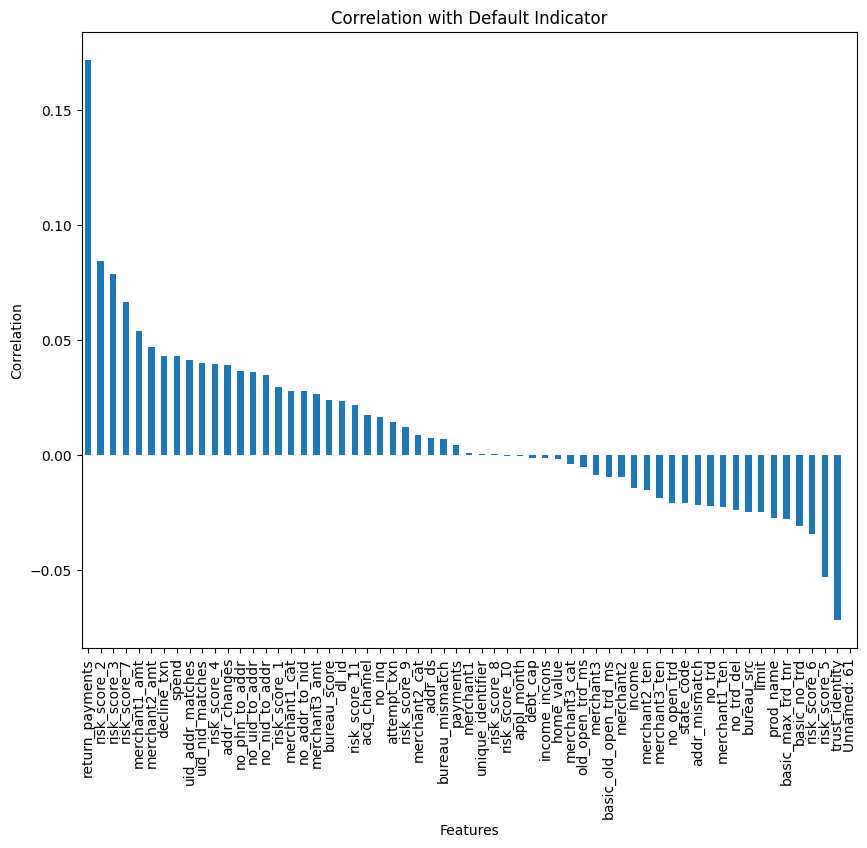

In [ ]:
# prompt: correlation matrix with target column-'default_ind'
import matplotlib.pyplot as plt

corr_matrix = df.corr()
corr_with_target = corr_matrix['default_ind'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10, 8))
corr_with_target.drop('default_ind').plot(kind='bar')
plt.title('Correlation with Default Indicator')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

In [ ]:
df.return_payments.value_counts()

,count
return_payments,
0,60748
40,77
100,48
200,47
500,34
...,...
168,1
9150,1
3600,1


In [ ]:
# prompt: generate a column with value = 1 if retrun_payments > 0 else 0

df['strategy_1'] = df['return_payments'].apply(lambda x: 1 if x > 0 else 0)


In [ ]:
# prompt: how many values of rows of default_ind match strategy_1 and how many dont also in terms of percentage

matching_rows = df[df['default_ind'] == df['strategy_1']].shape[0]
non_matching_rows = df[df['default_ind'] != df['strategy_1']].shape[0]

total_rows = df.shape[0]

matching_percentage = (matching_rows / total_rows) * 100
non_matching_percentage = (non_matching_rows / total_rows) * 100

print(f"Number of matching rows: {matching_rows}")
print(f"Number of non-matching rows: {non_matching_rows}")
print(f"Percentage of matching rows: {matching_percentage:.2f}%")
print(f"Percentage of non-matching rows: {non_matching_percentage:.2f}%")


Matching rows: 60571
Non-matching rows: 1913
Matching percentage: 96.94%
Non-matching percentage: 3.06%


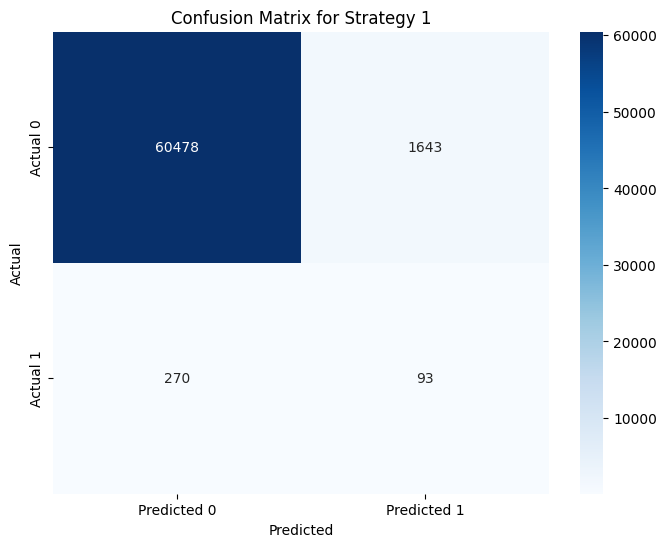

In [ ]:
# prompt: plot FP,TP,FN,TN matrix for strategy_1 and default_ind

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(df['default_ind'], df['strategy_1'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Strategy 1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Risk Score 2 range for predicted 1, actual 0: 0.0 0.24327
Risk Score 2 range for predicted 1, actual 1: 0.00025 0.13199


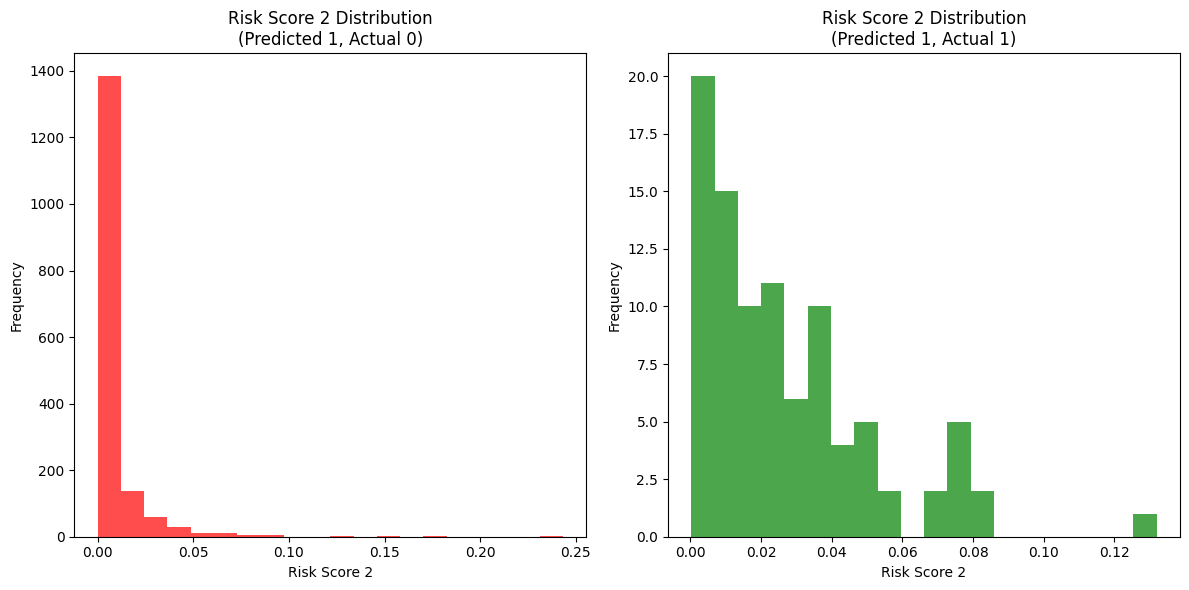

In [ ]:
# prompt: what is risk_score_2 value range for predicted 1 but actual 0 and predicted 1 and actual 1 plot the distribution value

import matplotlib.pyplot as plt
# Filter the DataFrame for the two conditions
predicted_1_actual_0 = df[(df['strategy_1'] == 1) & (df['default_ind'] == 0)]['risk_score_2']
predicted_1_actual_1 = df[(df['strategy_1'] == 1) & (df['default_ind'] == 1)]['risk_score_2']

# Print value ranges
print("Risk Score 2 range for predicted 1, actual 0:", predicted_1_actual_0.min(), predicted_1_actual_0.max())
print("Risk Score 2 range for predicted 1, actual 1:", predicted_1_actual_1.min(), predicted_1_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_1_actual_0, bins=20, color='red', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 1, Actual 0)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_1_actual_1, bins=20, color='green', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 1, Actual 1)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Risk Score 2 range for predicted 0, actual 0: 0.0 0.90711
Risk Score 2 range for predicted 0, actual 1: 0.0 0.18367


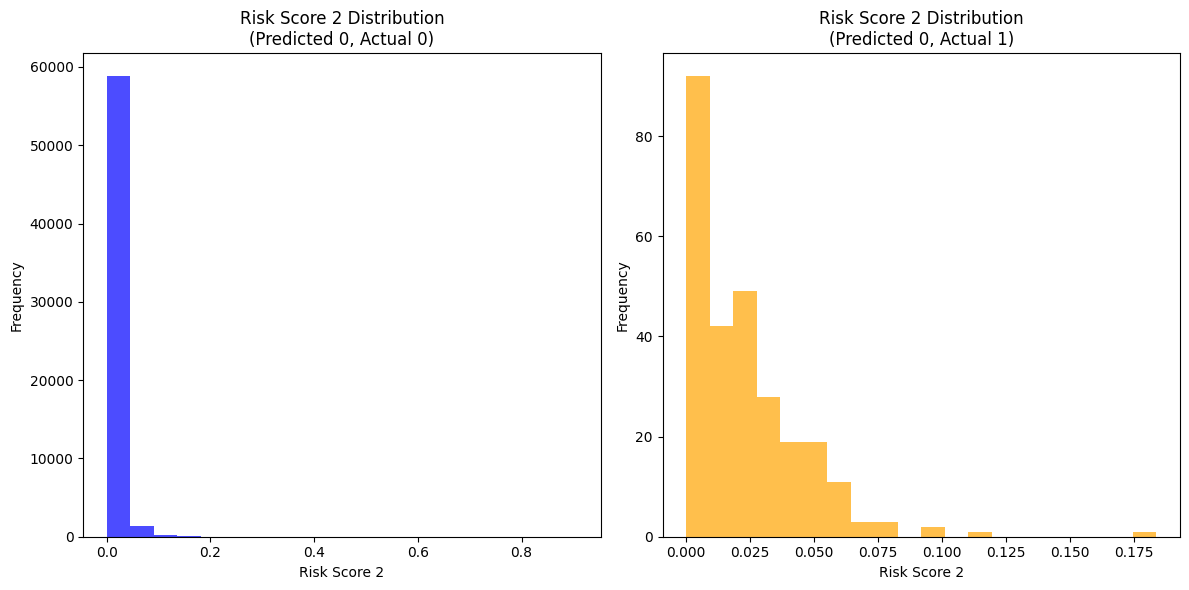

In [ ]:
# prompt: what is risk_score_2 value range for predicted 0 but actual 0 and predicted 0 and actual 1 plot the distribution value

import matplotlib.pyplot as plt
# Filter the DataFrame for the two conditions
predicted_0_actual_0 = df[(df['strategy_1'] == 0) & (df['default_ind'] == 0)]['risk_score_2']
predicted_0_actual_1 = df[(df['strategy_1'] == 0) & (df['default_ind'] == 1)]['risk_score_2']

# Print value ranges
print("Risk Score 2 range for predicted 0, actual 0:", predicted_0_actual_0.min(), predicted_0_actual_0.max())
print("Risk Score 2 range for predicted 0, actual 1:", predicted_0_actual_1.min(), predicted_0_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_0_actual_0, bins=20, color='blue', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 0, Actual 0)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_0_actual_1, bins=20, color='orange', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 0, Actual 1)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

trust_identity  range for predicted 1, actual 0: 0 2
trust_identity  range for predicted 1, actual 1: 0 1


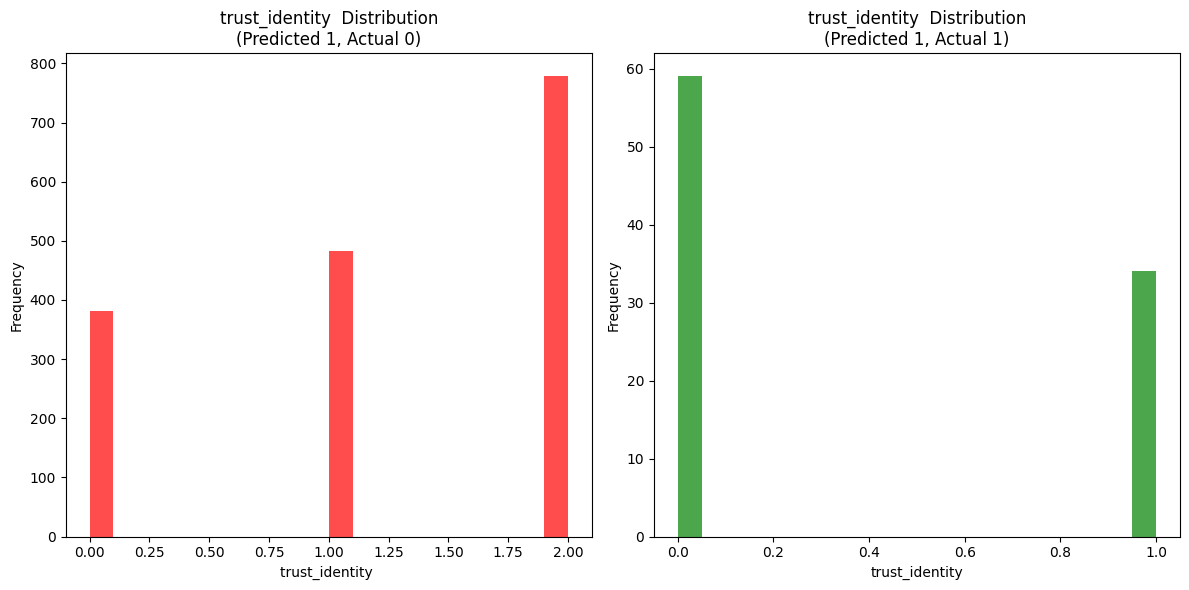

In [ ]:
# prompt: what is risk_score_2 value range for predicted 1 but actual 0 and predicted 1 and actual 1 plot the distribution value

import matplotlib.pyplot as plt
# Filter the DataFrame for the two conditions
predicted_1_actual_0 = df[(df['strategy_1'] == 1) & (df['default_ind'] == 0)]['trust_identity']
predicted_1_actual_1 = df[(df['strategy_1'] == 1) & (df['default_ind'] == 1)]['trust_identity']

# Print value ranges
print("trust_identity  range for predicted 1, actual 0:", predicted_1_actual_0.min(), predicted_1_actual_0.max())
print("trust_identity  range for predicted 1, actual 1:", predicted_1_actual_1.min(), predicted_1_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_1_actual_0, bins=20, color='red', alpha=0.7)
plt.title('trust_identity  Distribution\n(Predicted 1, Actual 0)')
plt.xlabel('trust_identity ')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_1_actual_1, bins=20, color='green', alpha=0.7)
plt.title('trust_identity  Distribution\n(Predicted 1, Actual 1)')
plt.xlabel('trust_identity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


trust_identity range for predicted 0, actual 0: 0 2
trust_identity range for predicted 0, actual 1: 0 2


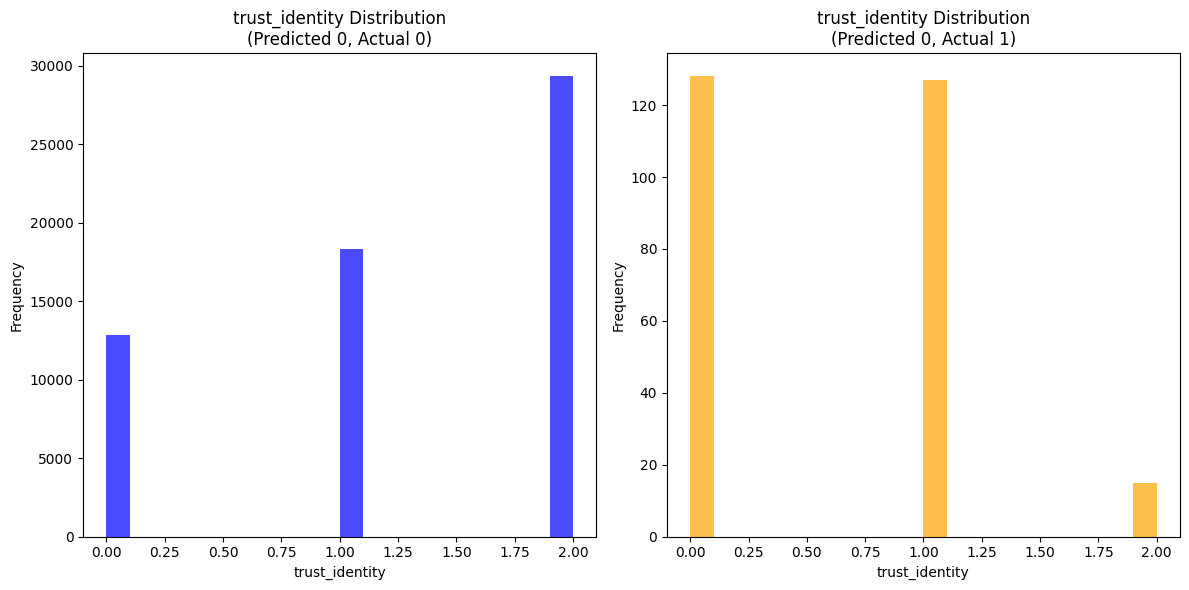

In [ ]:
# prompt: what is risk_score_2 value range for predicted 0 but actual 0 and predicted 0 and actual 1 plot the distribution value

import matplotlib.pyplot as plt
# Filter the DataFrame for the two conditions
predicted_0_actual_0 = df[(df['strategy_1'] == 0) & (df['default_ind'] == 0)]['trust_identity']
predicted_0_actual_1 = df[(df['strategy_1'] == 0) & (df['default_ind'] == 1)]['trust_identity']

# Print value ranges
print("trust_identity range for predicted 0, actual 0:", predicted_0_actual_0.min(), predicted_0_actual_0.max())
print("trust_identity range for predicted 0, actual 1:", predicted_0_actual_1.min(), predicted_0_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_0_actual_0, bins=20, color='blue', alpha=0.7)
plt.title('trust_identity Distribution\n(Predicted 0, Actual 0)')
plt.xlabel('trust_identity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_0_actual_1, bins=20, color='orange', alpha=0.7)
plt.title('trust_identity Distribution\n(Predicted 0, Actual 1)')
plt.xlabel('trust_identity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
# prompt: generate a column with value = if retrun_payments > 0 : 0 if risk_score_2 > 0.13199 else: 1 else: 0 if risk_score_2 > 0.18367 else 1

def generate_value(row):
  if row['return_payments'] > 0:
    if row['trust_identity'] == 1:
      return 0
    else:
      return 1
  else:
    return 0

df['strategy_2'] = df.apply(generate_value, axis=1)


Number of matching rows: 61020
Number of non-matching rows: 1464
Percentage of matching rows: 97.66%
Percentage of non-matching rows: 2.34%


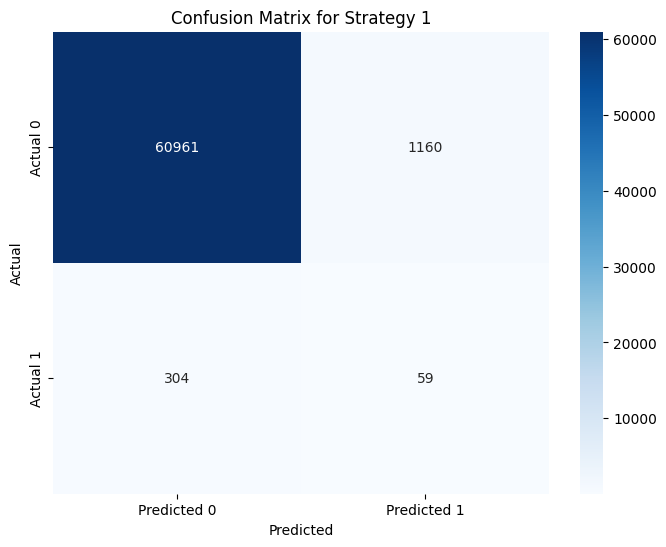

In [ ]:
# prompt: plot FP,TP,FN,TN matrix for strategy_1 and default_ind

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

matching_rows = df[df['default_ind'] == df['strategy_2']].shape[0]
non_matching_rows = df[df['default_ind'] != df['strategy_2']].shape[0]

total_rows = df.shape[0]

matching_percentage = (matching_rows / total_rows) * 100
non_matching_percentage = (non_matching_rows / total_rows) * 100

print(f"Number of matching rows: {matching_rows}")
print(f"Number of non-matching rows: {non_matching_rows}")
print(f"Percentage of matching rows: {matching_percentage:.2f}%")
print(f"Percentage of non-matching rows: {non_matching_percentage:.2f}%")


# Calculate confusion matrix
cm = confusion_matrix(df['default_ind'], df['strategy_2'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Strategy 1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Risk Score 2 range for predicted 1, actual 0: 0.0 0.17725
Risk Score 2 range for predicted 1, actual 1: 0.00025 0.08342
Risk Score 2 range for predicted 0, actual 0: 0.0 0.90711
Risk Score 2 range for predicted 0, actual 1: 0.0 0.18367


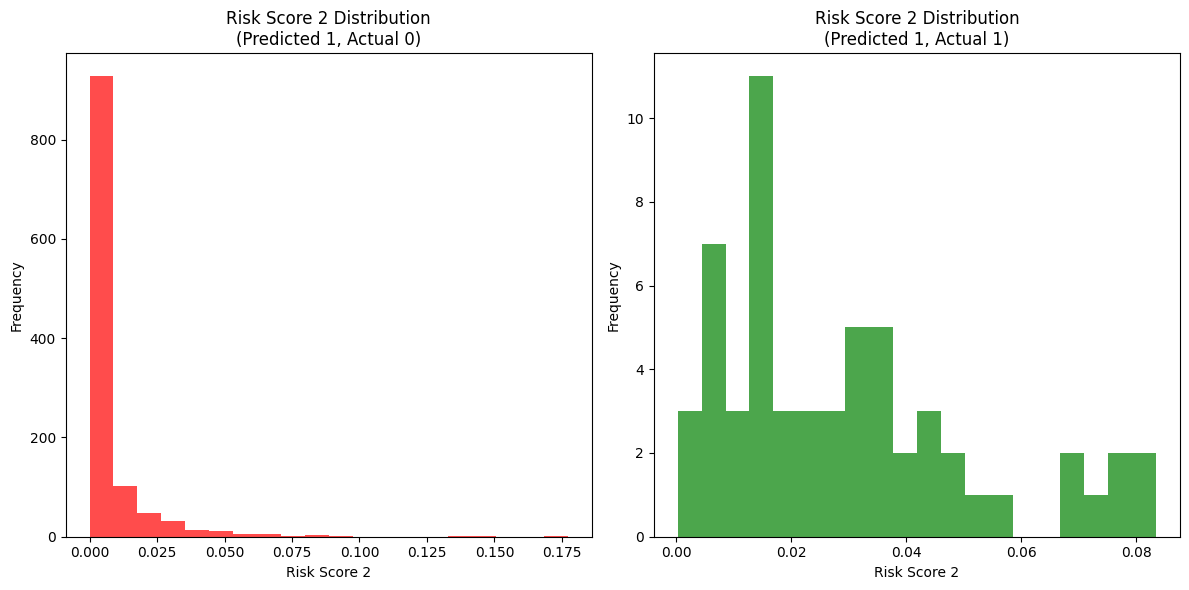

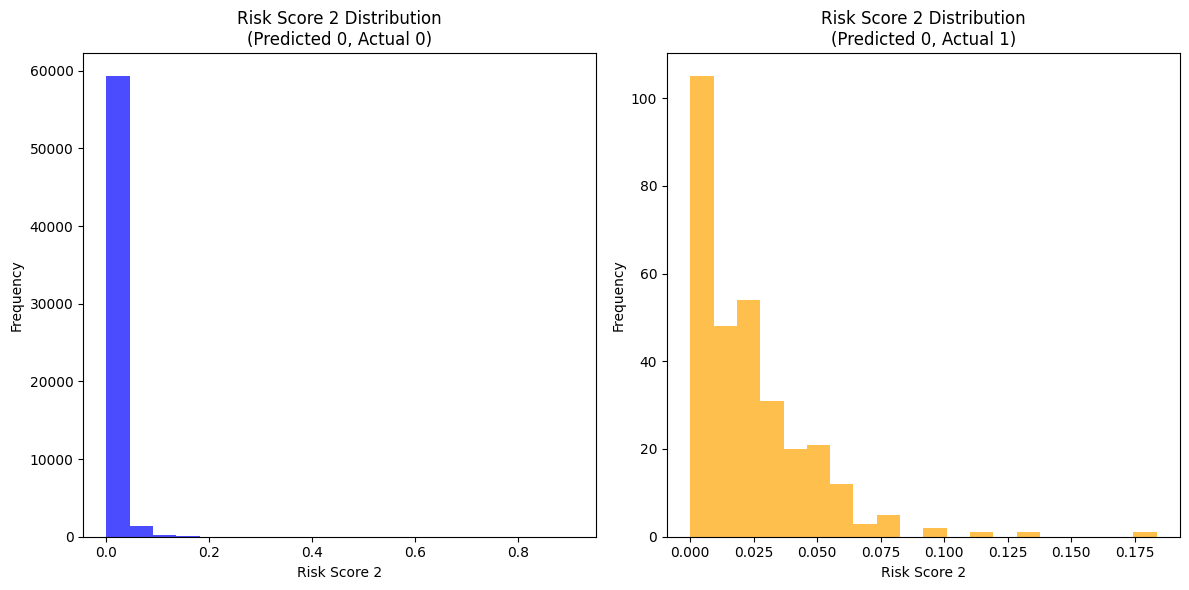

In [ ]:
# prompt: generate the below code for risk_score_2 along with table

import pandas as pd
import matplotlib.pyplot as plt
# Filter the DataFrame for the two conditions
predicted_1_actual_0 = df[(df['strategy_2'] == 1) & (df['default_ind'] == 0)]['risk_score_2']
predicted_1_actual_1 = df[(df['strategy_2'] == 1) & (df['default_ind'] == 1)]['risk_score_2']

# Print value ranges
print("Risk Score 2 range for predicted 1, actual 0:", predicted_1_actual_0.min(), predicted_1_actual_0.max())
print("Risk Score 2 range for predicted 1, actual 1:", predicted_1_actual_1.min(), predicted_1_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_1_actual_0, bins=20, color='red', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 1, Actual 0)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_1_actual_1, bins=20, color='green', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 1, Actual 1)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.tight_layout()


_, bin_edges = np.histogram(np.concatenate((predicted_1_actual_0, predicted_1_actual_1)), bins=20)

# Calculate histogram values for each series
hist_1_actual_0, _ = np.histogram(predicted_1_actual_0, bins=bin_edges)
hist_1_actual_1, _ = np.histogram(predicted_1_actual_1, bins=bin_edges)

# Create a table figure
fig = go.Figure(data=[go.Table(
    header=dict(values=['Risk Score 2 Range', 'Predicted 1, Actual 0', 'Predicted 1, Actual 1'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)],
        hist_1_actual_0,
        hist_1_actual_1
    ],
               fill_color='lavender',
               align='left'))
])

fig.update_layout(title='Risk Score 2 Distribution Table',
                  width=800, height=600)





# Filter the DataFrame for the two conditions
predicted_0_actual_0 = df[(df['strategy_2'] == 0) & (df['default_ind'] == 0)]['risk_score_2']
predicted_0_actual_1 = df[(df['strategy_2'] == 0) & (df['default_ind'] == 1)]['risk_score_2']

# Print value ranges
print("Risk Score 2 range for predicted 0, actual 0:", predicted_0_actual_0.min(), predicted_0_actual_0.max())
print("Risk Score 2 range for predicted 0, actual 1:", predicted_0_actual_1.min(), predicted_0_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_0_actual_0, bins=20, color='blue', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 0, Actual 0)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_0_actual_1, bins=20, color='orange', alpha=0.7)
plt.title('Risk Score 2 Distribution\n(Predicted 0, Actual 1)')
plt.xlabel('Risk Score 2')
plt.ylabel('Frequency')

plt.tight_layout()


_, bin_edges = np.histogram(np.concatenate((predicted_0_actual_0, predicted_0_actual_1)), bins=20)

# Calculate histogram values for each series
hist_0_actual_0, _ = np.histogram(predicted_0_actual_0, bins=bin_edges)
hist_0_actual_1, _ = np.histogram(predicted_0_actual_1, bins=bin_edges)

# Create a table figure
fig1 = go.Figure(data=[go.Table(
    header=dict(values=['Risk Score 2 Range', 'Predicted 0, Actual 0', 'Predicted 0, Actual 1'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)],
        hist_0_actual_0,
        hist_0_actual_1
    ],
               fill_color='lavender',
               align='left'))
])

fig1.update_layout(title='Risk Score 2 Distribution Table',
                  width=800, height=600)

fig.show()
fig1.show()
plt.show()



Risk Score 5 range for predicted 1, actual 0: 0 99
Risk Score 5 range for predicted 1, actual 1: 0 99
Risk Score 5 range for predicted 0, actual 0: 0 99
Risk Score 5 range for predicted 0, actual 1: 0 99


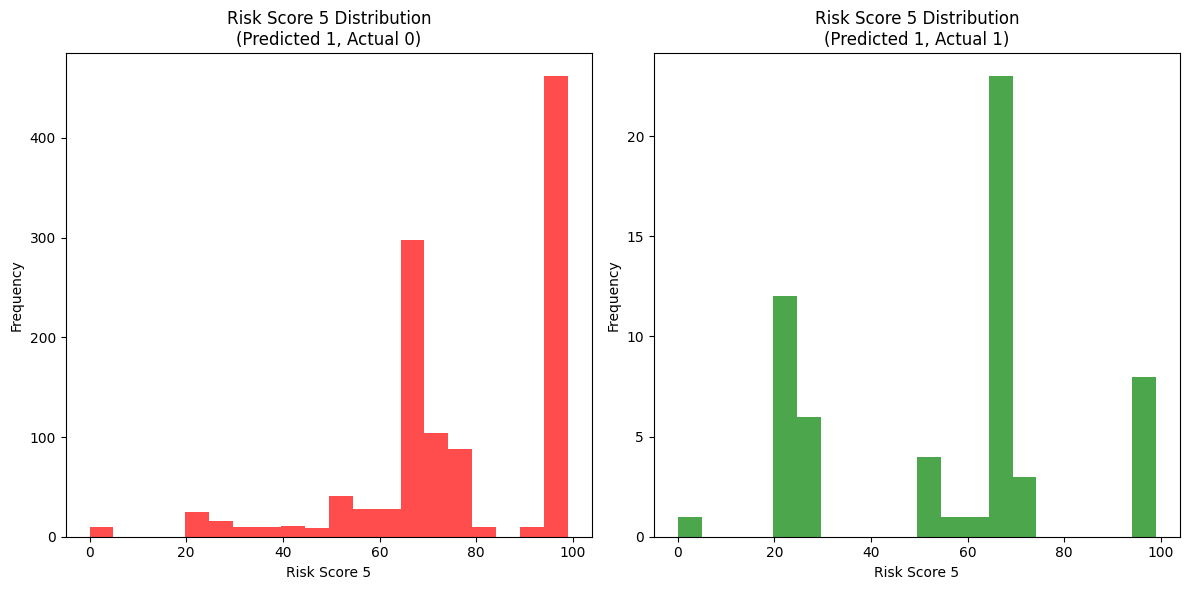

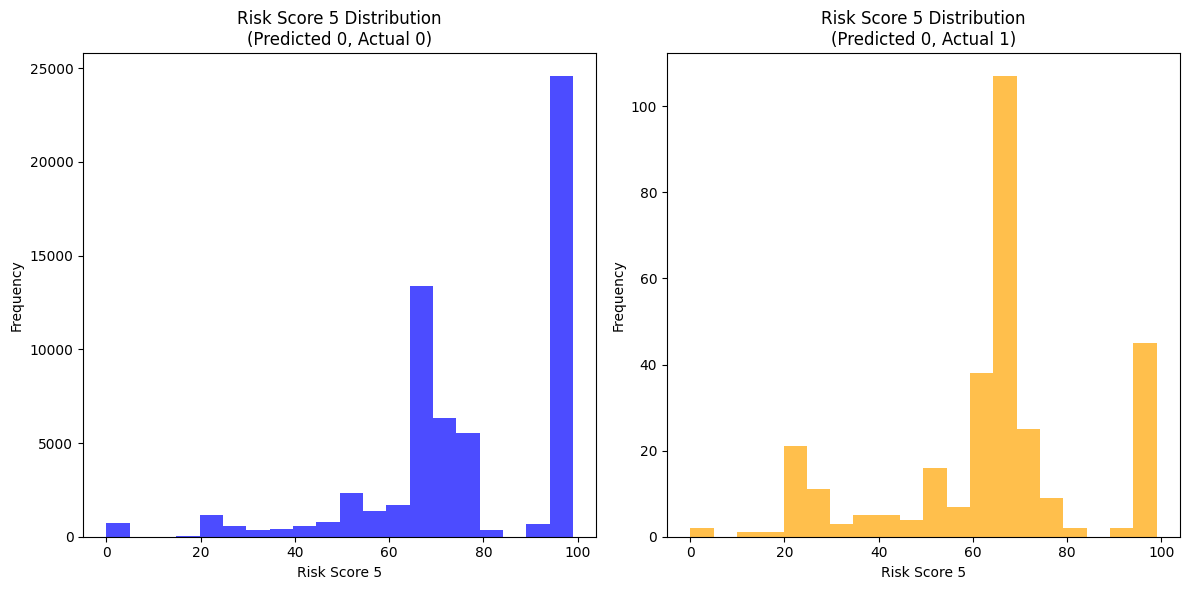

In [ ]:
# prompt:  what is risk_score_2 value range for predicted 1 but actual 0 and predicted 1 and actual 1 for plot the distribution value

import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
# Filter the DataFrame for the two conditions
predicted_1_actual_0 = df[(df['strategy_2'] == 1) & (df['default_ind'] == 0)]['risk_score_5']
predicted_1_actual_1 = df[(df['strategy_2'] == 1) & (df['default_ind'] == 1)]['risk_score_5']

# Print value ranges
print("Risk Score 5 range for predicted 1, actual 0:", predicted_1_actual_0.min(), predicted_1_actual_0.max())
print("Risk Score 5 range for predicted 1, actual 1:", predicted_1_actual_1.min(), predicted_1_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_1_actual_0, bins=20, color='red', alpha=0.7)
plt.title('Risk Score 5 Distribution\n(Predicted 1, Actual 0)')
plt.xlabel('Risk Score 5')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_1_actual_1, bins=20, color='green', alpha=0.7)
plt.title('Risk Score 5 Distribution\n(Predicted 1, Actual 1)')
plt.xlabel('Risk Score 5')
plt.ylabel('Frequency')

plt.tight_layout()



# Assuming 'predicted_1_actual_0' and 'predicted_1_actual_1' are pandas Series

# Calculate bin edges for the histograms
_, bin_edges = np.histogram(np.concatenate((predicted_1_actual_0, predicted_1_actual_1)), bins=20)

# Calculate histogram values for each series
hist_1_actual_0, _ = np.histogram(predicted_1_actual_0, bins=bin_edges)
hist_1_actual_1, _ = np.histogram(predicted_1_actual_1, bins=bin_edges)

# Create a table figure
fig = go.Figure(data=[go.Table(
    header=dict(values=['Risk Score 5 Range', 'Predicted 1, Actual 0', 'Predicted 1, Actual 1'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)],
        hist_1_actual_0,
        hist_1_actual_1
    ],
               fill_color='lavender',
               align='left'))
])

fig.update_layout(title='Risk Score 5 Distribution Table',
                  width=800, height=600)

predicted_0_actual_0 = df[(df['strategy_2'] == 0) & (df['default_ind'] == 0)]['risk_score_5']
predicted_0_actual_1 = df[(df['strategy_2'] == 0) & (df['default_ind'] == 1)]['risk_score_5']

# Print value ranges
print("Risk Score 5 range for predicted 0, actual 0:", predicted_0_actual_0.min(), predicted_0_actual_0.max())
print("Risk Score 5 range for predicted 0, actual 1:", predicted_0_actual_1.min(), predicted_0_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_0_actual_0, bins=20, color='blue', alpha=0.7)
plt.title('Risk Score 5 Distribution\n(Predicted 0, Actual 0)')
plt.xlabel('Risk Score 5')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_0_actual_1, bins=20, color='orange', alpha=0.7)
plt.title('Risk Score 5 Distribution\n(Predicted 0, Actual 1)')
plt.xlabel('Risk Score 5')
plt.ylabel('Frequency')

plt.tight_layout()




_, bin_edges = np.histogram(np.concatenate((predicted_0_actual_0, predicted_0_actual_1)), bins=20)

# Calculate histogram values for each series
hist_0_actual_0, _ = np.histogram(predicted_0_actual_0, bins=bin_edges)
hist_0_actual_1, _ = np.histogram(predicted_0_actual_1, bins=bin_edges)

# Create a table figure
fig1 = go.Figure(data=[go.Table(
    header=dict(values=['Risk Score 5 Range', 'Predicted 0, Actual 0', 'Predicted 0, Actual 1'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)],
        hist_0_actual_0,
        hist_0_actual_1
    ],
               fill_color='lavender',
               align='left'))
])

fig1.update_layout(title='Risk Score 5 Distribution Table',
                  width=800, height=600)

fig.show()
fig1.show()
plt.show()




In [ ]:
# prompt: if risk_score5 29.7 - 49.5, 74.25-94.05 lie in this range then return 0

def generate_value(row):
  if row['return_payments'] > 0:
    if row['trust_identity'] == 1:
      return 0
    else:
      if 29.7 <= row['risk_score_5'] <= 49.5 or 74.25 <= row['risk_score_5'] <= 94.05:
        return 0
      else:
        return 1
  else:
    return 0

df['strategy_3'] = df.apply(generate_value, axis=1)


Number of matching rows: 61168
Number of non-matching rows: 1316
Percentage of matching rows: 97.89%
Percentage of non-matching rows: 2.11%


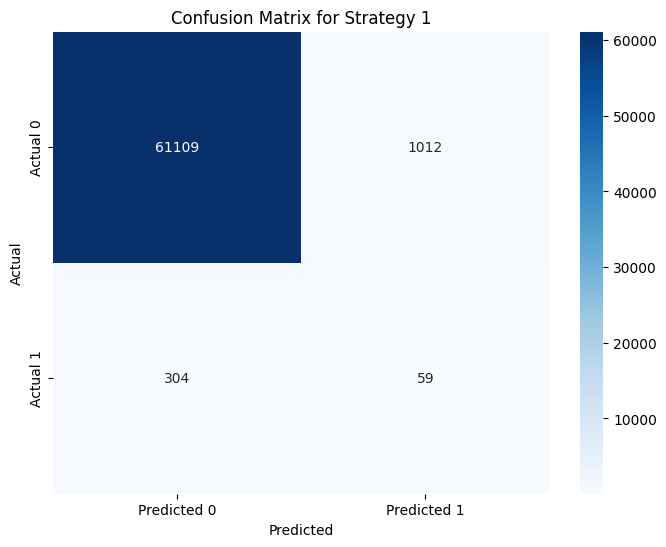

In [ ]:
# prompt: plot FP,TP,FN,TN matrix for strategy_1 and default_ind

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

matching_rows = df[df['default_ind'] == df['strategy_3']].shape[0]
non_matching_rows = df[df['default_ind'] != df['strategy_3']].shape[0]

total_rows = df.shape[0]

matching_percentage = (matching_rows / total_rows) * 100
non_matching_percentage = (non_matching_rows / total_rows) * 100

print(f"Number of matching rows: {matching_rows}")
print(f"Number of non-matching rows: {non_matching_rows}")
print(f"Percentage of matching rows: {matching_percentage:.2f}%")
print(f"Percentage of non-matching rows: {non_matching_percentage:.2f}%")


# Calculate confusion matrix
cm = confusion_matrix(df['default_ind'], df['strategy_3'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Strategy 1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# prompt: F1 score for strategy 3 and default_ind

from sklearn.metrics import f1_score
f1 = f1_score(df['default_ind'], df['strategy_3'],average='micro')
print("F1 Score for Strategy 3:", f1)


F1 Score for Strategy 3: 0.9789386082837206


merchan1_amt range for predicted 1, actual 0: nan nan
merchan1_amt range for predicted 1, actual 1: nan nan
merchan1_amt range for predicted 0, actual 0: 0 134
merchan1_amt range for predicted 0, actual 1: 0 21


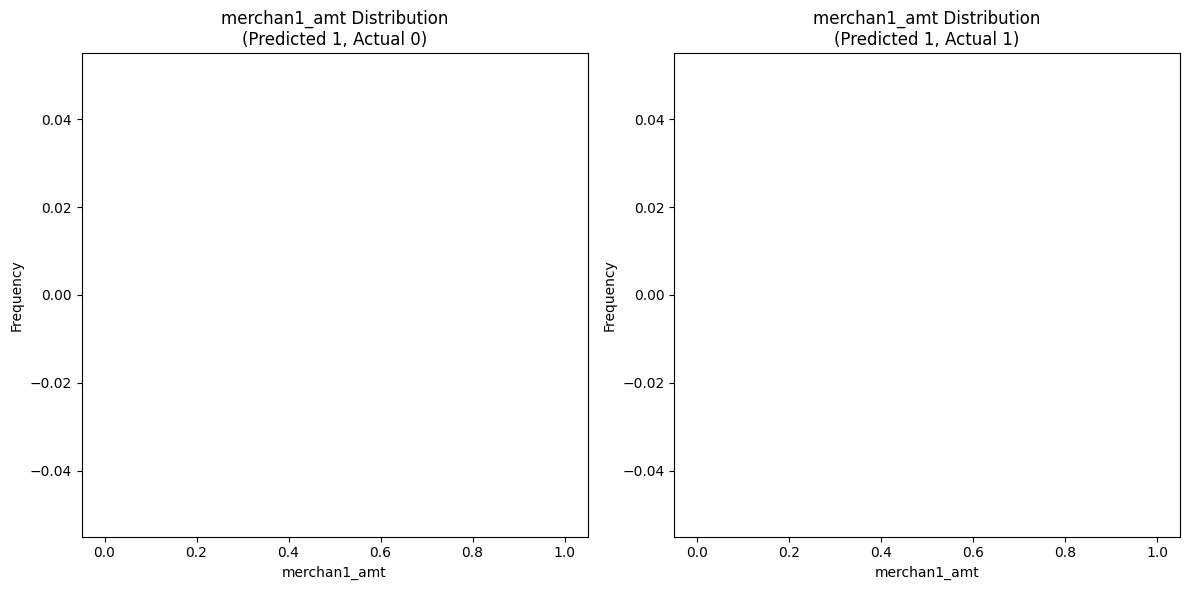

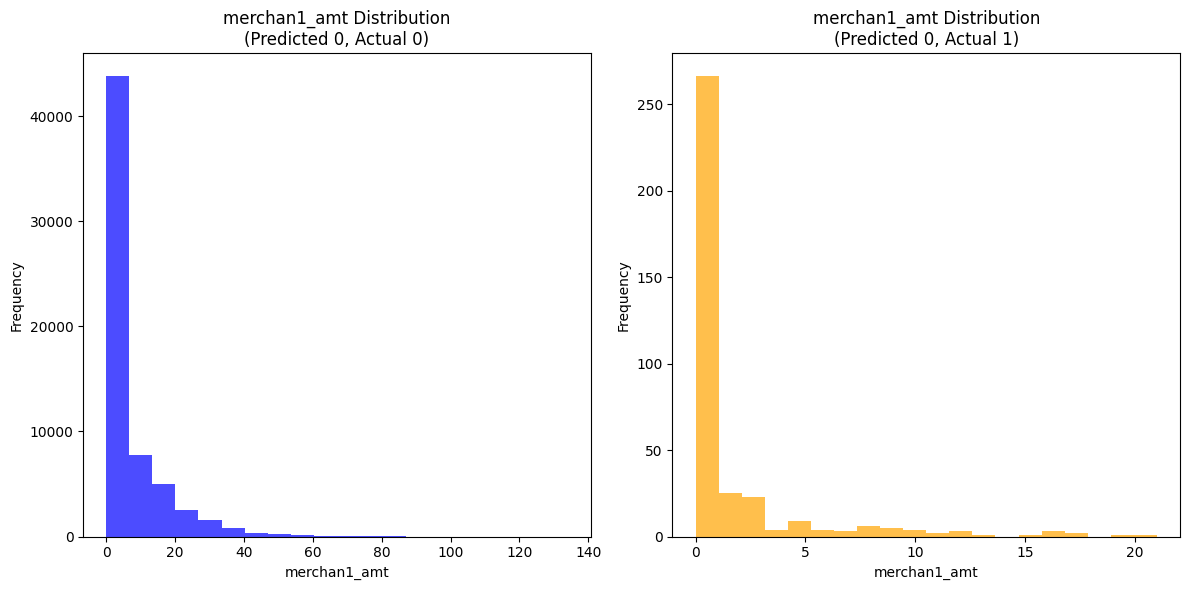

In [ ]:
# prompt: replace risk_score_6 with merchan1_amt in below code

import matplotlib.pyplot as plt
import numpy as np
# Filter the DataFrame for the two conditions
predicted_1_actual_0 = df[(df['strategy_3'] == 1) & (df['default_ind'] == 0)]['basic_no_trd']
predicted_1_actual_1 = df[(df['strategy_3'] == 1) & (df['default_ind'] == 1)]['basic_no_trd']

# Print value ranges
print("merchan1_amt range for predicted 1, actual 0:", predicted_1_actual_0.min(), predicted_1_actual_0.max())
print("merchan1_amt range for predicted 1, actual 1:", predicted_1_actual_1.min(), predicted_1_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_1_actual_0, bins=20, color='red', alpha=0.7)
plt.title('merchan1_amt Distribution\n(Predicted 1, Actual 0)')
plt.xlabel('merchan1_amt')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_1_actual_1, bins=20, color='green', alpha=0.7)
plt.title('merchan1_amt Distribution\n(Predicted 1, Actual 1)')
plt.xlabel('merchan1_amt')
plt.ylabel('Frequency')

plt.tight_layout()



# Assuming 'predicted_1_actual_0' and 'predicted_1_actual_1' are pandas Series

# Calculate bin edges for the histograms
_, bin_edges = np.histogram(np.concatenate((predicted_1_actual_0, predicted_1_actual_1)), bins=20)

# Calculate histogram values for each series
hist_1_actual_0, _ = np.histogram(predicted_1_actual_0, bins=bin_edges)
hist_1_actual_1, _ = np.histogram(predicted_1_actual_1, bins=bin_edges)

# Create a table figure
fig = go.Figure(data=[go.Table(
    header=dict(values=['merchan1_amt Range', 'Predicted 1, Actual 0', 'Predicted 1, Actual 1'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)],
        hist_1_actual_0,
        hist_1_actual_1
    ],
               fill_color='lavender',
               align='left'))
])

fig.update_layout(title='merchan1_amt Distribution Table',
                  width=800, height=600)

predicted_0_actual_0 = df[(df['strategy_3'] == 0) & (df['default_ind'] == 0)]['basic_no_trd']
predicted_0_actual_1 = df[(df['strategy_3'] == 0) & (df['default_ind'] == 1)]['basic_no_trd']

# Print value ranges
print("merchan1_amt range for predicted 0, actual 0:", predicted_0_actual_0.min(), predicted_0_actual_0.max())
print("merchan1_amt range for predicted 0, actual 1:", predicted_0_actual_1.min(), predicted_0_actual_1.max())

# Plot distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(predicted_0_actual_0, bins=20, color='blue', alpha=0.7)
plt.title('merchan1_amt Distribution\n(Predicted 0, Actual 0)')
plt.xlabel('merchan1_amt')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(predicted_0_actual_1, bins=20, color='orange', alpha=0.7)
plt.title('merchan1_amt Distribution\n(Predicted 0, Actual 1)')
plt.xlabel('merchan1_amt')
plt.ylabel('Frequency')

plt.tight_layout()




_, bin_edges = np.histogram(np.concatenate((predicted_0_actual_0, predicted_0_actual_1)), bins=20)

# Calculate histogram values for each series
hist_0_actual_0, _ = np.histogram(predicted_0_actual_0, bins=bin_edges)
hist_0_actual_1, _ = np.histogram(predicted_0_actual_1, bins=bin_edges)

# Create a table figure
fig1 = go.Figure(data=[go.Table(
    header=dict(values=['merchan1_amt Range', 'Predicted 0, Actual 0', 'Predicted 0, Actual 1'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)],
        hist_0_actual_0,
        hist_0_actual_1
    ],
               fill_color='lavender',
               align='left'))
])

fig1.update_layout(title='merchan1_amt Distribution Table',
                  width=800, height=600)

fig.show()
fig1.show()
plt.show()


In [ ]:
# prompt: appl_month for unique_identifier = 158686
# 118746
# 152895
# 116031
# 130049

# Assuming 'df' is your DataFrame
df_f[df_f['unique_identifier'].isin([158686, 118746, 152895, 116031, 130049])]['appl_month']


,appl_month
2,Jun
5,Feb
381,Jun
502,Feb
572,Mar


In [ ]:
# Filter the dataset for fraud cases in April, March, and May
data = pd.read_csv('amex.csv')
fraud_surge_months = data[(data['appl_month'].isin(['Apr', 'Mar', 'May'])) & (data['default_ind'] == 1)]


In [ ]:
# Display summary statistics for the risk scores
risk_score_summary = fraud_surge_months[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                         'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                         'risk_score_9', 'risk_score_10', 'risk_score_11']].describe()
print(risk_score_summary)


       risk_score_1  risk_score_2  risk_score_3  risk_score_4  risk_score_5  \
count    215.000000    215.000000    215.000000    215.000000    215.000000   
mean       2.279070      0.021114     54.674419    208.609302     63.339535   
std        2.739752      0.019635     96.104140    277.102457     21.818732   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.450000      0.004845      2.000000      0.000000     55.000000   
50%        1.500000      0.015620     16.000000     50.000000     67.000000   
75%        3.100000      0.031625     77.500000    500.000000     69.500000   
max       20.900000      0.083420    980.000000    940.000000     99.000000   

       risk_score_6  risk_score_7  risk_score_8  risk_score_9  risk_score_10  \
count    215.000000    215.000000    215.000000    215.000000     215.000000   
mean      42.362791    398.511628      0.053112      0.008227       0.047242   
std       33.756391     97.982921      0.177125 

In [ ]:
# Check for inconsistencies in financial indicators
financial_indicators = fraud_surge_months[['income', 'limit', 'debt_cap']].describe()
print(financial_indicators)


              income         limit       debt_cap
count     215.000000    215.000000     215.000000
mean    93674.418605   8630.232558   54166.569927
std     80963.739700   7886.861631   46252.281466
min     20000.000000   1000.000000  -66809.115330
25%     55000.000000   2500.000000   30762.166665
50%     75000.000000   5000.000000   46666.666670
75%    100000.000000  13000.000000   65258.083335
max    750000.000000  35000.000000  439021.333300


In [ ]:
# Evaluate trade and merchant activity
trade_merchant_activity = fraud_surge_months[['no_open_trd', 'no_trd', 'merchant1_amt', 'merchant2_amt', 'merchant3_amt']].describe()
print(trade_merchant_activity)


       no_open_trd      no_trd  merchant1_amt  merchant2_amt  merchant3_amt
count   215.000000  215.000000     215.000000     215.000000     215.000000
mean      2.446512    5.120930    4363.652977    1116.373767     513.801302
std       2.953799    7.190614   10976.737014    2243.476569    1069.674185
min       0.000000    0.000000       0.000000       0.000000       0.000000
25%       1.000000    1.000000     131.435000       0.000000       0.000000
50%       1.000000    2.000000    1975.250000     205.900000      43.090000
75%       3.000000    6.500000    4741.810000    1116.065000     536.675000
max      19.000000   44.000000  136522.740000   17692.500000    7652.440000


In [ ]:
# List the unique identifiers of the identified fraudsters
fraudsters_identified = fraud_surge_months['unique_identifier'].unique()
print(fraudsters_identified)
print(len(fraudsters_identified), len(fraud_surge_months))

[140105 130049 131211 131237 131250 131246 144473 131256 142058 131239
 137021 139530 150593 131210 141662 131249 138594 131247 131240 131236
 140941 128457 131040 140940 140773 137974 131253 141675 141673 141676
 141667 131257 141664 141670 141668 131238 141672 141666 131242 141674
 141665 141669 131245 131251 131254 141661 137684 131217 142101 139174
 149174 146765 148943 140386 139793 129672 135929 140803 140991 130231
 143443 141343 135480 125358 145695 136297 131225 124686 136851 144737
 126113 148704 150815 137024 148895 131212 142634 135783 124049 141719
 139511 126571 140780 144352 139257 138531 129364 128140 135782 128954
 139135 138104 136494 136921 124282 124820 151769 149026 131213 131222
 150619 141723 131208 145753 130833 125708 139411 147121 138123 138100
 131218 128900 144614 145918 146159 122422 136167 139531 137069 145095
 129819 131209 128352 143999 148566 123902 123415 131215 127155 141663
 145165 144348 128563 132010 125147 120821 141874 131234 120811 131235
 13123

#2

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('amex.csv')
df

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62479,120631,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,800,31300,150000,...,168677,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,168698,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,168742,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN
62482,154260,Jun,Product 5,Channel 2,NY,No Bureau Hit,0.0,775,5000,160000,...,168754,0.0,48,0,0.002,0.0002,0.162,0.2787,0,NaN


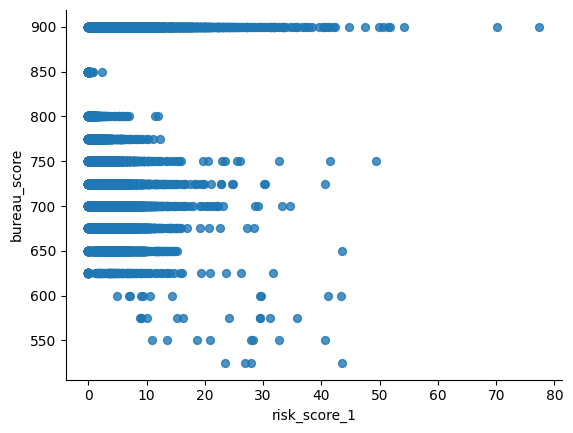

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='risk_score_1', y='bureau_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

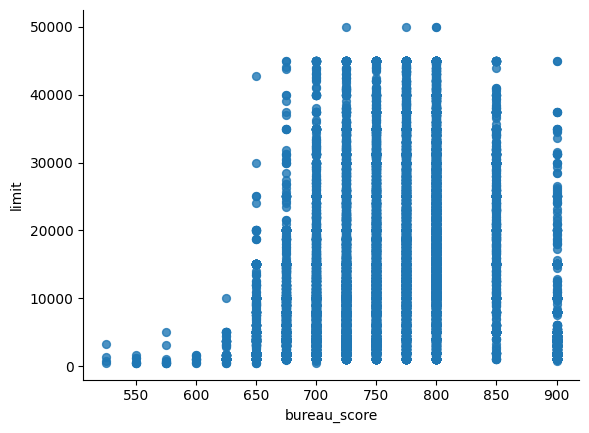

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='bureau_score', y='limit', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

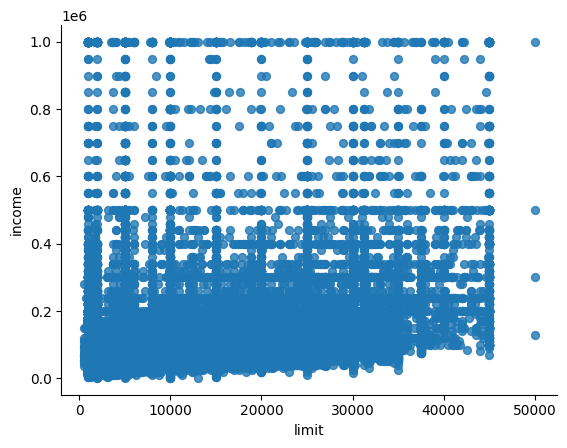

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='limit', y='income', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

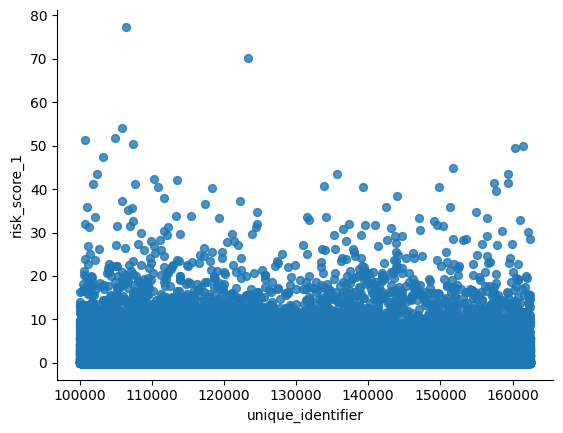

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='unique_identifier', y='risk_score_1', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

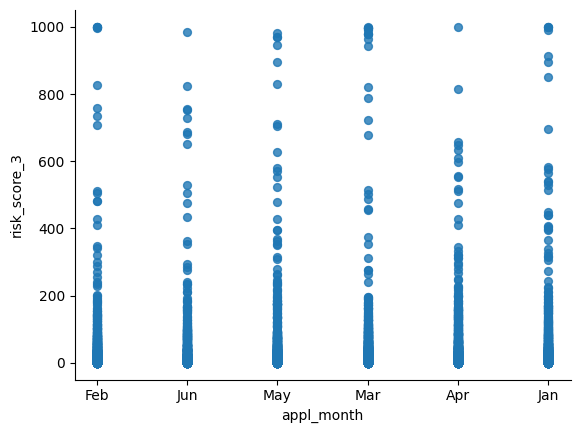

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='appl_month', y='risk_score_3', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

IndexError: index 10 is out of bounds for axis 0 with size 10

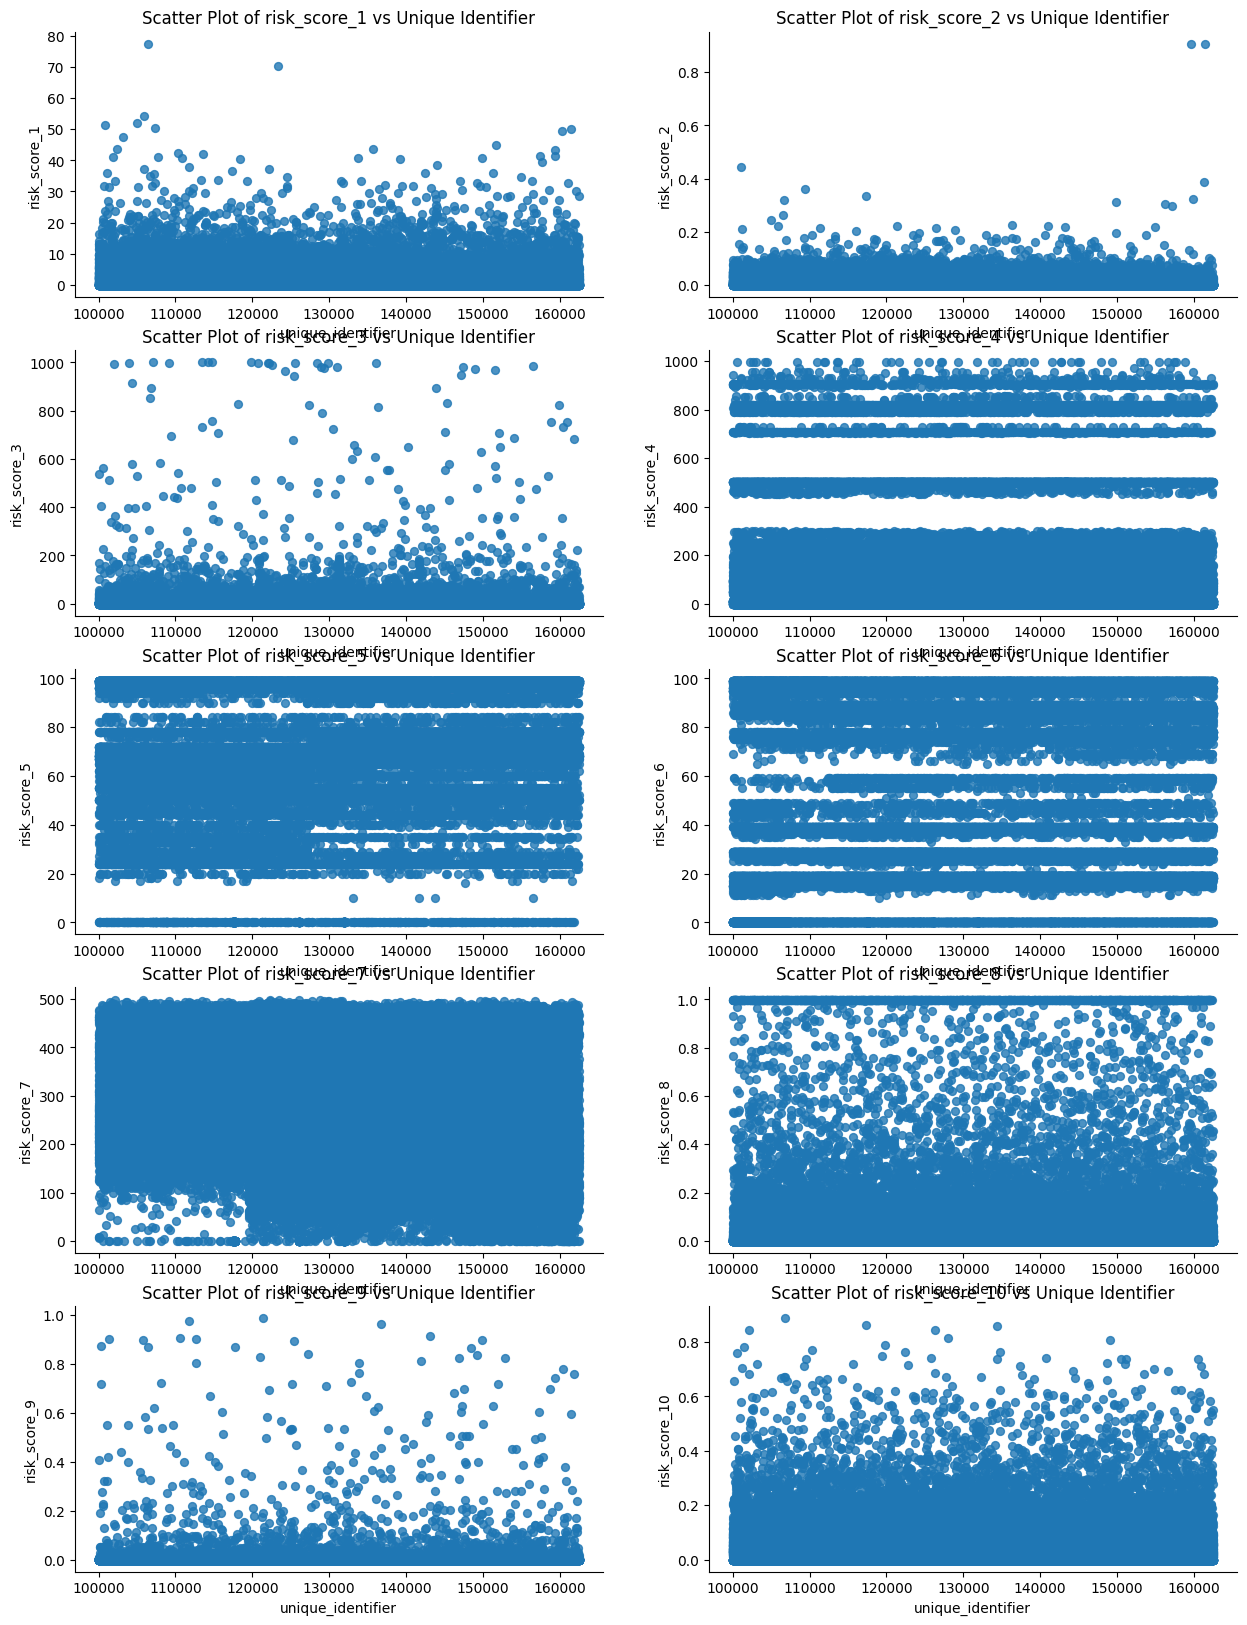

In [ ]:
# prompt: generate upon plot for all risk_scores

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over risk scores and plot
for i, risk_score in enumerate(['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                 'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                 'risk_score_9', 'risk_score_10', 'risk_score_11']):
  df.plot(kind='scatter', x='unique_identifier', y=risk_score, ax=axes[i], s=32, alpha=.8)
  axes[i].set_title(f'Scatter Plot of {risk_score} vs Unique Identifier')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


IndexError: index 10 is out of bounds for axis 0 with size 10

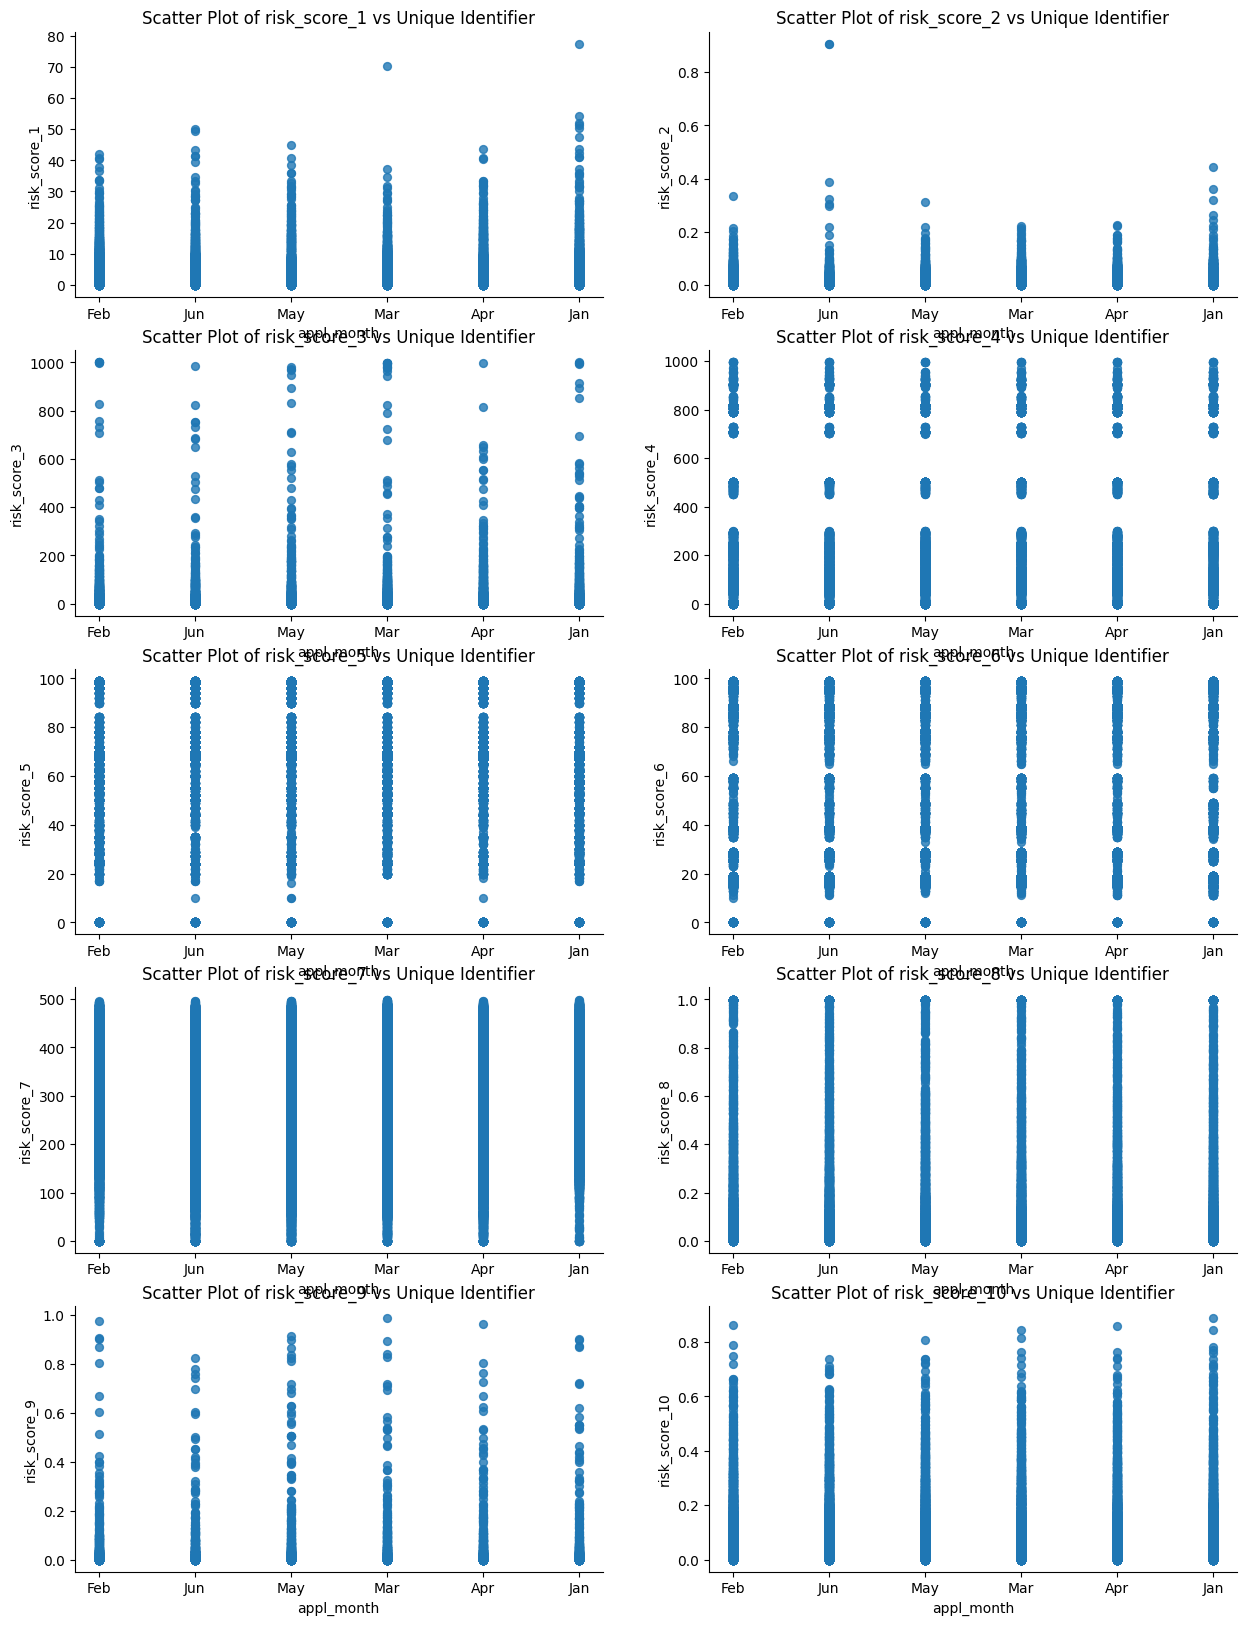

In [ ]:
# prompt: generate upon plot for all risk_scores

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over risk scores and plot
for i, risk_score in enumerate(['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                 'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                 'risk_score_9', 'risk_score_10', 'risk_score_11']):
  df.plot(kind='scatter', x='appl_month', y=risk_score, ax=axes[i], s=32, alpha=.8)
  axes[i].set_title(f'Scatter Plot of {risk_score} vs Unique Identifier')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


IndexError: index 10 is out of bounds for axis 0 with size 10

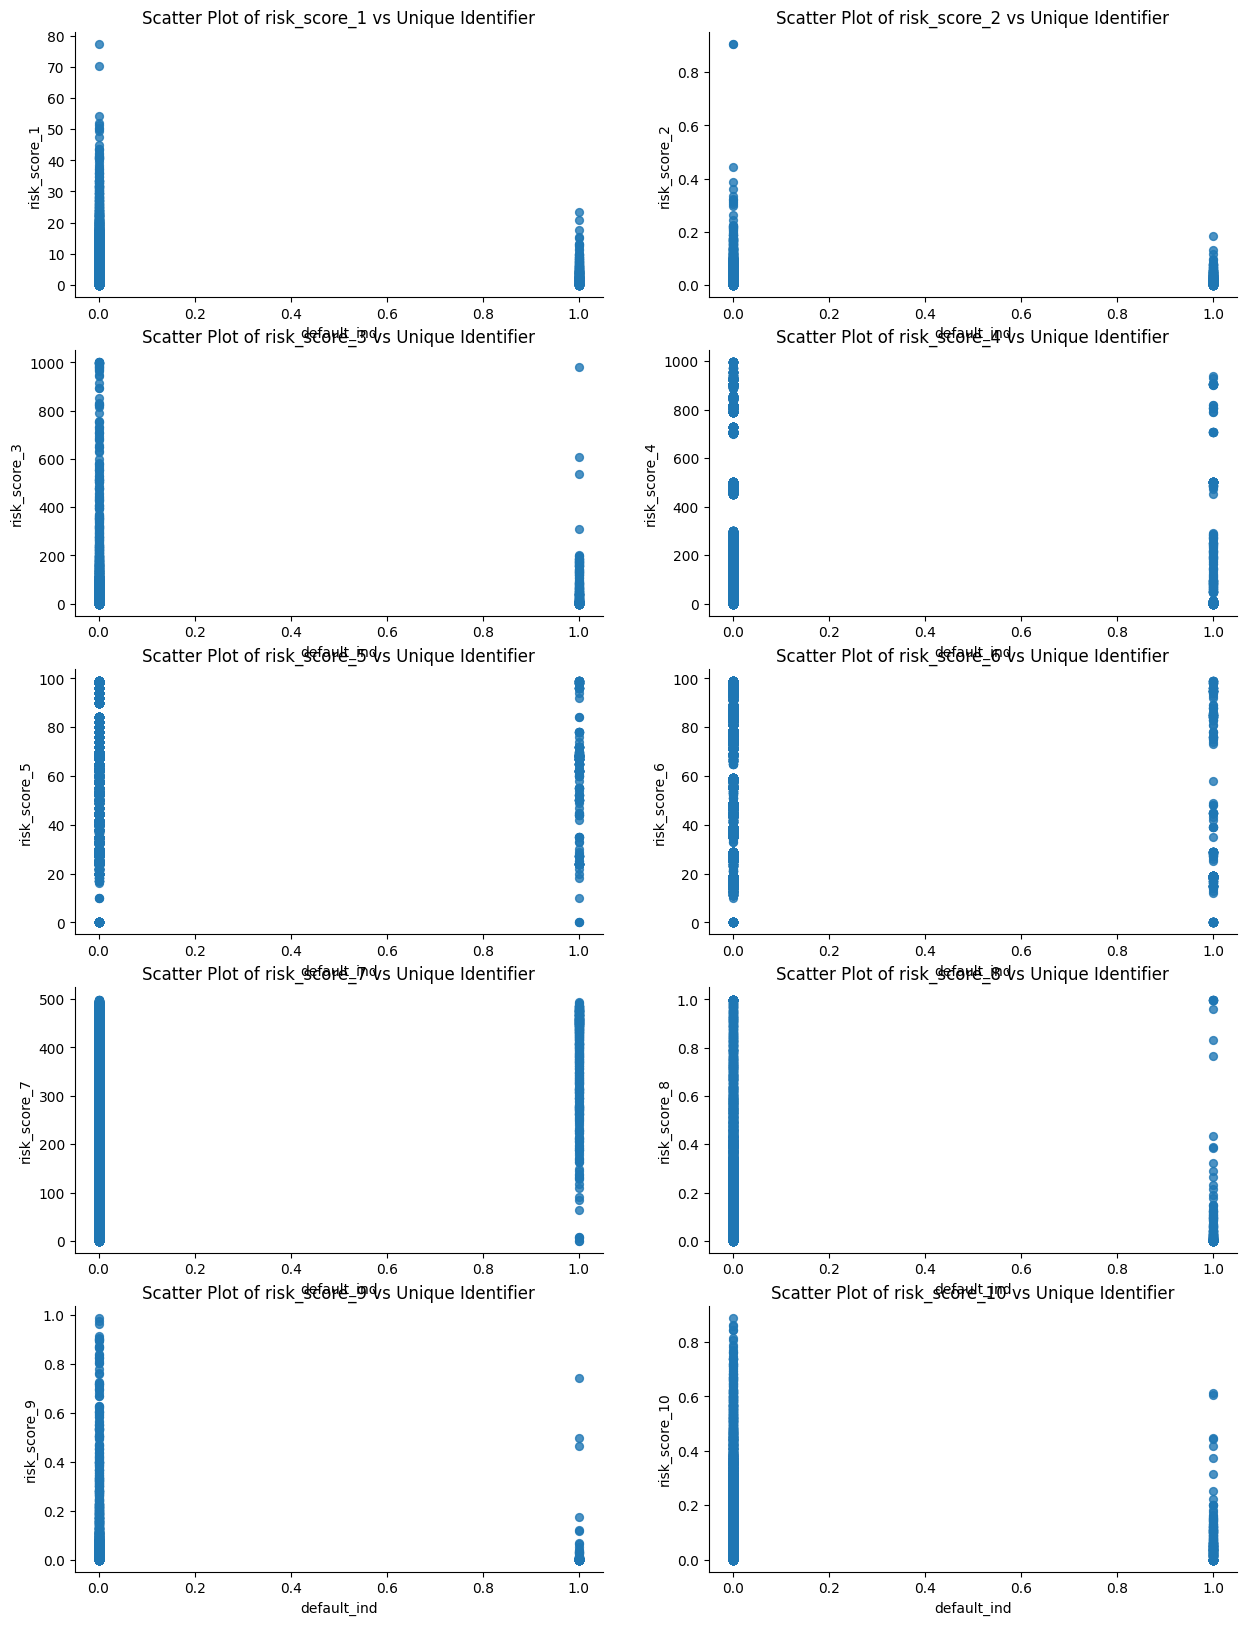

In [ ]:
# prompt: generate upon plot for all risk_scores

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over risk scores and plot
for i, risk_score in enumerate(['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                 'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                 'risk_score_9', 'risk_score_10', 'risk_score_11']):
  df.plot(kind='scatter', x='default_ind', y=risk_score, ax=axes[i], s=32, alpha=.8)
  axes[i].set_title(f'Scatter Plot of {risk_score} vs Unique Identifier')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# prompt: 3d plot of risk_score defaul_ind and appl_month interactive in notebook

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import f1_score
from matplotlib import pyplot as plt
import plotly.express as px

# Assuming 'df' is your DataFrame
fig = px.scatter_3d(df, x='risk_score_7', y='default_ind', z='appl_month',
                    color='default_ind',
                    size='risk_score_7',
                    hover_name='unique_identifier',
                    hover_data=['risk_score_7', 'default_ind', 'appl_month'],
                    width=800, height=600)

fig.update_layout(title='Interactive 3D Scatter Plot of Risk Score, Default Indicator, and Application Month')
fig.show()


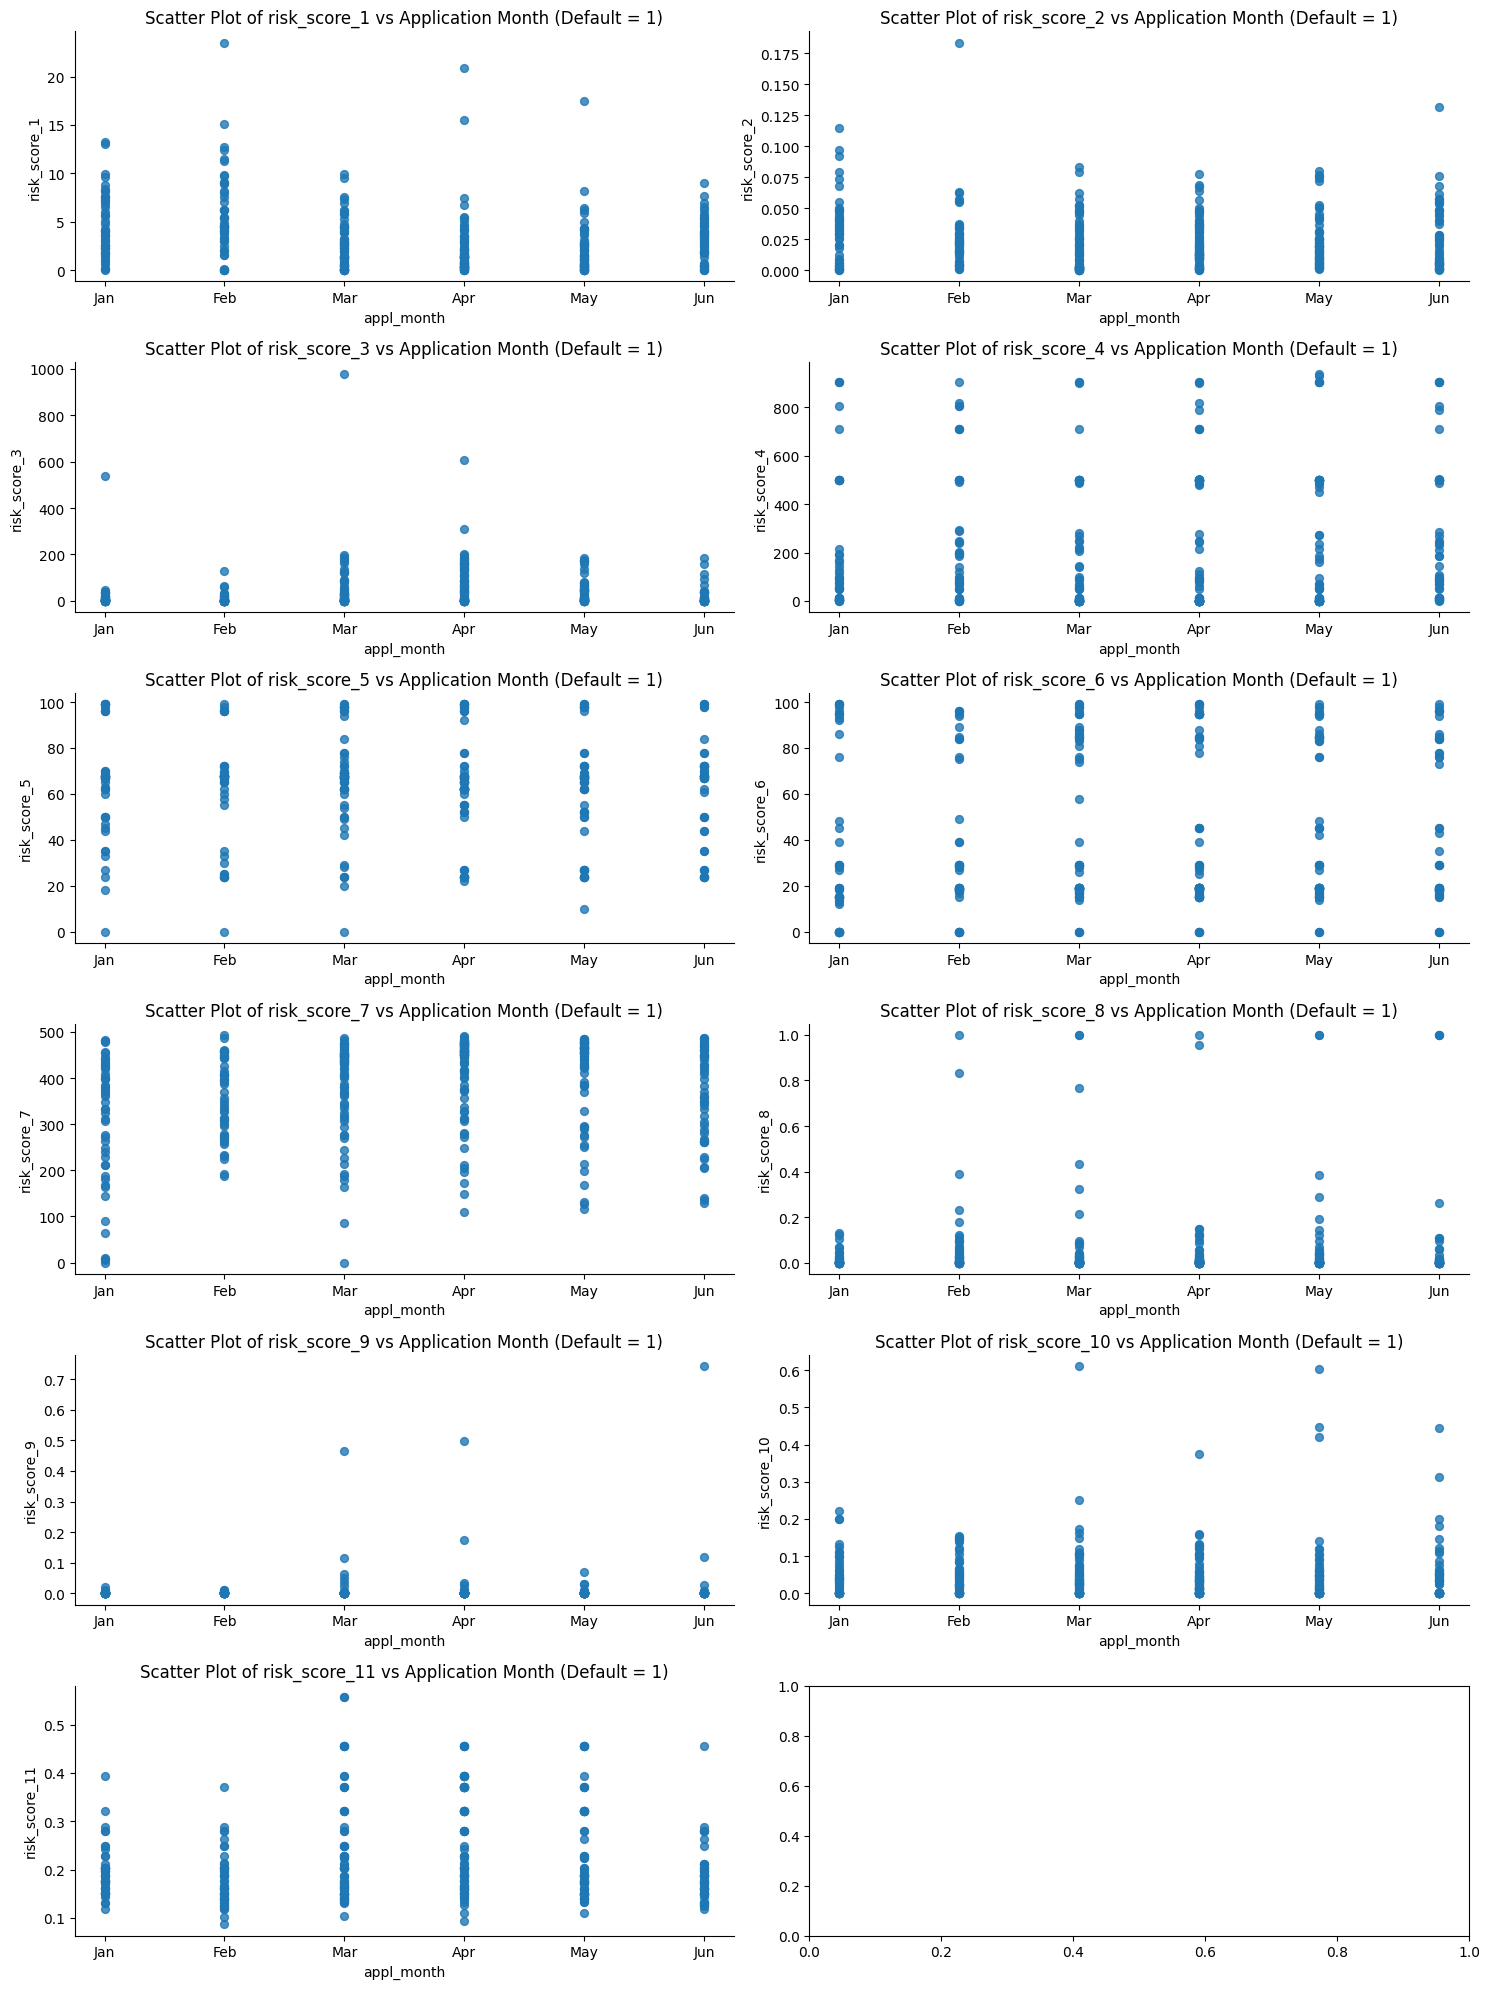

In [ ]:
# prompt: plot all risk score vs appl_month where default_ind=1 ordered by Jan, Feb, Mar, Apr, May, Jun

import matplotlib.pyplot as plt
# Filter the DataFrame for default_ind == 1
df_default = df[df['default_ind'] == 1]

# Define the order of months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over risk scores and plot
for i, risk_score in enumerate(['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                 'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                 'risk_score_9', 'risk_score_10', 'risk_score_11']):
  # Sort the data by month
  df_default_sorted = df_default.sort_values(by=['appl_month'], key=lambda x: x.map({month: i for i, month in enumerate(month_order)}))

  # Plot the scatter plot
  df_default_sorted.plot(kind='scatter', x='appl_month', y=risk_score, ax=axes[i], s=32, alpha=.8)
  axes[i].set_title(f'Scatter Plot of {risk_score} vs Application Month (Default = 1)')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# prompt: filter rows with a risk_score_11 above 0.4 and risk_score_9 above 0.2 and default_ind =1

filtered_df = df[(df['risk_score_11'] > 0.1) & (df['risk_score_9'] > 0.05) & (df['default_ind'] == 1)]
filtered_df

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
3310,128457,Mar,Product 1,Channel 3,WA,No Bureau Hit,0.0,725,17900,160000,...,156589,2771.81,12,0,0.767,0.1161,0.022,0.1858,1,NaN
8178,139793,Apr,Product 1,Channel 3,FL,Bureau 1,1.3,750,6000,75000,...,0,0.00,0,0,0.999,0.4971,0.040,0.1592,1,NaN
10807,130231,Mar,Product 1,Channel 3,FL,No Bureau Hit,0.0,800,14800,90000,...,154115,1815.64,12,1,0.086,0.0645,0.102,0.1439,1,NaN
11989,158418,Jun,Product 1,Channel 3,FL,Bureau 1,0.0,900,5000,130000,...,166063,2445.84,12,0,0.263,0.1192,0.146,0.1680,1,NaN
13206,125358,Mar,Product 6,Channel 1,CA,Bureau 1,2.7,900,1000,100000,...,156781,415.04,12,0,0.036,0.0515,0.028,0.1490,1,NaN
17756,148895,May,Product 1,Channel 3,NY,No Bureau Hit,0.0,800,10000,200000,...,128948,1530.47,12,0,0.999,0.0695,0.049,0.1884,1,NaN
18399,131212,Mar,Product 1,Channel 2,IL,Bureau 1,0.1,800,27000,440000,...,130938,336.02,11,0,0.999,0.4649,0.032,0.2107,1,NaN
19837,159395,Jun,Product 1,Channel 3,GA,Bureau 1,4.6,675,1000,40000,...,141033,3622.20,12,0,0.999,0.7430,0.051,0.1609,1,NaN
30575,139411,Apr,Product 7,Channel 2,CA,Bureau 1,3.3,675,10000,80000,...,163925,2600.00,22,0,0.088,0.1739,0.072,0.2787,1,NaN


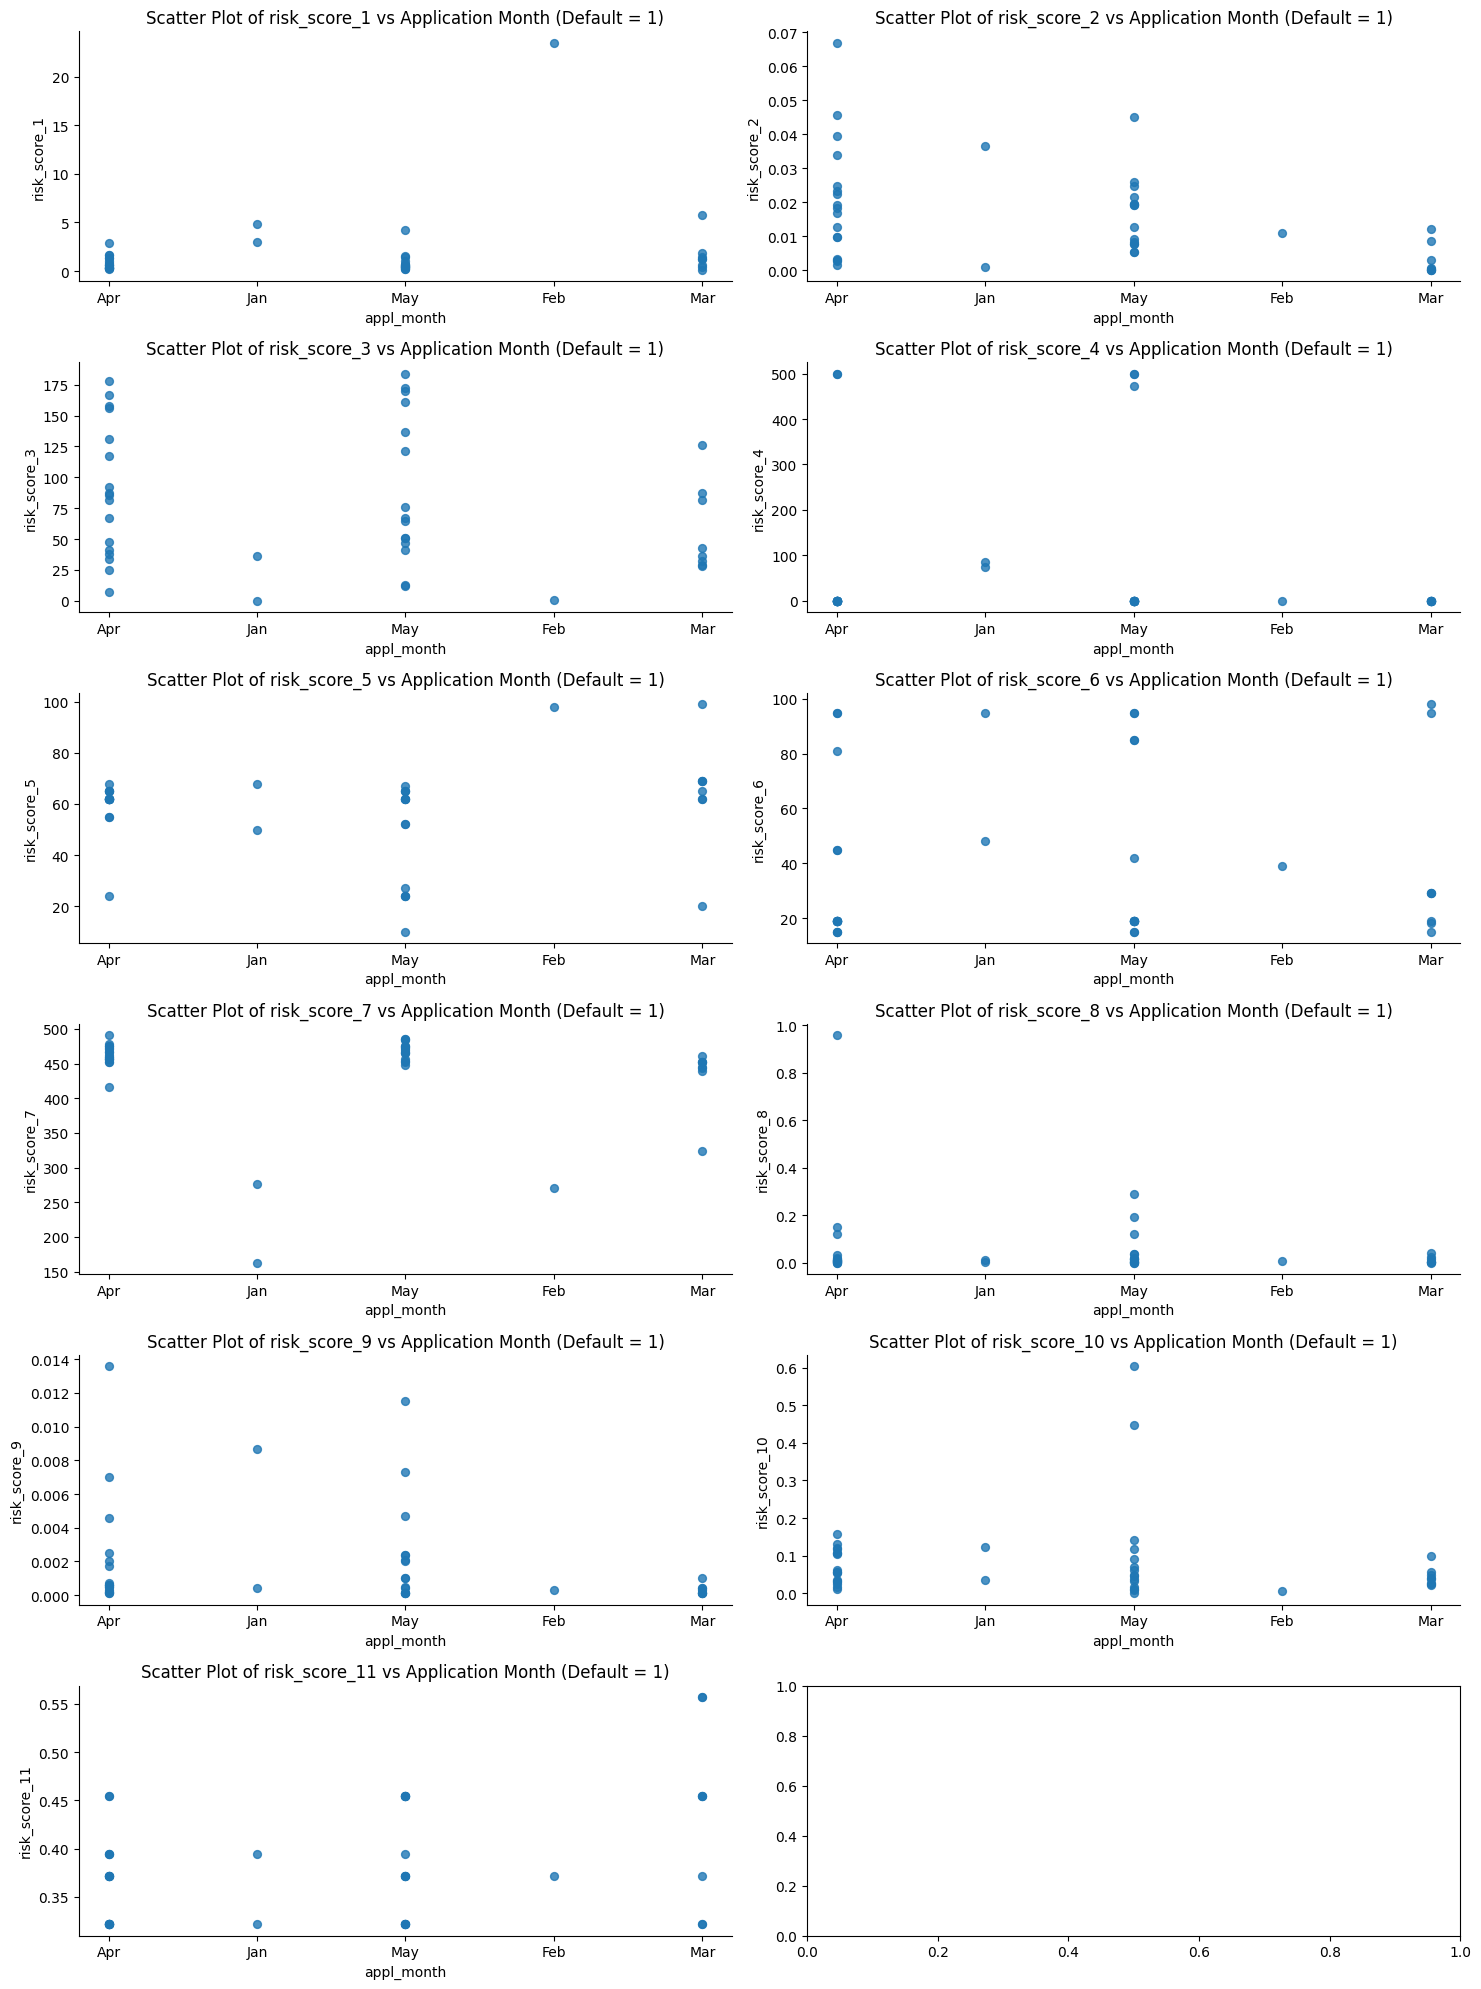

In [ ]:
# prompt: plot all risk score vs appl_month where default_ind=1 ordered by Jan, Feb, Mar, Apr, May, Jun

import matplotlib.pyplot as plt
# Filter the DataFrame for default_ind == 1
df_default = filtered_df[filtered_df['default_ind'] == 1]

# Define the order of months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over risk scores and plot
for i, risk_score in enumerate(['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                 'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                 'risk_score_9', 'risk_score_10', 'risk_score_11']):
  # Sort the data by month
  df_default_sorted = df_default.sort_values(by=['appl_month'], key=lambda x: x.map({month: i for i, month in enumerate(month_order)}))

  # Plot the scatter plot
  df_default_sorted.plot(kind='scatter', x='appl_month', y=risk_score, ax=axes[i], s=32, alpha=.8)
  axes[i].set_title(f'Scatter Plot of {risk_score} vs Application Month (Default = 1)')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


IndexError: index 10 is out of bounds for axis 0 with size 10

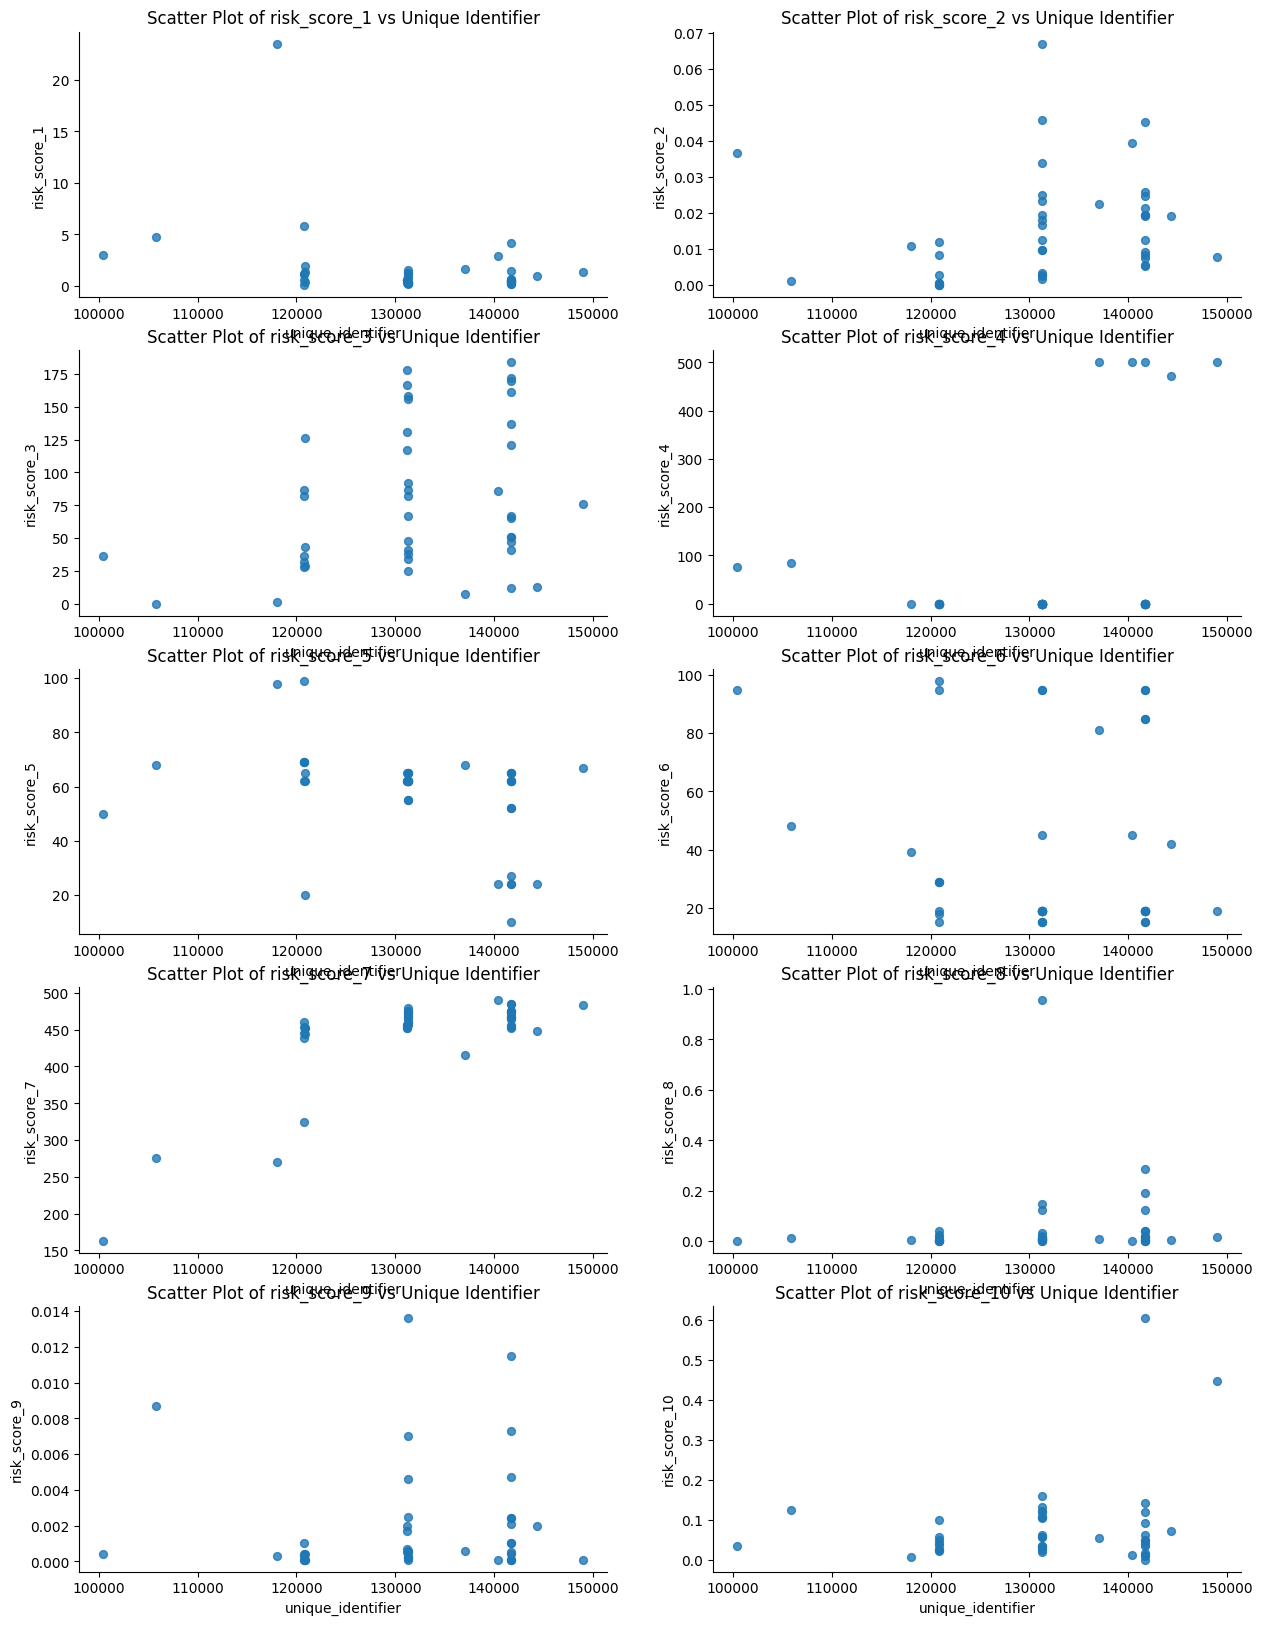

In [ ]:
# prompt: generate upon plot for all risk_scores

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame
df_default = filtered_df[filtered_df['default_ind'] == 1]
# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over risk scores and plot
for i, risk_score in enumerate(['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                 'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                 'risk_score_9', 'risk_score_10', 'risk_score_11']):
  df_default.plot(kind='scatter', x='unique_identifier', y=risk_score, ax=axes[i], s=32, alpha=.8)
  axes[i].set_title(f'Scatter Plot of {risk_score} vs Unique Identifier')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


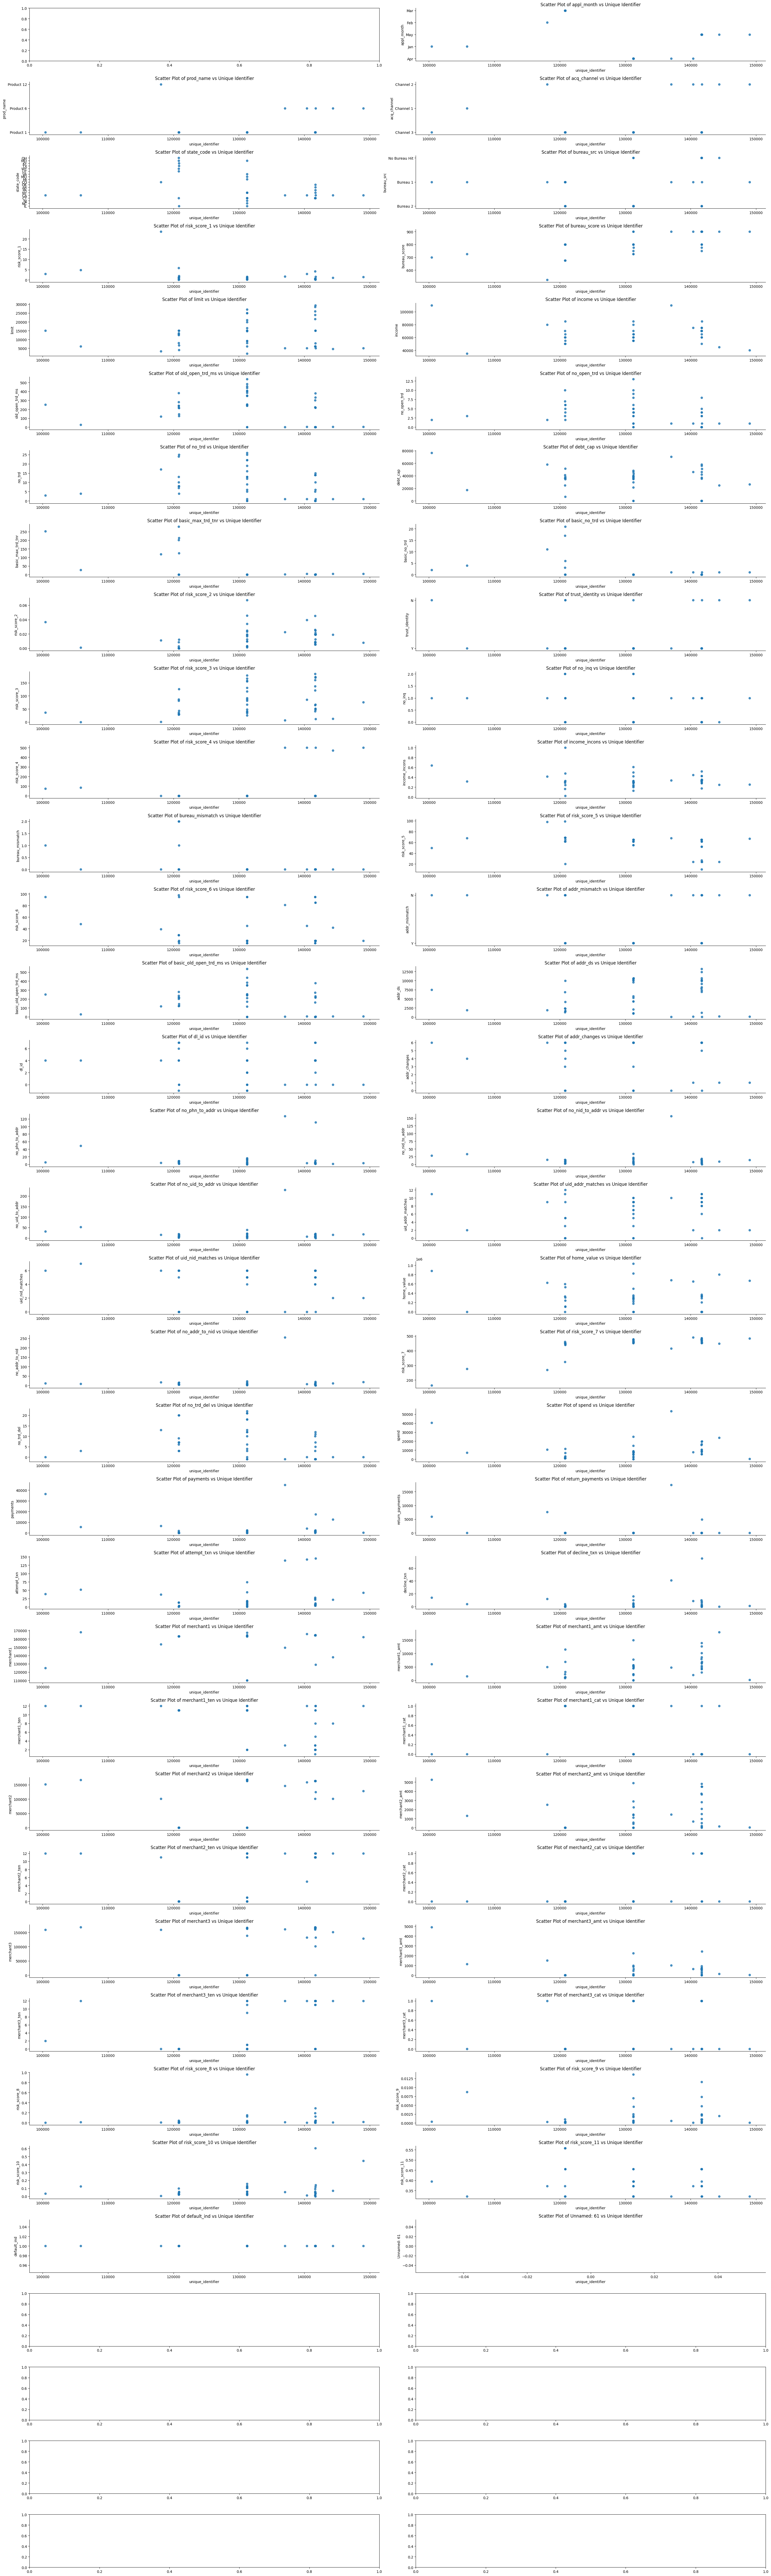

In [ ]:
# prompt: plot all column vs unique identifier for filtered_df

import matplotlib.pyplot as plt
# Assuming 'filtered_df' is your DataFrame

# Create a figure with subplots
fig, axes = plt.subplots(nrows=35, ncols=2, figsize=(30, 100))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over all columns and plot
for i, column in enumerate(filtered_df.columns):
  if column != 'unique_identifier':  # Exclude 'unique_identifier' from being plotted against itself
    filtered_df.plot(kind='scatter', x='unique_identifier', y=column, ax=axes[i], s=32, alpha=.8)
    axes[i].set_title(f'Scatter Plot of {column} vs Unique Identifier')
    axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# prompt: desc risk_score_3 for default_ind =0 and 1

# Filter the DataFrame for default_ind == 0
df_no_default = df[df['default_ind'] == 0]

# Describe risk_score_3 for default_ind == 0
risk_score_3_no_default_desc = df_no_default['risk_score_3'].describe()
print("Description of risk_score_3 for default_ind = 0:\n", risk_score_3_no_default_desc)

# Filter the DataFrame for default_ind == 1
df_default = df[df['default_ind'] == 1]

# Describe risk_score_3 for default_ind == 1
risk_score_3_default_desc = df_default['risk_score_3'].describe()
print("\nDescription of risk_score_3 for default_ind = 1:\n", risk_score_3_default_desc)


Description of risk_score_3 for default_ind = 0:
 count    62121.00000
mean         4.92447
std         32.43556
min          0.00000
25%          0.00000
50%          1.00000
75%          2.00000
max       1000.00000
Name: risk_score_3, dtype: float64

Description of risk_score_3 for default_ind = 1:
 count    363.000000
mean      39.162534
std       82.946388
min        0.000000
25%        1.000000
50%        6.000000
75%       42.000000
max      980.000000
Name: risk_score_3, dtype: float64


In [ ]:
# prompt: show rows with risk_score_3 between mean +- standard deviation of default_ind =1

# Calculate the mean and standard deviation of risk_score_3 for default_ind == 1
mean_risk_score_3 = df[df['default_ind'] == 1]['risk_score_3'].mean()
std_risk_score_3 = df[df['default_ind'] == 1]['risk_score_3'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

# Filter the DataFrame based on the bounds
filtered_rows = df[
    (df['risk_score_3'] >= lower_bound) & (df['risk_score_3'] <= upper_bound)
]

# Display the filtered rows
filtered_rows


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62479,120631,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,800,31300,150000,...,168677,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,168698,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,168742,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN
62482,154260,Jun,Product 5,Channel 2,NY,No Bureau Hit,0.0,775,5000,160000,...,168754,0.0,48,0,0.002,0.0002,0.162,0.2787,0,NaN


In [ ]:
filtered_rows[filtered_rows['default_ind'] == 1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.00,0,0,0.002,0.0015,0.035,0.2787,1,NaN
5,118746,Feb,Product 1,Channel 4,IL,Bureau 1,4.2,900,5000,50000,...,0,0.00,0,0,0.010,0.0031,0.116,0.2275,1,NaN
348,140105,Apr,Product 7,Channel 4,NV,Bureau 1,5.1,700,1000,25000,...,168049,2477.77,10,0,0.001,0.0000,0.037,0.1592,1,NaN
381,152895,Jun,Product 1,Channel 2,FL,Bureau 1,3.1,700,6000,80000,...,167945,41.00,11,0,0.999,0.0010,0.052,0.1592,1,NaN
502,116031,Feb,Product 1,Channel 1,FL,Bureau 1,2.0,750,2000,85000,...,149532,0.00,3,1,0.832,0.0100,0.022,0.1314,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61802,152081,Jun,Product 11,Channel 1,FL,Bureau 1,3.7,675,2000,300000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1592,1,NaN
61871,100026,Jan,Product 4,Channel 1,CA,Bureau 1,5.1,675,1000,120000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1517,1,NaN
61913,106684,Jan,Product 1,Channel 3,FL,Bureau 2,1.6,750,8000,200000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1971,1,NaN
61980,118552,Feb,Product 1,Channel 4,MN,Bureau 1,3.3,800,2000,160000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2035,1,NaN


In [ ]:
# prompt: desc risk_score_3 for default_ind =0 and 1

# Filter the DataFrame for default_ind == 0
df_no_default = df[df['default_ind'] == 0]

# Describe risk_score_3 for default_ind == 0
risk_score_3_no_default_desc = df_no_default['risk_score_11'].describe()
print("Description of risk_score_3 for default_ind = 0:\n", risk_score_3_no_default_desc)

# Filter the DataFrame for default_ind == 1
df_default = df[df['default_ind'] == 1]

# Describe risk_score_3 for default_ind == 1
risk_score_3_default_desc = df_default['risk_score_11'].describe()
print("\nDescription of risk_score_3 for default_ind = 1:\n", risk_score_3_default_desc)


Description of risk_score_3 for default_ind = 0:
 count    62121.000000
mean         0.202235
std          0.065891
min          0.054400
25%          0.159200
50%          0.188400
75%          0.227500
max          0.788200
Name: risk_score_11, dtype: float64

Description of risk_score_3 for default_ind = 1:
 count    363.000000
mean       0.221372
std        0.092269
min        0.086800
25%        0.158400
50%        0.188400
75%        0.262700
max        0.557300
Name: risk_score_11, dtype: float64


In [ ]:
# prompt: show rows with risk_score_3 and risk_score_11 between mean +- standard deviation of default_ind =1

# Calculate the mean and standard deviation of risk_score_3 and risk_score_11 for default_ind == 1
mean_risk_score_3 = df[df['default_ind'] == 1]['risk_score_3'].mean()
std_risk_score_3 = df[df['default_ind'] == 1]['risk_score_3'].std()
mean_risk_score_11 = df[df['default_ind'] == 1]['risk_score_11'].mean()
std_risk_score_11 = df[df['default_ind'] == 1]['risk_score_11'].std()

# Define the lower and upper bounds for risk_score_3
lower_bound_3 = mean_risk_score_3 - 0.5*std_risk_score_3
upper_bound_3 = mean_risk_score_3 + 0.5*std_risk_score_3

# Define the lower and upper bounds for risk_score_11
lower_bound_11 = mean_risk_score_11 - 0.5*std_risk_score_11
upper_bound_11 = mean_risk_score_11 + 0.5*std_risk_score_11

# Filter the DataFrame based on the bounds
filtered_rows = df[
    (df['risk_score_3'] >= lower_bound_3) & (df['risk_score_3'] <= upper_bound_3) &
    (df['risk_score_11'] >= lower_bound_11) & (df['risk_score_11'] <= upper_bound_11)
]

# Display the filtered rows
filtered_rows


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN
5,118746,Feb,Product 1,Channel 4,IL,Bureau 1,4.2,900,5000,50000,...,0,0.0,0,0,0.010,0.0031,0.116,0.2275,1,NaN
6,123388,Mar,Product 6,Channel 4,FL,Bureau 1,0.1,750,37500,150000,...,0,0.0,0,0,0.002,0.0002,0.094,0.1884,0,NaN
8,156117,Jun,Product 7,Channel 2,OH,Bureau 2,8.6,900,10000,100000,...,0,0.0,0,0,0.001,0.0001,0.026,0.2627,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62473,138608,Apr,Product 9,Channel 3,NJ,Bureau 2,9.2,900,10000,80000,...,166807,0.0,0,1,0.059,0.0007,0.094,0.1884,0,NaN
62478,131977,Apr,Product 7,Channel 2,FL,No Bureau Hit,0.0,800,10000,110000,...,168670,525.0,36,0,0.001,0.0000,0.027,0.2035,0,NaN
62479,120631,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,800,31300,150000,...,168677,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,168698,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN


In [ ]:
filtered_rows[filtered_rows['default_ind'] == 1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
5,118746,Feb,Product 1,Channel 4,IL,Bureau 1,4.2,900,5000,50000,...,0,0.00,0,0,0.010,0.0031,0.116,0.2275,1,NaN
572,130049,Mar,Product 1,Channel 4,GA,Bureau 1,2.8,750,2000,75000,...,166953,966.98,12,0,0.000,0.0000,0.055,0.2035,1,NaN
1341,109785,Jan,Product 1,Channel 3,TX,Bureau 2,7.6,900,5000,45000,...,164838,975.00,0,1,0.005,0.0039,0.035,0.2035,1,NaN
1365,137021,Apr,Product 6,Channel 2,CA,Bureau 1,3.5,900,1700,90000,...,124262,6048.23,12,0,0.007,0.0003,0.078,0.1762,1,NaN
1426,139530,Apr,Product 6,Channel 3,CA,Bureau 1,1.3,900,5000,80000,...,125425,497.56,0,1,0.000,0.0000,0.049,0.1858,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60630,152085,Jun,Product 6,Channel 1,CA,Bureau 1,0.4,750,10000,40000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1762,1,NaN
61080,100023,Jan,Product 1,Channel 3,CT,Bureau 1,2.3,750,6000,60000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1762,1,NaN
61377,143673,May,Product 7,Channel 3,NC,Bureau 2,0.0,900,5000,100000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2627,1,NaN
61913,106684,Jan,Product 1,Channel 3,FL,Bureau 2,1.6,750,8000,200000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1971,1,NaN


In [ ]:
# prompt: show rows with risk_score_3 between 25% and 75% of risk_score_3 of deafult_ind =1

# Calculate the 25th and 75th percentiles of risk_score_3 for default_ind == 1
risk_score_3_25th_percentile = df[df['default_ind'] == 1]['risk_score_3'].quantile(0.25)
risk_score_3_75th_percentile = df[df['default_ind'] == 1]['risk_score_3'].quantile(0.75)

# Filter the DataFrame based on the percentiles
filtered_rows = df[
    (df['risk_score_3'] >= risk_score_3_25th_percentile) &
    (df['risk_score_3'] <= risk_score_3_75th_percentile)
]

# Display the filtered rows
filtered_rows


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0,0.00,0,0,0.000,0.0000,0.012,0.2787,0,NaN
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.00,0,0,0.999,0.0092,0.070,0.2275,0,NaN
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.00,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0,0.00,0,0,0.252,0.0253,0.131,0.1175,0,NaN
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2035,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62476,118318,Feb,Product 6,Channel 2,GA,Bureau 2,0.1,675,17500,100000,...,168543,334.78,12,0,0.082,0.0035,0.013,0.1592,0,NaN
62478,131977,Apr,Product 7,Channel 2,FL,No Bureau Hit,0.0,800,10000,110000,...,168670,525.00,36,0,0.001,0.0000,0.027,0.2035,0,NaN
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,168742,0.00,36,1,0.016,0.0000,0.000,0.2787,0,NaN
62482,154260,Jun,Product 5,Channel 2,NY,No Bureau Hit,0.0,775,5000,160000,...,168754,0.00,48,0,0.002,0.0002,0.162,0.2787,0,NaN


In [ ]:
filtered_rows[filtered_rows.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.00,0,0,0.002,0.0015,0.035,0.2787,1,NaN
5,118746,Feb,Product 1,Channel 4,IL,Bureau 1,4.2,900,5000,50000,...,0,0.00,0,0,0.010,0.0031,0.116,0.2275,1,NaN
381,152895,Jun,Product 1,Channel 2,FL,Bureau 1,3.1,700,6000,80000,...,167945,41.00,11,0,0.999,0.0010,0.052,0.1592,1,NaN
502,116031,Feb,Product 1,Channel 1,FL,Bureau 1,2.0,750,2000,85000,...,149532,0.00,3,1,0.832,0.0100,0.022,0.1314,1,NaN
621,131211,Mar,Product 11,Channel 1,LA,Bureau 1,7.5,675,1000,280000,...,159616,224.62,12,1,0.003,0.0002,0.025,0.1609,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61144,110407,Feb,Product 4,Channel 2,NY,Bureau 2,5.5,900,1000,75000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1393,1,NaN
61787,148569,May,Product 7,Channel 3,PA,Bureau 1,2.7,675,10000,80000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2787,1,NaN
61871,100026,Jan,Product 4,Channel 1,CA,Bureau 1,5.1,675,1000,120000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1517,1,NaN
61980,118552,Feb,Product 1,Channel 4,MN,Bureau 1,3.3,800,2000,160000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2035,1,NaN


In [ ]:
# prompt: desc all risk_score for filtered_rows for default_ind =0 and 1

# Filter the DataFrame for default_ind == 0
df_no_default = filtered_rows[filtered_rows['default_ind'] == 0]

# Describe all risk scores for default_ind == 0
risk_scores_no_default_desc = df_no_default[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                            'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                            'risk_score_9', 'risk_score_10', 'risk_score_11']].describe()
print("Description of risk scores for default_ind = 0:\n", risk_scores_no_default_desc)

# Filter the DataFrame for default_ind == 1
df_default = filtered_rows[filtered_rows['default_ind'] == 1]

# Describe all risk scores for default_ind == 1
risk_scores_default_desc = df_default[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                                        'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                                        'risk_score_9', 'risk_score_10', 'risk_score_11']].describe()
print("\nDescription of risk scores for default_ind = 1:\n", risk_scores_default_desc)


Description of risk scores for default_ind = 0:
        risk_score_1  risk_score_2  risk_score_3  risk_score_4  risk_score_5  \
count  35564.000000  35564.000000  35564.000000  35564.000000  35564.000000   
mean       2.019303      0.008054      3.802272    136.128388     77.399252   
std        3.480332      0.017735      5.989253    225.959302     21.557179   
min        0.000000      0.000010      1.000000      0.000000      0.000000   
25%        0.000000      0.000720      1.000000      3.000000     68.000000   
50%        0.300000      0.002290      2.000000     12.000000     78.000000   
75%        3.000000      0.007120      3.000000    123.000000     98.000000   
max       77.400000      0.907110     42.000000    995.000000     99.000000   

       risk_score_6  risk_score_7  risk_score_8  risk_score_9  risk_score_10  \
count  35564.000000  35564.000000  35564.000000  35564.000000   35564.000000   
mean      58.084974    283.999775      0.053670      0.003259       0.048632   

In [ ]:
# prompt: show rows with risk_score_7 between 25% and 75% of risk_score_7 of deafult_ind =1 for filtered_rows

# Calculate the 25th and 75th percentiles of risk_score_7 for default_ind == 1
risk_score_7_25th_percentile = filtered_rows[filtered_rows['default_ind'] == 1]['risk_score_7'].quantile(0.25)
risk_score_7_75th_percentile = filtered_rows[filtered_rows['default_ind'] == 1]['risk_score_7'].quantile(0.75)

# Filter the DataFrame based on the percentiles
filtered_rows_risk_score_7 = filtered_rows[
    (filtered_rows['risk_score_7'] >= risk_score_7_25th_percentile) &
    (filtered_rows['risk_score_7'] <= risk_score_7_75th_percentile)
]

# Display the filtered rows
filtered_rows_risk_score_7


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.00,0,0,0.999,0.0092,0.070,0.2275,0,NaN
5,118746,Feb,Product 1,Channel 4,IL,Bureau 1,4.2,900,5000,50000,...,0,0.00,0,0,0.010,0.0031,0.116,0.2275,1,NaN
6,123388,Mar,Product 6,Channel 4,FL,Bureau 1,0.1,750,37500,150000,...,0,0.00,0,0,0.002,0.0002,0.094,0.1884,0,NaN
8,156117,Jun,Product 7,Channel 2,OH,Bureau 2,8.6,900,10000,100000,...,0,0.00,0,0,0.001,0.0001,0.026,0.2627,0,NaN
12,137558,Apr,Product 6,Channel 3,MI,Bureau 2,3.1,900,5000,45000,...,0,0.00,0,0,0.031,0.0009,0.048,0.1884,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62461,108814,Jan,Product 1,Channel 1,KS,Bureau 2,10.6,900,2000,70000,...,163717,400.00,24,0,0.020,0.0039,0.032,0.1175,0,NaN
62471,116199,Feb,Product 1,Channel 3,VI,No Bureau Hit,0.0,725,15000,120000,...,165498,30.02,12,0,0.000,0.0000,0.000,0.1404,0,NaN
62475,147927,May,Product 5,Channel 1,NY,No Bureau Hit,0.0,750,5000,75000,...,168343,443.80,12,0,0.181,0.0017,0.017,0.1662,0,NaN
62476,118318,Feb,Product 6,Channel 2,GA,Bureau 2,0.1,675,17500,100000,...,168543,334.78,12,0,0.082,0.0035,0.013,0.1592,0,NaN


In [ ]:
filtered_rows_risk_score_7[filtered_rows_risk_score_7.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
5,118746,Feb,Product 1,Channel 4,IL,Bureau 1,4.2,900,5000,50000,...,0,0.00,0,0,0.010,0.0031,0.116,0.2275,1,NaN
502,116031,Feb,Product 1,Channel 1,FL,Bureau 1,2.0,750,2000,85000,...,149532,0.00,3,1,0.832,0.0100,0.022,0.1314,1,NaN
644,110403,Feb,Product 4,Channel 4,NY,Bureau 1,4.4,700,1000,75000,...,164843,21.86,1,1,0.001,0.0000,0.062,0.1517,1,NaN
1365,137021,Apr,Product 6,Channel 2,CA,Bureau 1,3.5,900,1700,90000,...,124262,6048.23,12,0,0.007,0.0003,0.078,0.1762,1,NaN
1426,139530,Apr,Product 6,Channel 3,CA,Bureau 1,1.3,900,5000,80000,...,125425,497.56,0,1,0.000,0.0000,0.049,0.1858,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60447,123397,Mar,Product 6,Channel 1,TX,No Bureau Hit,0.8,725,14400,70000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1517,1,NaN
61144,110407,Feb,Product 4,Channel 2,NY,Bureau 2,5.5,900,1000,75000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1393,1,NaN
61787,148569,May,Product 7,Channel 3,PA,Bureau 1,2.7,675,10000,80000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2787,1,NaN
61871,100026,Jan,Product 4,Channel 1,CA,Bureau 1,5.1,675,1000,120000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1517,1,NaN


In [ ]:
# prompt: desc for risk_score_3 for df

# Describe risk_score_3 for the entire DataFrame
risk_score_3_desc = df['risk_score_3'].describe()
print("Description of risk_score_3:\n", risk_score_3_desc)


Description of risk_score_3:
 count    62484.000000
mean         5.123376
std         33.054268
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max       1000.000000
Name: risk_score_3, dtype: float64


In [ ]:
# prompt: count of total rows, rows with default_ind =0 and 1 for all risk_score = mean+-standard deviation for filtered_rows one by one

# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = risk_score_stats[risk_score]['std']

  # Filter the DataFrame based on the mean and standard deviation
  filtered_risk_score = df[
      (df[risk_score] <= mean - std) | (df[risk_score] >= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1
  total_rows = len(filtered_risk_score)
  default_ind_0 = len(filtered_risk_score[filtered_risk_score['default_ind'] == 0])
  default_ind_1 = len(filtered_risk_score[filtered_risk_score['default_ind'] == 1])

  # Print the results
  print(f"Risk Score: {risk_score}")
  print(f"Total Rows: {total_rows}")
  print(f"Rows with default_ind = 0: {default_ind_0}")
  print(f"Rows with default_ind = 1: {default_ind_1}")
  print("-" * 20)


Risk Score: risk_score_1
Total Rows: 7633
Rows with default_ind = 0: 7563
Rows with default_ind = 1: 70
--------------------
Risk Score: risk_score_2
Total Rows: 5144
Rows with default_ind = 0: 4991
Rows with default_ind = 1: 153
--------------------
Risk Score: risk_score_3
Total Rows: 1395
Rows with default_ind = 0: 1293
Rows with default_ind = 1: 102
--------------------
Risk Score: risk_score_4
Total Rows: 7732
Rows with default_ind = 0: 7624
Rows with default_ind = 1: 108
--------------------
Risk Score: risk_score_5
Total Rows: 20697
Rows with default_ind = 0: 20577
Rows with default_ind = 1: 120
--------------------
Risk Score: risk_score_6
Total Rows: 31414
Rows with default_ind = 0: 31170
Rows with default_ind = 1: 244
--------------------
Risk Score: risk_score_7
Total Rows: 24831
Rows with default_ind = 0: 24601
Rows with default_ind = 1: 230
--------------------
Risk Score: risk_score_8
Total Rows: 3656
Rows with default_ind = 0: 3637
Rows with default_ind = 1: 19
---------

In [ ]:
# prompt: rows with risk_score_3 = mean+-standard deviation

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['risk_score_6'].mean()
std_risk_score_3 = df['risk_score_6'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

# Filter the DataFrame based on the bounds
filtered_rows = df[
    (df['risk_score_6'] <= lower_bound) | (df['risk_score_6'] >= upper_bound)
]

# Display the filtered rows
filtered_rows


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
6,123388,Mar,Product 6,Channel 4,FL,Bureau 1,0.1,750,37500,150000,...,0,0.00,0,0,0.002,0.0002,0.094,0.1884,0,NaN
7,149108,May,Product 6,Channel 3,NY,Bureau 2,0.7,775,10000,50000,...,0,0.00,0,0,0.033,0.0001,0.061,0.1404,0,NaN
9,157591,Jun,Product 6,Channel 2,MI,Bureau 1,0.1,800,30000,120000,...,0,0.00,0,0,0.019,0.2253,0.075,0.1503,0,NaN
15,116025,Feb,Product 7,Channel 4,CA,Bureau 1,0.4,750,13500,50000,...,0,0.00,0,0,0.099,0.0022,0.057,0.2275,0,NaN
16,120123,Feb,Product 6,Channel 1,MI,Bureau 1,0.5,700,10000,45000,...,0,0.00,0,0,0.000,0.0000,0.014,0.1720,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62468,115270,Feb,Product 1,Channel 1,OH,Bureau 2,1.2,725,2000,35000,...,164241,1.10,12,0,0.000,0.0000,0.016,0.2229,0,NaN
62472,149106,May,Product 6,Channel 2,NY,Bureau 1,0.3,675,15000,240000,...,165888,580.99,12,0,0.010,0.0014,0.019,0.1884,0,NaN
62478,131977,Apr,Product 7,Channel 2,FL,No Bureau Hit,0.0,800,10000,110000,...,168670,525.00,36,0,0.001,0.0000,0.027,0.2035,0,NaN
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,168698,700.00,48,1,0.102,0.0001,0.018,0.2229,0,NaN


In [ ]:
# prompt: count of total rows, rows with default_ind =0 and 1 for all risk_score = mean+-standard deviation for filtered_rows one by one

# Calculate the mean and standard deviation for each risk score
risk_score_stats = filtered_rows[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = risk_score_stats[risk_score]['std']

  # Filter the DataFrame based on the mean and standard deviation
  filtered_risk_score = filtered_rows[
      (filtered_rows[risk_score] <= mean - std) | (filtered_rows[risk_score] >= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1
  total_rows = len(filtered_risk_score)
  default_ind_0 = len(filtered_risk_score[filtered_risk_score['default_ind'] == 0])
  default_ind_1 = len(filtered_risk_score[filtered_risk_score['default_ind'] == 1])

  # Print the results
  print(f"Risk Score: {risk_score}")
  print(f"Total Rows: {total_rows}")
  print(f"Rows with default_ind = 0: {default_ind_0}")
  print(f"Rows with default_ind = 1: {default_ind_1}")
  print("-" * 20)


Risk Score: risk_score_1
Total Rows: 3974
Rows with default_ind = 0: 3938
Rows with default_ind = 1: 36
--------------------
Risk Score: risk_score_2
Total Rows: 2882
Rows with default_ind = 0: 2793
Rows with default_ind = 1: 89
--------------------
Risk Score: risk_score_3
Total Rows: 712
Rows with default_ind = 0: 636
Rows with default_ind = 1: 76
--------------------
Risk Score: risk_score_4
Total Rows: 4671
Rows with default_ind = 0: 4591
Rows with default_ind = 1: 80
--------------------
Risk Score: risk_score_5
Total Rows: 14347
Rows with default_ind = 0: 14257
Rows with default_ind = 1: 90
--------------------
Risk Score: risk_score_6
Total Rows: 19533
Rows with default_ind = 0: 19448
Rows with default_ind = 1: 85
--------------------
Risk Score: risk_score_7
Total Rows: 12605
Rows with default_ind = 0: 12442
Rows with default_ind = 1: 163
--------------------
Risk Score: risk_score_8
Total Rows: 1862
Rows with default_ind = 0: 1850
Rows with default_ind = 1: 12
----------------

In [ ]:
# prompt: rows with risk_score_3 = mean+-standard deviation

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = filtered_rows['risk_score_5'].mean()
std_risk_score_3 = filtered_rows['risk_score_5'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

# Filter the DataFrame based on the bounds
filtered_rows_6 = filtered_rows[
    (filtered_rows['risk_score_5'] <= lower_bound) | (filtered_rows['risk_score_5'] >= upper_bound)
]

# Display the filtered rows
filtered_rows_6


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
6,123388,Mar,Product 6,Channel 4,FL,Bureau 1,0.1,750,37500,150000,...,0,0.00,0,0,0.002,0.0002,0.094,0.1884,0,NaN
7,149108,May,Product 6,Channel 3,NY,Bureau 2,0.7,775,10000,50000,...,0,0.00,0,0,0.033,0.0001,0.061,0.1404,0,NaN
9,157591,Jun,Product 6,Channel 2,MI,Bureau 1,0.1,800,30000,120000,...,0,0.00,0,0,0.019,0.2253,0.075,0.1503,0,NaN
15,116025,Feb,Product 7,Channel 4,CA,Bureau 1,0.4,750,13500,50000,...,0,0.00,0,0,0.099,0.0022,0.057,0.2275,0,NaN
16,120123,Feb,Product 6,Channel 1,MI,Bureau 1,0.5,700,10000,45000,...,0,0.00,0,0,0.000,0.0000,0.014,0.1720,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62466,121518,Mar,Product 6,Channel 4,IN,Bureau 1,0.1,800,16000,130000,...,164201,144.20,12,0,0.006,0.0007,0.016,0.2107,0,NaN
62468,115270,Feb,Product 1,Channel 1,OH,Bureau 2,1.2,725,2000,35000,...,164241,1.10,12,0,0.000,0.0000,0.016,0.2229,0,NaN
62472,149106,May,Product 6,Channel 2,NY,Bureau 1,0.3,675,15000,240000,...,165888,580.99,12,0,0.010,0.0014,0.019,0.1884,0,NaN
62478,131977,Apr,Product 7,Channel 2,FL,No Bureau Hit,0.0,800,10000,110000,...,168670,525.00,36,0,0.001,0.0000,0.027,0.2035,0,NaN


In [ ]:
# prompt: count of total rows, rows with default_ind =0 and 1 for all the continous columns = mean+-standard deviation for filtered_rows_6 one by one

# Calculate the mean and standard deviation for each continuous column
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']
for column in continuous_columns:
  mean = filtered_rows_6[column].mean()
  std = filtered_rows_6[column].std()

  # Filter the DataFrame based on the mean and standard deviation
  filtered_column = filtered_rows_6[
      (filtered_rows_6[column] <= mean - std) | (filtered_rows_6[column] >= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1
  total_rows = len(filtered_column)
  default_ind_0 = len(filtered_column[filtered_column['default_ind'] == 0])
  default_ind_1 = len(filtered_column[filtered_column['default_ind'] == 1])

  # Print the results
  print(f"Column: {column}")
  print(f"Total Rows: {total_rows}")
  print(f"Rows with default_ind = 0: {default_ind_0}")
  print(f"Rows with default_ind = 1: {default_ind_1}")
  print("-" * 20)


Column: risk_score_1
Total Rows: 1618
Rows with default_ind = 0: 1603
Rows with default_ind = 1: 15
--------------------
Column: risk_score_2
Total Rows: 1065
Rows with default_ind = 0: 1026
Rows with default_ind = 1: 39
--------------------
Column: risk_score_3
Total Rows: 283
Rows with default_ind = 0: 262
Rows with default_ind = 1: 21
--------------------
Column: risk_score_4
Total Rows: 1737
Rows with default_ind = 0: 1704
Rows with default_ind = 1: 33
--------------------
Column: risk_score_5
Total Rows: 3054
Rows with default_ind = 0: 3006
Rows with default_ind = 1: 48
--------------------
Column: risk_score_6
Total Rows: 5067
Rows with default_ind = 0: 5004
Rows with default_ind = 1: 63
--------------------
Column: risk_score_7
Total Rows: 5544
Rows with default_ind = 0: 5482
Rows with default_ind = 1: 62
--------------------
Column: risk_score_8
Total Rows: 830
Rows with default_ind = 0: 825
Rows with default_ind = 1: 5
--------------------
Column: risk_score_9
Total Rows: 221


In [ ]:
# prompt: rows with risk_score_3 = mean+-standard deviation

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = filtered_rows_6['risk_score_7'].mean()
std_risk_score_3 = filtered_rows_6['risk_score_7'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

# Filter the DataFrame based on the bounds
filtered_rows_4 = filtered_rows_6[
    (filtered_rows_6['risk_score_7'] <= lower_bound) | (filtered_rows_6['risk_score_7'] >= upper_bound)
]

# Display the filtered rows
filtered_rows_4


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
16,120123,Feb,Product 6,Channel 1,MI,Bureau 1,0.5,700,10000,45000,...,0,0.00,0,0,0.000,0.0000,0.014,0.1720,0,NaN
37,124225,Mar,Product 1,Channel 3,TX,Bureau 2,9.8,900,1000,120000,...,0,0.00,0,0,0.001,0.0000,0.058,0.0970,0,NaN
44,117108,Feb,Product 7,Channel 2,MD,Bureau 1,0.8,700,15500,85000,...,0,0.00,0,0,0.008,0.0000,0.000,0.1884,0,NaN
70,126448,Mar,Product 7,Channel 4,VT,Bureau 1,0.8,725,20000,55000,...,0,0.00,0,0,0.000,0.0000,0.044,0.1971,0,NaN
108,147393,May,Product 4,Channel 1,TX,Bureau 1,0.6,700,2400,20000,...,110532,86.23,12,0,0.000,0.0000,0.115,0.1662,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62448,129646,Mar,Product 12,Channel 2,NJ,Bureau 1,9.1,675,2200,95000,...,157276,350.00,24,0,0.055,0.0002,0.101,0.2035,0,NaN
62449,125772,Mar,Product 5,Channel 1,MA,No Bureau Hit,0.0,750,5000,400000,...,158022,936.00,12,1,0.562,0.0037,0.030,0.1884,0,NaN
62461,108814,Jan,Product 1,Channel 1,KS,Bureau 2,10.6,900,2000,70000,...,163717,400.00,24,0,0.020,0.0039,0.032,0.1175,0,NaN
62472,149106,May,Product 6,Channel 2,NY,Bureau 1,0.3,675,15000,240000,...,165888,580.99,12,0,0.010,0.0014,0.019,0.1884,0,NaN


In [ ]:
# prompt: count of total rows, rows with default_ind =0 and 1 for all the continous columns = mean+-standard deviation for filtered_rows_6 one by one

# Calculate the mean and standard deviation for each continuous column
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']
for column in continuous_columns:
  mean = filtered_rows_4[column].mean()
  std = filtered_rows_4[column].std()

  # Filter the DataFrame based on the mean and standard deviation
  filtered_column = filtered_rows_4[
      (filtered_rows_4[column] <= mean - std) | (filtered_rows_4[column] >= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1
  total_rows = len(filtered_column)
  default_ind_0 = len(filtered_column[filtered_column['default_ind'] == 0])
  default_ind_1 = len(filtered_column[filtered_column['default_ind'] == 1])

  # Print the results
  print(f"Column: {column}")
  print(f"Total Rows: {total_rows}")
  print(f"Rows with default_ind = 0: {default_ind_0}")
  print(f"Rows with default_ind = 1: {default_ind_1}")
  print("-" * 20)


Column: risk_score_1
Total Rows: 563
Rows with default_ind = 0: 554
Rows with default_ind = 1: 9
--------------------
Column: risk_score_2
Total Rows: 402
Rows with default_ind = 0: 380
Rows with default_ind = 1: 22
--------------------
Column: risk_score_3
Total Rows: 134
Rows with default_ind = 0: 120
Rows with default_ind = 1: 14
--------------------
Column: risk_score_4
Total Rows: 1084
Rows with default_ind = 0: 1056
Rows with default_ind = 1: 28
--------------------
Column: risk_score_5
Total Rows: 1228
Rows with default_ind = 0: 1193
Rows with default_ind = 1: 35
--------------------
Column: risk_score_6
Total Rows: 2209
Rows with default_ind = 0: 2161
Rows with default_ind = 1: 48
--------------------
Column: risk_score_7
Total Rows: 1914
Rows with default_ind = 0: 1897
Rows with default_ind = 1: 17
--------------------
Column: risk_score_8
Total Rows: 320
Rows with default_ind = 0: 317
Rows with default_ind = 1: 3
--------------------
Column: risk_score_9
Total Rows: 85
Rows w

In [ ]:
# prompt: rows with risk_score_3 = mean+-standard deviation

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = filtered_rows_4['risk_score_6'].mean()
std_risk_score_3 = filtered_rows_4['risk_score_6'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

# Filter the DataFrame based on the bounds
filtered_rows_5 = filtered_rows_4[
    (filtered_rows_4['risk_score_6'] <= lower_bound) | (filtered_rows_4['risk_score_6'] >= upper_bound)
]

# Display the filtered rows
filtered_rows_5


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
37,124225,Mar,Product 1,Channel 3,TX,Bureau 2,9.8,900,1000,120000,...,0,0.00,0,0,0.001,0.0000,0.058,0.0970,0,NaN
70,126448,Mar,Product 7,Channel 4,VT,Bureau 1,0.8,725,20000,55000,...,0,0.00,0,0,0.000,0.0000,0.044,0.1971,0,NaN
108,147393,May,Product 4,Channel 1,TX,Bureau 1,0.6,700,2400,20000,...,110532,86.23,12,0,0.000,0.0000,0.115,0.1662,0,NaN
112,139185,Apr,Product 4,Channel 4,VA,Bureau 1,2.0,900,5000,55000,...,165067,48.58,12,0,0.000,0.0000,0.088,0.1404,0,NaN
115,116414,Feb,Product 9,Channel 1,WA,Bureau 1,7.8,900,5000,170000,...,168561,238.27,11,0,0.013,0.0000,0.000,0.2275,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62419,119296,Feb,Product 7,Channel 2,MD,Bureau 2,18.4,900,10000,120000,...,147964,424.39,12,0,0.000,0.0000,0.042,0.2493,0,NaN
62448,129646,Mar,Product 12,Channel 2,NJ,Bureau 1,9.1,675,2200,95000,...,157276,350.00,24,0,0.055,0.0002,0.101,0.2035,0,NaN
62461,108814,Jan,Product 1,Channel 1,KS,Bureau 2,10.6,900,2000,70000,...,163717,400.00,24,0,0.020,0.0039,0.032,0.1175,0,NaN
62472,149106,May,Product 6,Channel 2,NY,Bureau 1,0.3,675,15000,240000,...,165888,580.99,12,0,0.010,0.0014,0.019,0.1884,0,NaN


In [ ]:
# prompt: count of total rows, rows with default_ind =0 and 1 for all the continous columns = mean+-standard deviation for filtered_rows_6 one by one

# Calculate the mean and standard deviation for each continuous column
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']
for column in continuous_columns:
  mean = filtered_rows_5[column].mean()
  std = filtered_rows_5[column].std()

  # Filter the DataFrame based on the mean and standard deviation
  filtered_column = filtered_rows_5[
      (filtered_rows_5[column] <= mean - std) | (filtered_rows_5[column] >= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1
  total_rows = len(filtered_column)
  default_ind_0 = len(filtered_column[filtered_column['default_ind'] == 0])
  default_ind_1 = len(filtered_column[filtered_column['default_ind'] == 1])

  # Print the results
  print(f"Column: {column}")
  print(f"Total Rows: {total_rows}")
  print(f"Rows with default_ind = 0: {default_ind_0}")
  print(f"Rows with default_ind = 1: {default_ind_1}")
  print("-" * 20)


Column: risk_score_1
Total Rows: 264
Rows with default_ind = 0: 259
Rows with default_ind = 1: 5
--------------------
Column: risk_score_2
Total Rows: 180
Rows with default_ind = 0: 170
Rows with default_ind = 1: 10
--------------------
Column: risk_score_3
Total Rows: 66
Rows with default_ind = 0: 55
Rows with default_ind = 1: 11
--------------------
Column: risk_score_4
Total Rows: 567
Rows with default_ind = 0: 540
Rows with default_ind = 1: 27
--------------------
Column: risk_score_5
Total Rows: 803
Rows with default_ind = 0: 795
Rows with default_ind = 1: 8
--------------------
Column: risk_score_6
Total Rows: 1398
Rows with default_ind = 0: 1368
Rows with default_ind = 1: 30
--------------------
Column: risk_score_7
Total Rows: 547
Rows with default_ind = 0: 545
Rows with default_ind = 1: 2
--------------------
Column: risk_score_8
Total Rows: 115
Rows with default_ind = 0: 113
Rows with default_ind = 1: 2
--------------------
Column: risk_score_9
Total Rows: 36
Rows with defaul

In [ ]:
# prompt: desc risk_score_2 for filtered_df

filtered_rows['risk_score_2'].describe()


,risk_score_2
count,1395.000000
mean,0.018085
std,0.026345
min,0.000000
25%,0.003310
50%,0.008950
75%,0.021410
max,0.359680


In [ ]:
# prompt: desc risk_score_2 for default_ind = 0 and 1 for filtered_rows

# Filter the DataFrame for default_ind == 0
df_no_default = filtered_rows[filtered_rows['default_ind'] == 0]

# Describe risk_score_2 for default_ind == 0
risk_score_2_no_default_desc = df_no_default['risk_score_11'].describe()
print("Description of risk_score_2 for default_ind = 0:\n", risk_score_2_no_default_desc)

# Filter the DataFrame for default_ind == 1
df_default = filtered_rows[filtered_rows['default_ind'] == 1]

# Describe risk_score_2 for default_ind == 1
risk_score_2_default_desc = df_default['risk_score_11'].describe()
print("\nDescription of risk_score_2 for default_ind = 1:\n", risk_score_2_default_desc)


Description of risk_score_2 for default_ind = 0:
 count    1293.000000
mean        0.202559
std         0.061417
min         0.089800
25%         0.160900
50%         0.188400
75%         0.227500
max         0.557300
Name: risk_score_11, dtype: float64

Description of risk_score_2 for default_ind = 1:
 count    102.000000
mean       0.297819
std        0.110925
min        0.092900
25%        0.197100
50%        0.321800
75%        0.371600
max        0.557300
Name: risk_score_11, dtype: float64


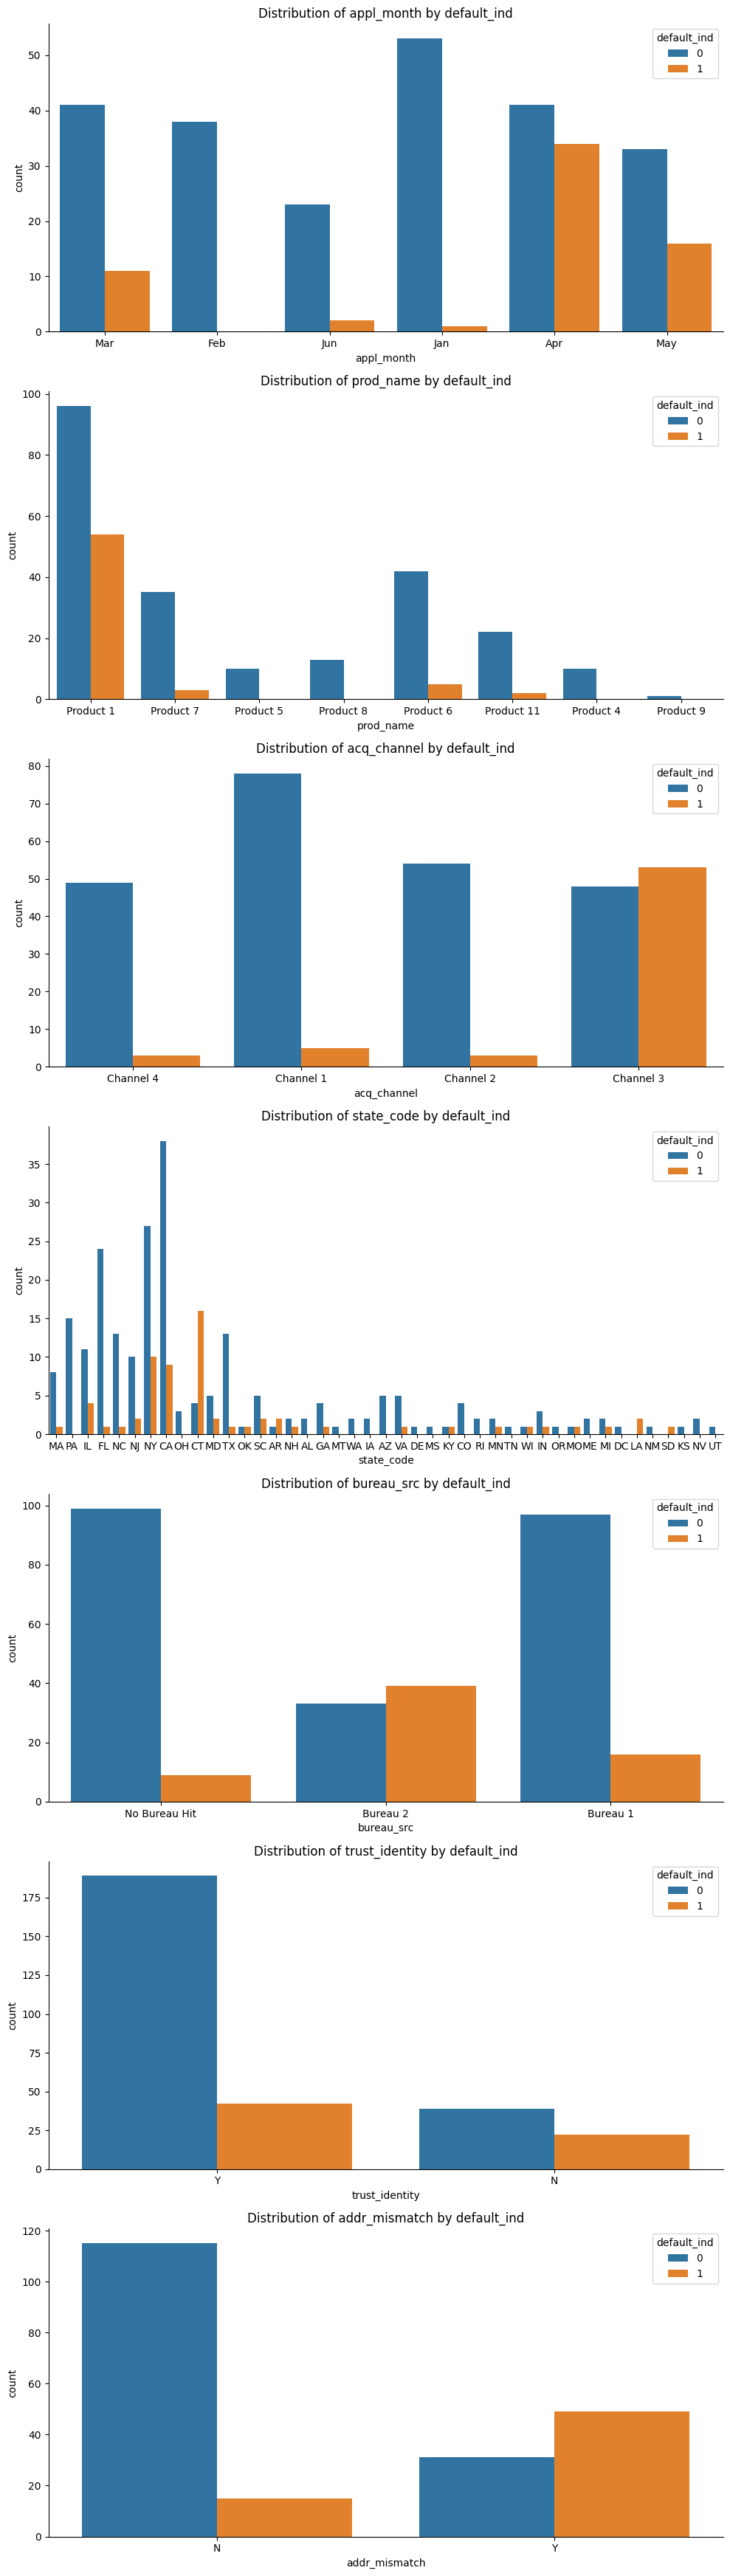

In [ ]:
# prompt: plot all discreet value column separation for filtered_rows_4 segregating default_ind = 0 and 1

import matplotlib.pyplot as plt
# Select only the discrete columns
discrete_columns = filtered_rows_4.select_dtypes(include=['object']).columns

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(discrete_columns), ncols=1, figsize=(10, 5 * len(discrete_columns)))

# Iterate over discrete columns and plot
for i, column in enumerate(discrete_columns):
  # Plot the countplot
  sns.countplot(x=column, hue='default_ind', data=filtered_rows_4, ax=axes[i])
  axes[i].set_title(f'Distribution of {column} by default_ind')
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


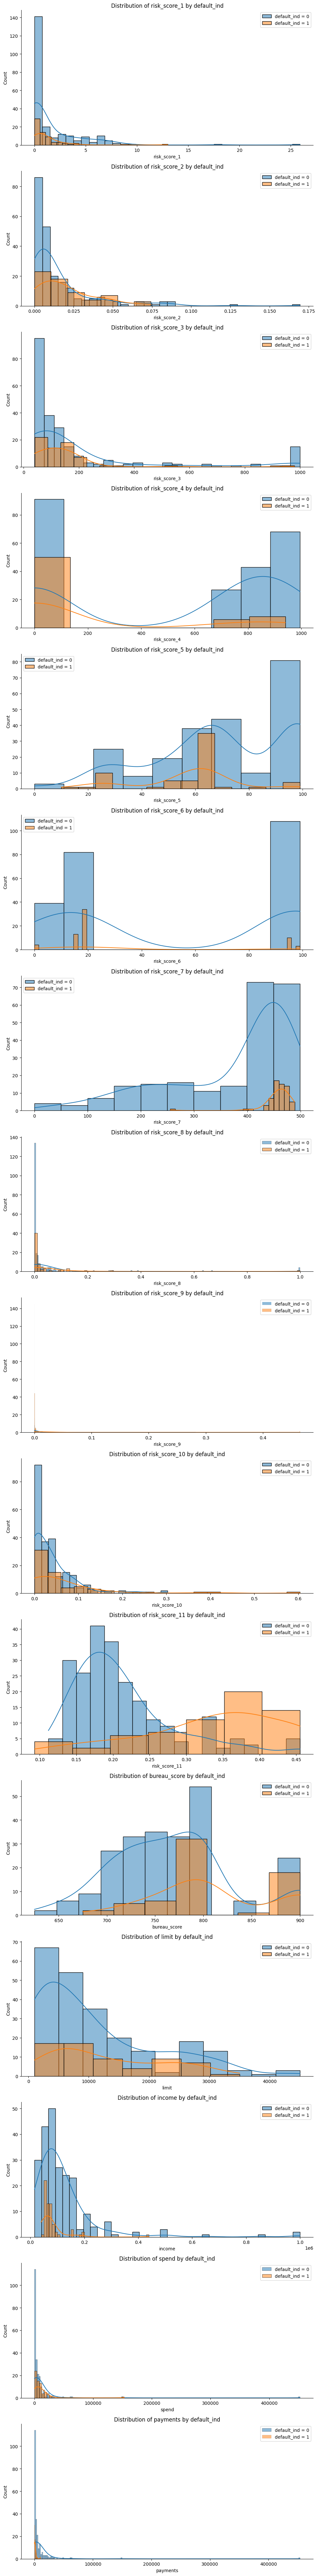

In [ ]:
# prompt: plot all continous value column separation for filtered_rows_4 segregating default_ind = 0 and 1

import matplotlib.pyplot as plt
# Select only the continuous columns
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(continuous_columns), ncols=1, figsize=(10, 5 * len(continuous_columns)))

# Iterate over continuous columns and plot
for i, column in enumerate(continuous_columns):
  # Plot the distribution for default_ind = 0
  sns.histplot(filtered_rows_4[filtered_rows_4['default_ind'] == 0][column], ax=axes[i], kde=True, label='default_ind = 0')
  # Plot the distribution for default_ind = 1
  sns.histplot(filtered_rows_4[filtered_rows_4['default_ind'] == 1][column], ax=axes[i], kde=True, label='default_ind = 1')
  axes[i].set_title(f'Distribution of {column} by default_ind')
  axes[i].legend()
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# prompt: list_down all continous columns

continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income']


In [ ]:
filtered_rows

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN
11,146948,May,Product 8,Channel 4,CA,Bureau 1,0.1,700,27500,150000,...,0,0.0,0,0,0.528,0.0122,0.166,0.3941,0,NaN
13,137275,Apr,Product 1,Channel 1,NC,Bureau 1,1.4,700,8000,100000,...,0,0.0,0,0,0.005,0.0001,0.160,0.1332,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62458,117341,Feb,Product 6,Channel 4,MI,Bureau 1,0.1,800,25000,150000,...,162061,1750.0,24,0,0.003,0.0000,0.000,0.3218,0,NaN
62461,108814,Jan,Product 1,Channel 1,KS,Bureau 2,10.6,900,2000,70000,...,163717,400.0,24,0,0.020,0.0039,0.032,0.1175,0,NaN
62477,141240,Apr,Product 8,Channel 4,CA,Bureau 1,0.1,775,35000,240000,...,168619,600.0,36,0,0.000,0.0001,0.077,0.3218,0,NaN
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,168742,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN


In [ ]:
filtered_rows_risk_score_2[filtered_rows_risk_score_2.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
1452,150593,May,Product 1,Channel 2,FL,Bureau 2,2.1,800,2000,40000,...,158060,494.00,10,1,0.056,0.0035,0.419,0.1490,1,NaN
2519,131249,Apr,Product 1,Channel 3,NY,No Bureau Hit,0.8,900,9100,55000,...,166722,991.12,12,0,0.149,0.0025,0.159,0.3218,1,NaN
2718,111995,Feb,Product 1,Channel 2,LA,Bureau 1,4.4,750,1000,75000,...,167616,1.10,12,0,0.057,0.0012,0.122,0.1971,1,NaN
5315,141669,May,Product 1,Channel 3,CT,No Bureau Hit,0.2,900,29400,70000,...,167345,927.95,12,0,0.039,0.0115,0.604,0.3218,1,NaN
6182,137684,Apr,Product 6,Channel 3,CA,Bureau 1,1.4,900,5000,85000,...,100002,0.00,12,0,0.000,0.0000,0.130,0.1576,1,NaN
27488,149026,May,Product 6,Channel 2,CA,Bureau 1,1.4,900,5000,40000,...,127964,36.35,12,0,0.015,0.0001,0.447,0.3218,1,NaN
46111,131230,Apr,Product 1,Channel 3,LA,Bureau 2,1.3,775,10500,55000,...,0,0.00,0,0,0.000,0.0000,0.374,0.3716,1,NaN
46115,120816,Mar,Product 1,Channel 3,AR,Bureau 1,0.1,800,25000,55000,...,0,0.00,0,0,0.002,0.0013,0.251,0.2787,1,NaN
46126,120818,Mar,Product 1,Channel 3,GA,Bureau 2,2.7,725,4000,50000,...,0,0.00,0,0,0.001,0.0000,0.174,0.3716,1,NaN


#3

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('amex.csv')
df

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62479,120631,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,800,31300,150000,...,168677,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,168698,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,168742,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN
62482,154260,Jun,Product 5,Channel 2,NY,No Bureau Hit,0.0,775,5000,160000,...,168754,0.0,48,0,0.002,0.0002,0.162,0.2787,0,NaN


In [ ]:
# prompt: check these rows df[(df['acq_channel'] == 'Channel 3') &
#                   (df['prod_name'] == 'Product 1') &
#                   (df['state_code'] == 'NY') &
#                  (df['risk_score_3'] > 60) &
#                   (df['spend'] > 6000)] lie in filtered_rows

# Create a boolean mask for the specified conditions
mask = (df['acq_channel'] == 'Channel 3') & \
        (df['prod_name'] == 'Product 1') & \
        (df['state_code'] == 'NY') & \
        (df['risk_score_3'] > 60) & \
        (df['spend'] > 6000)

# Get the rows that meet the conditions
#rows_to_check = df[mask]

# Filter the DataFrame based on the bounds
mask = ((df['risk_score_3'] <= df['risk_score_3'].mean()-0.5*df['risk_score_3'].std()) | (df['risk_score_3'] >= df['risk_score_3'].mean()+0.5*df['risk_score_3'].std())) & (df['risk_score_4'] == 0) & (df.default_ind==1)
rows_to_check = df[mask]
# Check if these rows exist in filtered_rows

In [ ]:
# prompt: show in tabular the total count of rows filtered, count of rows with deafult_ind =0, count of rows with deafult_ind =1, if rows contain rows_to_check, count of rows_to check  when 1) risk_score > mean+standard deviation or risk_score < mean-standard deviation 2)  risk_score > mean-standard deviation and risk_score < mean+standard deviation for all risk_scores

import pandas as pd
# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Create a list to store the results
results = []

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = risk_score_stats[risk_score]['std']

  # Filter the DataFrame based on the mean and standard deviation (condition 1)
  filtered_risk_score_1 = df[
      (df[risk_score] <= mean - std) | (df[risk_score] >= mean + std)
  ]

  # Filter the DataFrame based on the mean and standard deviation (condition 2)
  filtered_risk_score_2 = df[
      (df[risk_score] >= mean - std) & (df[risk_score] <= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1 for condition 1
  total_rows_1 = len(filtered_risk_score_1)
  default_ind_0_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 0])
  default_ind_1_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 1])

  # Count the total rows, rows with default_ind = 0 and 1 for condition 2
  total_rows_2 = len(filtered_risk_score_2)
  default_ind_0_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 0])
  default_ind_1_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 1])

  # Check if rows_to_check exist in filtered_risk_score_1
  rows_to_check_count_1 = len(pd.merge(filtered_risk_score_1, rows_to_check, how='inner'))

  # Check if rows_to_check exist in filtered_risk_score_2
  rows_to_check_count_2 = len(pd.merge(filtered_risk_score_2, rows_to_check, how='inner'))

  # Append the results to the list
  results.append([risk_score, total_rows_1, default_ind_0_1, default_ind_1_1, rows_to_check_count_1, total_rows_2, default_ind_0_2, default_ind_1_2, rows_to_check_count_2])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Risk Score', 'Total Rows (Condition 1)', 'Default_ind = 0 (Condition 1)', 'Default_ind = 1 (Condition 1)', 'Rows_to_check_count (Condition 1)', 'Total Rows (Condition 2)', 'Default_ind = 0 (Condition 2)', 'Default_ind = 1 (Condition 2)', 'Rows_to_check_count (Condition 2)'])

# Display the DataFrame
results_df


,Risk Score,Total Rows (Condition 1),Default_ind = 0 (Condition 1),Default_ind = 1 (Condition 1),Rows_to_check_count (Condition 1),Total Rows (Condition 2),Default_ind = 0 (Condition 2),Default_ind = 1 (Condition 2),Rows_to_check_count (Condition 2)
0,risk_score_1,7633,7563,70,1,54851,54558,293,63
1,risk_score_2,5144,4991,153,16,57340,57130,210,48
2,risk_score_3,1395,1293,102,56,61089,60828,261,8
3,risk_score_4,7732,7624,108,0,54752,54497,255,64
4,risk_score_5,20697,20577,120,18,41787,41544,243,46
5,risk_score_6,31414,31170,244,57,31070,30951,119,7
6,risk_score_7,24831,24601,230,63,37653,37520,133,1
7,risk_score_8,3656,3637,19,2,58828,58484,344,62
8,risk_score_9,855,844,11,0,61629,61277,352,64
9,risk_score_10,6276,6243,33,6,56208,55878,330,58


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['risk_score_3'].mean()
std_risk_score_3 = df['risk_score_3'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - 0.5*std_risk_score_3
upper_bound = mean_risk_score_3 + 0.5*std_risk_score_3

# Filter the DataFrame based on the bounds
filtered_rows = df[
    ((df['risk_score_3'] <= lower_bound) | (df['risk_score_3'] >= upper_bound))
]

# Display the filtered rows
rows_to_check_count_2 = len(pd.merge(filtered_rows, rows_to_check, how='inner'))
print(rows_to_check_count_2)

filtered_rows


64


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
122,123682,Mar,Product 1,Channel 4,MA,No Bureau Hit,7.6,650,1000,25000,...,168544,68.46,12,0,0.999,0.0013,0.073,0.2627,0,NaN
237,162231,Jun,Product 6,Channel 1,GA,Bureau 1,4.4,900,1000,50000,...,121252,293.39,12,0,0.052,0.0000,0.000,0.1609,0,NaN
270,129136,Mar,Product 8,Channel 2,NJ,No Bureau Hit,0.0,700,10000,140000,...,145138,26.85,12,1,0.000,0.0000,0.000,0.2035,0,NaN
283,148881,May,Product 5,Channel 2,TX,No Bureau Hit,0.0,725,5000,700000,...,168220,84.10,12,0,0.002,0.0000,0.000,0.2787,0,NaN
314,130470,Mar,Product 8,Channel 1,NJ,Bureau 1,0.1,800,25000,75000,...,110104,453.96,12,0,0.999,0.3122,0.327,0.1762,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62385,114813,Feb,Product 1,Channel 2,FL,Bureau 1,0.2,900,5000,40000,...,137004,672.57,12,0,0.000,0.0000,0.000,0.1662,0,NaN
62418,127829,Mar,Product 1,Channel 4,FL,No Bureau Hit,0.0,725,5000,80000,...,147925,100.00,12,0,0.000,0.0000,0.042,0.2035,0,NaN
62434,128229,Mar,Product 1,Channel 4,WI,Bureau 1,0.7,750,2000,60000,...,154532,110.91,8,1,0.001,0.0000,0.055,0.1884,0,NaN
62466,121518,Mar,Product 6,Channel 4,IN,Bureau 1,0.1,800,16000,130000,...,164201,144.20,12,0,0.006,0.0007,0.016,0.2107,0,NaN


In [ ]:
df['risk_score_3'].quantile(0.99)

81.0

In [ ]:
filtered_rows[filtered_rows.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
502,116031,Feb,Product 1,Channel 1,FL,Bureau 1,2.0,750,2000,85000,...,149532,0.00,3,1,0.832,0.0100,0.022,0.1314,1,NaN
572,130049,Mar,Product 1,Channel 4,GA,Bureau 1,2.8,750,2000,75000,...,166953,966.98,12,0,0.000,0.0000,0.055,0.2035,1,NaN
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56759,100019,Jan,Product 11,Channel 3,NY,Bureau 1,1.8,750,6200,85000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2787,1,NaN
57828,139356,Apr,Product 7,Channel 1,CA,Bureau 1,0.0,900,5000,190000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2035,1,NaN
60630,152085,Jun,Product 6,Channel 1,CA,Bureau 1,0.4,750,10000,40000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1762,1,NaN
60860,127343,Mar,Product 1,Channel 2,CT,Bureau 1,7.3,900,1000,120000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1490,1,NaN


In [ ]:
filtered_rows[filtered_rows.default_ind == 1]['risk_score_3'].describe()

,risk_score_3
count,129.000000
mean,103.286822
std,113.952786
min,22.000000
25%,40.000000
50%,67.000000
75%,140.000000
max,980.000000


In [ ]:
filtered_rows['risk_score_3'].describe()

,risk_score_3
count,2440.000000
mean,89.248770
std,142.766786
min,22.000000
25%,29.000000
50%,43.500000
75%,82.000000
max,1000.000000


In [ ]:
# prompt: show in tabular the total count of rows filtered, count of rows with deafult_ind =0, count of rows with deafult_ind =1, if rows contain rows_to_check, count of rows_to check  when 1) risk_score > mean+standard deviation or risk_score < mean-standard deviation 2)  risk_score > mean-standard deviation and risk_score < mean+standard deviation for all risk_scores

import pandas as pd
# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Create a list to store the results
results = []

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = risk_score_stats[risk_score]['std']

  df_temp = filtered_rows
  # Filter the DataFrame based on the mean and standard deviation (condition 1)
  filtered_risk_score_1 = df_temp[
      (df_temp[risk_score] <= mean - std) | (df_temp[risk_score] >= mean + std)
  ]

  # Filter the DataFrame based on the mean and standard deviation (condition 2)
  filtered_risk_score_2 = df_temp[
      (df_temp[risk_score] >= mean - std) & (df_temp[risk_score] <= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1 for condition 1
  total_rows_1 = len(filtered_risk_score_1)
  default_ind_0_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 0])
  default_ind_1_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 1])

  # Count the total rows, rows with default_ind = 0 and 1 for condition 2
  total_rows_2 = len(filtered_risk_score_2)
  default_ind_0_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 0])
  default_ind_1_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 1])

  # Check if rows_to_check exist in filtered_risk_score_1
  rows_to_check_count_1 = len(pd.merge(filtered_risk_score_1, rows_to_check, how='inner'))

  # Check if rows_to_check exist in filtered_risk_score_2
  rows_to_check_count_2 = len(pd.merge(filtered_risk_score_2, rows_to_check, how='inner'))

  # Append the results to the list
  results.append([risk_score, total_rows_1, default_ind_0_1, default_ind_1_1, rows_to_check_count_1, total_rows_2, default_ind_0_2, default_ind_1_2, rows_to_check_count_2])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Risk Score', 'Total Rows (Condition 1)', 'Default_ind = 0 (Condition 1)', 'Default_ind = 1 (Condition 1)', 'Rows_to_check_count (Condition 1)', 'Total Rows (Condition 2)', 'Default_ind = 0 (Condition 2)', 'Default_ind = 1 (Condition 2)', 'Rows_to_check_count (Condition 2)'])

# Display the DataFrame
results_df


,Risk Score,Total Rows (Condition 1),Default_ind = 0 (Condition 1),Default_ind = 1 (Condition 1),Rows_to_check_count (Condition 1),Total Rows (Condition 2),Default_ind = 0 (Condition 2),Default_ind = 1 (Condition 2),Rows_to_check_count (Condition 2)
0,risk_score_1,381,367,14,1,2059,1944,115,63
1,risk_score_2,520,463,57,16,1920,1848,72,48
2,risk_score_3,1395,1293,102,56,1045,1018,27,8
3,risk_score_4,951,912,39,0,1489,1399,90,64
4,risk_score_5,822,782,40,18,1618,1529,89,46
5,risk_score_6,1347,1243,104,57,1093,1068,25,7
6,risk_score_7,1563,1452,111,63,877,859,18,1
7,risk_score_8,141,137,4,2,2299,2174,125,62
8,risk_score_9,37,34,3,0,2403,2277,126,64
9,risk_score_10,260,248,12,6,2180,2063,117,58


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['risk_score_11'].mean()
std_risk_score_3 = df['risk_score_11'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

d = filtered_rows
# Filter the DataFrame based on the bounds
filtered_rows_1 = d[
    ((d['risk_score_11'] <= lower_bound) | (d['risk_score_11'] >= upper_bound))
]

rows_to_check_count_2 = len(pd.merge(filtered_rows_1, rows_to_check, how='inner'))
print(rows_to_check_count_2)

# Display the filtered rows
#filtered_rows_1


64


In [ ]:
d['risk_score_11'].describe()

,risk_score_11
count,2440.000000
mean,0.206461
std,0.068564
min,0.082600
25%,0.160900
50%,0.188400
75%,0.227500
max,0.557300


In [ ]:
filtered_rows_1[filtered_rows_1.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
502,116031,Feb,Product 1,Channel 1,FL,Bureau 1,2.0,750,2000,85000,...,149532,0.00,3,1,0.832,0.0100,0.022,0.1314,1,NaN
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
802,131256,Apr,Product 1,Channel 3,CT,Bureau 2,1.6,800,14700,70000,...,163070,2249.97,11,1,0.005,0.0002,0.119,0.3218,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50381,131243,Apr,Product 1,Channel 3,NY,Bureau 2,0.7,775,8000,65000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,1,NaN
50382,131248,Apr,Product 1,Channel 3,SC,Bureau 2,0.5,775,16700,55000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3218,1,NaN
50403,100018,Jan,Product 11,Channel 3,MD,Bureau 1,13.0,725,1000,75000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2878,1,NaN
53015,157857,Jun,Product 1,Channel 3,NY,Bureau 1,1.8,750,2000,80000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1270,1,NaN


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['risk_score_7'].mean()
std_risk_score_3 = df['risk_score_7'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

d = filtered_rows_1
# Filter the DataFrame based on the bounds
filtered_rows_2 = d[
    (d['risk_score_7'] <= lower_bound) | (d['risk_score_7'] >= upper_bound)
]

# Display the filtered rows
filtered_rows_2


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
283,148881,May,Product 5,Channel 2,TX,No Bureau Hit,0.0,725,5000,700000,...,168220,84.10,12,0,0.002,0.0000,0.000,0.2787,0,NaN
316,105747,Jan,Product 1,Channel 3,TX,No Bureau Hit,0.0,800,25000,110000,...,117377,4.00,12,0,0.010,0.0001,0.052,0.2878,0,NaN
418,130368,Mar,Product 1,Channel 3,AZ,Bureau 1,0.2,800,6000,75000,...,0,0.00,0,0,0.149,0.0000,0.000,0.1216,0,NaN
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59729,134151,Apr,Product 1,Channel 3,SC,Bureau 2,0.2,800,30000,75000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,0,NaN
59732,134531,Apr,Product 5,Channel 2,TX,No Bureau Hit,0.0,900,5000,45000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3218,0,NaN
59923,101787,Jan,Product 6,Channel 1,CA,Bureau 1,5.5,650,3700,360000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2787,0,NaN
61034,154701,Jun,Product 8,Channel 1,MS,Bureau 1,0.1,775,37500,300000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2787,0,NaN


In [ ]:
filtered_rows_2[filtered_rows_2.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
802,131256,Apr,Product 1,Channel 3,CT,Bureau 2,1.6,800,14700,70000,...,163070,2249.97,11,1,0.005,0.0002,0.119,0.3218,1,NaN
1342,131239,Apr,Product 1,Channel 3,NY,Bureau 2,0.8,775,14000,50000,...,164838,975.00,0,1,0.000,0.0000,0.041,0.4551,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50381,131243,Apr,Product 1,Channel 3,NY,Bureau 2,0.7,775,8000,65000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,1,NaN
50382,131248,Apr,Product 1,Channel 3,SC,Bureau 2,0.5,775,16700,55000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3218,1,NaN
50403,100018,Jan,Product 11,Channel 3,MD,Bureau 1,13.0,725,1000,75000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2878,1,NaN
53015,157857,Jun,Product 1,Channel 3,NY,Bureau 1,1.8,750,2000,80000,...,0,0.00,0,0,0.000,0.0000,0.000,0.1270,1,NaN


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3


d = filtered_rows_1
# Filter the DataFrame based on the bounds
filtered_rows_3 = d[
    (d['risk_score_4'] == 0)
]

# Display the filtered rows
filtered_rows_3


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
316,105747,Jan,Product 1,Channel 3,TX,No Bureau Hit,0.0,800,25000,110000,...,117377,4.00,12,0,0.010,0.0001,0.052,0.2878,0,NaN
510,114290,Feb,Product 7,Channel 1,PA,No Bureau Hit,0.0,650,1000,60000,...,164201,1.10,12,0,0.001,0.0000,0.009,0.2787,0,NaN
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59398,145548,May,Product 1,Channel 1,NC,No Bureau Hit,0.0,725,15000,140000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2787,0,NaN
59416,149438,May,Product 1,Channel 1,NY,No Bureau Hit,0.0,775,20000,85000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3941,0,NaN
59729,134151,Apr,Product 1,Channel 3,SC,Bureau 2,0.2,800,30000,75000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,0,NaN
61012,150964,May,Product 1,Channel 1,CA,No Bureau Hit,0.0,700,16500,500000,...,0,0.00,0,0,0.000,0.0000,0.000,0.2878,0,NaN


In [ ]:


d = filtered_rows_3
# Filter the DataFrame based on the bounds
filtered_rows_4 = d[
    ((d['addr_mismatch'] == 'Y') & (d['merchant1'].isin(d['merchant1'].value_counts()[d['merchant1'].value_counts() > 1].index))) | ((d['addr_mismatch'] == 'N') & (d['merchant1'].isin(d['merchant1'].value_counts()[d['merchant1'].value_counts() > 1].index)) & (d['merchant1'] != 0))
]

filtered_rows_4


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
802,131256,Apr,Product 1,Channel 3,CT,Bureau 2,1.6,800,14700,70000,...,163070,2249.97,11,1,0.005,0.0002,0.119,0.3218,1,NaN
1342,131239,Apr,Product 1,Channel 3,NY,Bureau 2,0.8,775,14000,50000,...,164838,975.00,0,1,0.000,0.0000,0.041,0.4551,1,NaN
2518,141662,May,Product 1,Channel 3,CT,Bureau 2,0.6,800,15000,65000,...,167345,277.40,12,0,0.000,0.0000,0.043,0.3218,1,NaN
2519,131249,Apr,Product 1,Channel 3,NY,No Bureau Hit,0.8,900,9100,55000,...,166722,991.12,12,0,0.149,0.0025,0.159,0.3218,1,NaN
2521,131247,Apr,Product 1,Channel 3,NY,Bureau 2,1.4,725,8000,55000,...,167056,153.56,4,1,0.000,0.0000,0.013,0.3716,1,NaN
2523,131240,Apr,Product 1,Channel 3,NY,Bureau 2,0.2,800,16500,55000,...,165012,450.44,12,0,0.001,0.0002,0.034,0.3941,1,NaN
2524,131236,Apr,Product 1,Channel 3,NY,Bureau 2,0.3,800,20000,60000,...,167345,711.38,12,0,0.000,0.0000,0.035,0.3716,1,NaN


In [ ]:
x = d[
    ((d['addr_mismatch'] == 'Y') ) | ((d['addr_mismatch'] == 'N') & (d['merchant1'].isin(d['merchant1'].value_counts()[d['merchant1'].value_counts() > 1].index)) & (d['merchant1'] != 0))
]
x[x.default_ind==0].merchant1.value_counts()


,count
merchant1,
167079,1
106558,1
118389,1


In [ ]:
y = d[
    ((d['addr_mismatch'] == 'N') & (d['prod_name'] == 'Product 1'))]
y[y.default_ind==0].acq_channel.value_counts()

,count
acq_channel,
Channel 3,10


In [ ]:
filtered_rows_4[filtered_rows_4.default_ind==1].shape

(59, 62)

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==1]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
802,131256,Apr,Product 1,Channel 3,CT,Bureau 2,1.6,800,14700,70000,...,163070,2249.97,11,1,0.005,0.0002,0.119,0.3218,1,NaN
1342,131239,Apr,Product 1,Channel 3,NY,Bureau 2,0.8,775,14000,50000,...,164838,975.00,0,1,0.000,0.0000,0.041,0.4551,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50378,131255,Apr,Product 1,Channel 3,CT,Bureau 2,0.3,800,30000,55000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3941,1,NaN
50379,120812,Mar,Product 1,Channel 3,TX,Bureau 2,0.3,800,13000,65000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,1,NaN
50380,120815,Mar,Product 1,Channel 3,IN,Bureau 2,0.4,800,15000,70000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3218,1,NaN
50381,131243,Apr,Product 1,Channel 3,NY,Bureau 2,0.7,775,8000,65000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,1,NaN


In [ ]:
filtered_rows_3[(filtered_rows_3.risk_score_1 !=0 ) & (filtered_rows_3.default_ind == 0)]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
942,105068,Jan,Product 11,Channel 2,NV,Bureau 2,4.9,675,1000,30000,...,156516,40.84,12,0,0.184,0.0154,0.066,0.4985,0,NaN
1718,132840,Apr,Product 1,Channel 3,NC,Bureau 2,0.6,800,18000,75000,...,0,0.00,0,0,0.000,0.0000,0.138,0.4551,0,NaN
6937,132397,Apr,Product 1,Channel 3,MA,Bureau 2,3.0,750,1000,70000,...,130171,775.12,7,0,0.034,0.0005,0.027,0.3218,0,NaN
10090,135359,Apr,Product 1,Channel 3,VA,Bureau 2,1.0,800,2000,70000,...,109979,600.00,12,1,0.005,0.0000,0.000,0.3716,0,NaN
16295,132015,Apr,Product 1,Channel 3,NC,Bureau 2,7.2,900,1000,60000,...,106398,162.50,12,0,0.000,0.0000,0.024,0.3941,0,NaN
21956,131880,Apr,Product 6,Channel 1,OR,Bureau 1,4.6,700,1000,60000,...,110123,62.16,12,0,0.122,0.0005,0.043,0.1332,0,NaN
23117,132013,Apr,Product 1,Channel 3,MD,Bureau 2,0.4,775,14600,55000,...,147975,114.10,12,1,0.001,0.0000,0.478,0.3716,0,NaN
34440,133832,Apr,Product 1,Channel 3,FL,Bureau 2,0.4,800,25000,55000,...,167513,169.00,4,1,0.019,0.0026,0.070,0.4551,0,NaN
40625,129951,Mar,Product 4,Channel 3,ME,No Bureau Hit,0.7,775,20000,320000,...,108713,175.00,6,1,0.003,0.0003,0.089,0.1175,0,NaN
40772,132551,Apr,Product 1,Channel 3,OH,Bureau 2,2.7,725,1000,55000,...,0,0.00,0,0,0.000,0.0000,0.041,0.3716,0,NaN


In [ ]:
filtered_rows_3[(filtered_rows_3.risk_score_1 != 0 ) & (filtered_rows_3.default_ind == 1)]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
641,131237,Apr,Product 1,Channel 3,IL,Bureau 2,0.3,800,9100,85000,...,137918,108.00,9,1,0.016,0.0006,0.018,0.3218,1,NaN
642,131250,Apr,Product 1,Channel 3,NC,Bureau 2,1.3,725,8000,55000,...,164843,863.83,1,1,0.010,0.0006,0.106,0.3218,1,NaN
643,131246,Apr,Product 1,Channel 3,NJ,Bureau 2,0.3,800,25000,60000,...,164843,21.86,1,1,0.009,0.0003,0.132,0.3716,1,NaN
802,131256,Apr,Product 1,Channel 3,CT,Bureau 2,1.6,800,14700,70000,...,163070,2249.97,11,1,0.005,0.0002,0.119,0.3218,1,NaN
1342,131239,Apr,Product 1,Channel 3,NY,Bureau 2,0.8,775,14000,50000,...,164838,975.00,0,1,0.000,0.0000,0.041,0.4551,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50378,131255,Apr,Product 1,Channel 3,CT,Bureau 2,0.3,800,30000,55000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3941,1,NaN
50379,120812,Mar,Product 1,Channel 3,TX,Bureau 2,0.3,800,13000,65000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,1,NaN
50380,120815,Mar,Product 1,Channel 3,IN,Bureau 2,0.4,800,15000,70000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3218,1,NaN
50381,131243,Apr,Product 1,Channel 3,NY,Bureau 2,0.7,775,8000,65000,...,0,0.00,0,0,0.000,0.0000,0.000,0.3716,1,NaN


In [ ]:
filtered_rows_3[(filtered_rows_3.risk_score_1 != 0 ) & (filtered_rows_3.default_ind == 0)]

,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61
942,105068,Jan,Product 11,Channel 2,NV,Bureau 2,4.9,675,1000,30000,...,156516,40.84,12,0,0.184,0.0154,0.066,0.4985,0,NaN
1718,132840,Apr,Product 1,Channel 3,NC,Bureau 2,0.6,800,18000,75000,...,0,0.00,0,0,0.000,0.0000,0.138,0.4551,0,NaN
6937,132397,Apr,Product 1,Channel 3,MA,Bureau 2,3.0,750,1000,70000,...,130171,775.12,7,0,0.034,0.0005,0.027,0.3218,0,NaN
10090,135359,Apr,Product 1,Channel 3,VA,Bureau 2,1.0,800,2000,70000,...,109979,600.00,12,1,0.005,0.0000,0.000,0.3716,0,NaN
16295,132015,Apr,Product 1,Channel 3,NC,Bureau 2,7.2,900,1000,60000,...,106398,162.50,12,0,0.000,0.0000,0.024,0.3941,0,NaN
21956,131880,Apr,Product 6,Channel 1,OR,Bureau 1,4.6,700,1000,60000,...,110123,62.16,12,0,0.122,0.0005,0.043,0.1332,0,NaN
23117,132013,Apr,Product 1,Channel 3,MD,Bureau 2,0.4,775,14600,55000,...,147975,114.10,12,1,0.001,0.0000,0.478,0.3716,0,NaN
34440,133832,Apr,Product 1,Channel 3,FL,Bureau 2,0.4,800,25000,55000,...,167513,169.00,4,1,0.019,0.0026,0.070,0.4551,0,NaN
40625,129951,Mar,Product 4,Channel 3,ME,No Bureau Hit,0.7,775,20000,320000,...,108713,175.00,6,1,0.003,0.0003,0.089,0.1175,0,NaN
40772,132551,Apr,Product 1,Channel 3,OH,Bureau 2,2.7,725,1000,55000,...,0,0.00,0,0,0.000,0.0000,0.041,0.3716,0,NaN


In [ ]:
# prompt: list down values for -0.0028152649436075715 * risk_score_3 + -0.6586671631978384 * risk_score_1 + 0.35133031694 for default_ind =0 and 1

# Filter the DataFrame for default_ind == 0
df_no_default = filtered_rows_3[filtered_rows_3['default_ind'] == 0]

# Calculate the values for the given expression
df_no_default['calculated_value'] = (df_no_default['risk_score_3'] + df_no_default['risk_score_1'] + df_no_default['risk_score_11'])/3

# Print the values
print("Values for default_ind = 0:")
print(df_no_default['calculated_value'].describe())


# Filter the DataFrame for default_ind == 1
df_default = filtered_rows_3[filtered_rows_3['default_ind'] == 1]

# Calculate the values for the given expression
df_default['calculated_value'] =  (df_default['risk_score_3'] + df_default['risk_score_1'] + df_default['risk_score_11'])/3


# Print the values
print("\nValues for default_ind = 1:")
print(df_default['calculated_value'].describe())


Values for default_ind = 0:
count    82.000000
mean     21.034042
std      16.347603
min       7.365933
25%       9.853675
50%      14.278800
75%      25.813650
max      97.377733
Name: calculated_value, dtype: float64

Values for default_ind = 1:
count    64.000000
mean     35.990786
std      18.303749
min       8.973933
25%      17.019717
50%      36.457200
75%      53.344783
max      66.890533
Name: calculated_value, dtype: float64


<ipython-input-29-d8e615399105>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_default['calculated_value'] = (df_no_default['risk_score_3'] + df_no_default['risk_score_1'] + df_no_default['risk_score_11'])/3
<ipython-input-29-d8e615399105>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_default['calculated_value'] =  (df_default['risk_score_3'] + df_default['risk_score_1'] + df_default['risk_score_11'])/3


In [ ]:
# prompt: Feature importance:
# risk_score_3: 0.2068
# build a formula and show distribution for default_ind =0 and 1 for final score
# risk_score_1: 0.0991
# risk_score_11: 0.2012
# merchant1_amt: 0.4929

import matplotlib.pyplot as plt
# Assuming 'filtered_rows_3' is your DataFrame

# Filter the DataFrame for default_ind == 0
df_no_default = ff[ff['default_ind'] == 0]

# Calculate the final score using the given feature importance
df_no_default['final_score'] = (
    df_no_default['risk_score_3'] * 0.2068 +
    df_no_default['risk_score_1'] * 0.0991 +
    df_no_default['risk_score_11'] * 0.2012 +
    df_no_default['merchant1_amt'] * 0.4929
)

# Print the distribution of the final score for default_ind = 0
print("Distribution of final_score for default_ind = 0:")
print(df_no_default['final_score'].describe())

# Filter the DataFrame for default_ind == 1
df_default = ff[ff['default_ind'] == 1]

# Calculate the final score using the given feature importance
df_default['final_score'] = (
    df_default['risk_score_3'] * 0.2068 +
    df_default['risk_score_1'] * 0.0991 +
    df_default['risk_score_11'] * 0.2012 +
    df_default['merchant1_amt'] * 0.4929
)

# Print the distribution of the final score for default_ind = 1
print("\nDistribution of final_score for default_ind = 1:")
print(df_default['final_score'].describe())

# You can also visualize the distribution using histograms or box plots
# Example using histograms:
plt.figure(figsize=(10, 5))
plt.hist(df_no_default['final_score'], bins=20, alpha=0.5, label='default_ind = 0')
plt.hist(df_default['final_score'], bins=20, alpha=0.5, label='default_ind = 1')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()


NameError: name 'ff' is not defined

In [ ]:
 ff = filtered_rows_3[(filtered_rows_3.risk_score_1 != 0)]
 ff.shape
 ff[ff['default_ind'] == 0].shape

In [ ]:
ff[ff.default_ind==1].merchant1.value_counts()

In [ ]:
# prompt: count values of -0.0028152649436075715 * df_default['risk_score_3'] + \
#                                   -0.6586671631978384 * df_default['risk_score_1'] + \
#                                    0.35133031694 default_ind =0 and 1 lying between -3.559028 and 0.206636  for ff

# Calculate the values for the given expression
ff['calculated_value'] = (ff['risk_score_3'] + ff['risk_score_1'] + ff['risk_score_11'])/3

# Filter the DataFrame for values between -3.559028 and 0.206636
filtered_ff = ff[(ff['calculated_value'] >= -8.97) & (ff['calculated_value'] <= 66.89)]

# Count values for default_ind = 0
count_default_ind_0 = len(filtered_ff[filtered_ff['default_ind'] == 0])

# Count values for default_ind = 1
count_default_ind_1 = len(filtered_ff[filtered_ff['default_ind'] == 1])

# Print the results
print(f"Count for default_ind = 0: {count_default_ind_0}")
print(f"Count for default_ind = 1: {count_default_ind_1}")


In [ ]:
# prompt: plot state_code for default_ind = 0 and 1 for filtered_rows_3[(filtered_rows_3.risk_score_1 != 0 )] and show value columns
import plotly.express as px
# Filter the data
data_to_plot = filtered_rows_3[(filtered_rows_3.risk_score_1 != 0)]

# Create the countplot
fig = px.histogram(data_to_plot, x='prod_name', color='default_ind', barmode='group',
                   text_auto=True,
                   labels={'state_code': 'State Code', 'default_ind': 'Default Indicator'})

# Update the layout
fig.update_layout(title='Distribution of State Code by Default Indicator',
                  xaxis_title='State Code',
                  yaxis_title='Count',
                  bargap=0.2)

# Show the plot
fig.show()


In [ ]:
# prompt: plot risk_scores v/s risk_scores for all risk_score for filtered_rows_3 for default_ind 0 and 1 make the plots large

import matplotlib.pyplot as plt
# Select only the continuous columns
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(continuous_columns), ncols=len(continuous_columns), figsize=(30, 30))

# Iterate over continuous columns and plot
for i, row_column in enumerate(continuous_columns):
  for j, col_column in enumerate(continuous_columns):
    # Plot the scatter plot for default_ind = 0
    axes[i, j].scatter(filtered_rows_3[filtered_rows_3['default_ind'] == 0][row_column],
                        filtered_rows_3[filtered_rows_3['default_ind'] == 0][col_column],
                        color='blue', label='default_ind = 0')
    # Plot the scatter plot for default_ind = 1
    axes[i, j].scatter(filtered_rows_3[filtered_rows_3['default_ind'] == 1][row_column],
                        filtered_rows_3[filtered_rows_3['default_ind'] == 1][col_column],
                        color='red', label='default_ind = 1')
    axes[i, j].set_xlabel(row_column)
    axes[i, j].set_ylabel(col_column)
    axes[i, j].legend()
    axes[i, j].spines[['top', 'right']].set_visible(False)

# plt.tight_layout()
plt.show()


In [ ]:
# prompt: list risk_score_1*risk_score_3 for default_ind =0 and 1
ff = filtered_rows_3[(filtered_rows_3.risk_score_1 !=0 )]
# List risk_score_1 * risk_score_3 for default_ind = 0
risk_score_product_default_0 = ff[ff['default_ind'] == 0]['risk_score_1'] * ff[ff['default_ind'] == 0]['risk_score_11']
print("risk_score_1 * risk_score_3 for default_ind = 0:\n", risk_score_product_default_0)

# List risk_score_1 * risk_score_3 for default_ind = 1
risk_score_product_default_1 = ff[ff['default_ind'] == 1]['risk_score_1'] * ff[ff['default_ind'] == 1]['risk_score_11']
print("\nrisk_score_1 * risk_score_3 for default_ind = 1:\n", risk_score_product_default_1)


In [ ]:
# prompt: filtered_rows_3 appl_month distribution
import seaborn as sns
import matplotlib.pyplot as plt
# Plot the distribution of 'appl_month' in filtered_rows_3
plt.figure(figsize=(10, 6))
sns.countplot(x='appl_month', hue='default_ind', data=filtered_rows_3)
plt.title('Distribution of appl_month in filtered_rows_3')
plt.xlabel('appl_month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# prompt: plot distribution for all risk_scores for default_ind =0 and 1 for filtered_rows_3

import matplotlib.pyplot as plt
# Select only the continuous columns
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap', 'return_payments','attempt_txn','decline_txn', 'merchant1', 'merchant1_amt','merchant1_ten','merchant1_cat','merchant2','merchant2_amt','merchant2_ten','merchant2_cat','merchant3','merchant3_amt','merchant3_ten','merchant3_cat']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(continuous_columns), ncols=1, figsize=(10, 5 * len(continuous_columns)))

# Iterate over continuous columns and plot
for i, column in enumerate(continuous_columns):
  # Plot the distribution for default_ind = 0
  sns.histplot(filtered_rows_3[filtered_rows_3['default_ind'] == 0][column], ax=axes[i], kde=True, label='default_ind = 0')
  # Plot the distribution for default_ind = 1
  sns.histplot(filtered_rows_3[filtered_rows_3['default_ind'] == 1][column], ax=axes[i], kde=True, label='default_ind = 1')
  axes[i].set_title(f'Distribution of {column} by default_ind')
  axes[i].legend()
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# Define thresholds for filtering using addr_ds and risk_score_7
addr_ds_threshold = df['no_inq'].median()  # Use median as a threshold
risk_score_7_threshold = df['risk_score_7'].median()  # Use median as a threshold

# Filter out rows where both conditions are met
filtered_data = filtered_rows_3[
                     (filtered_rows_3['risk_score_7'] >= 1.25*risk_score_7_threshold) & (filtered_rows_3['risk_score_7'] <= 2*risk_score_7_threshold)]

# Check the remaining rows where default_ind = 1 after applying the filter
remaining_defaulted = filtered_data[filtered_data['default_ind'] == 1]

# Show results
filtered_data.shape, remaining_defaulted.shape


In [ ]:
# Define thresholds for filtering using addr_ds and risk_score_7
addr_ds_threshold = df['no_inq'].median()  # Use median as a threshold
risk_score_7_threshold = df['income'].median()  # Use median as a threshold

# Filter out rows where both conditions are met
filtered_data_1 = filtered_data[
                     (filtered_data['no_inq'] >= addr_ds_threshold)]

# Check the remaining rows where default_ind = 1 after applying the filter
remaining_defaulted = filtered_data_1[filtered_data_1['default_ind'] == 1]

# Show results
filtered_data_1.shape, remaining_defaulted.shape


In [ ]:
# prompt: sum of risk_score_1 and addr_ds distribution plot for default_ind =0 and 1

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the sum of 'risk_score_1' and 'addr_ds'
filtered_rows_3['sum_risk_score_1_addr_ds'] = filtered_rows_3['risk_score_1'] + filtered_rows_3['addr_ds']

# Create a figure and axes
plt.figure(figsize=(10, 6))

# Plot the distribution of the sum for default_ind = 0
sns.histplot(filtered_rows_3[filtered_rows_3['default_ind'] == 0]['sum_risk_score_1_addr_ds'], kde=True, label='default_ind = 0')

# Plot the distribution of the sum for default_ind = 1
sns.histplot(filtered_rows_3[filtered_rows_3['default_ind'] == 1]['sum_risk_score_1_addr_ds'], kde=True, label='default_ind = 1')

# Set title and labels
plt.title('Distribution of Sum of risk_score_1 and addr_ds by default_ind')
plt.xlabel('Sum of risk_score_1 and addr_ds')
plt.ylabel('Count')
plt.legend()

# Display the plot
plt.show()


In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==1]['sum_risk_score_1_addr_ds'].describe()

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==0]['addr_mismatch'].value_counts()

In [ ]:
filtered_rows_3[(filtered_rows_3.addr_mismatch=='N')&(filtered_rows_3.default_ind==0)].risk_score_8.value_counts()

In [ ]:
df.spend.describe()

In [ ]:
filtered_data[filtered_data.default_ind==1].merchant1_ten.describe()

In [ ]:
l = filtered_data[(filtered_data.merchant3_ten<13)]
len(l[l.default_ind==0])

In [ ]:
filtered_data[filtered_data.default_ind==1].merchant1_amt.value_counts()

In [ ]:
# prompt: list of merchant1 which common, non-common for deafult_ind =0 and 1

# Find common merchant1 values for default_ind = 0 and 1
common_merchant1 = set(filtered_data[filtered_data['default_ind'] == 0]['merchant3'].unique()).intersection(
    set(filtered_data[filtered_data['default_ind'] == 1]['merchant3'].unique())
)

# Find non-common merchant1 values for default_ind = 0
non_common_merchant1_0 = set(filtered_data[filtered_data['default_ind'] == 0]['merchant3'].unique()) - common_merchant1

# Find non-common merchant1 values for default_ind = 1
non_common_merchant1_1 = set(filtered_data[filtered_data['default_ind'] == 1]['merchant3'].unique()) - common_merchant1

print("Common merchant1 values for default_ind = 0 and 1:", common_merchant1)
print("Non-common merchant1 values for default_ind = 0:", non_common_merchant1_0)
print("Non-common merchant1 values for default_ind = 1:", non_common_merchant1_1)


In [ ]:
# prompt: list total amount sum of each merhant1 and if they belong to default_ind =1

# Group by 'merchant1' and 'default_ind', then sum 'merchant1_amt'
merchant1_sum = filtered_data.groupby(['merchant1', 'default_ind'])['merchant1_amt'].sum().reset_index()

# Filter for default_ind = 1
merchant1_sum_default_1 = merchant1_sum[merchant1_sum['default_ind'] == 1]
# Display the results
print(merchant1_sum_default_1)


In [ ]:
# Define thresholds for filtering using addr_ds and risk_score_7
addr_ds_threshold = df['no_inq'].median()  # Use median as a threshold
risk_score_7_threshold = df['risk_score_7'].median()  # Use median as a threshold

# Filter out rows where both conditions are met
filtered_data = filtered_rows_3[
                     (filtered_rows_3['risk_score_7'] >= risk_score_7_threshold)]

# Check the remaining rows where default_ind = 1 after applying the filter
remaining_defaulted = filtered_data[filtered_data['default_ind'] == 1]

# Show results
filtered_data.shape, remaining_defaulted.shape


In [ ]:
# prompt: list all columns

print(df.columns.tolist())


In [ ]:
# prompt: count of defaulters and non defaulters for all combination of column for column <= column.median for two columns

# Select the columns you want to analyze
columns_to_analyze = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']

columns_to_analyze = df.columns.tolist()

# Create an empty dictionary to store the results
results = {}

# Iterate over all combinations of two columns
for i in range(len(columns_to_analyze)):
  for j in range(i, len(columns_to_analyze)):
    col1 = columns_to_analyze[i]
    col2 = columns_to_analyze[j]

    # Calculate the median for each column
    try:
      median_col1 = filtered_rows_3[col1].median()
      median_col2 = filtered_rows_3[col2].median()

      # Filter the DataFrame based on the median
      filtered_data = filtered_rows_3[
          (filtered_rows_3[col1] >= median_col1) & (filtered_rows_3[col2] <= median_col2)
      ]

      # Count defaulters and non-defaulters
      defaulters = len(filtered_data[filtered_data['default_ind'] == 1])
      non_defaulters = len(filtered_data[filtered_data['default_ind'] == 0])

      # Store the results in the dictionary
      results[(col1, col2)] = {'defaulters': defaulters, 'non_defaulters': non_defaulters}
    except:
      continue

# Print the results
for key, value in results.items():
  if value['defaulters'] == 64 and value['non_defaulters'] < 82:
    print(f"Columns: {key}")
    print(f"Defaulters: {value['defaulters']}")
    print(f"Non-Defaulters: {value['non_defaulters']}")
    print("-" * 20)


In [ ]:
filtered_data[filtered_data.default_ind==0]

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind ==1].merchant2_ten.describe()

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==1].income_incons.value_counts()

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==0].income_incons.describe()

In [ ]:
len(filtered_rows_3[(filtered_rows_3.default_ind==0)])

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==1].bureau_src.value_counts()

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind==0].addr_mismatch

In [ ]:
filtered_rows_3[filtered_rows_3.default_ind ==1]

In [ ]:
# prompt: bureau_score/bureau_src ratio distribution for deafult_ind = 0 and 1

import matplotlib.pyplot as plt
# Calculate the bureau_score/bureau_src ratio
# Convert 'bureau_score' and 'bureau_src' to numeric, handling potential errors
filtered_rows_3['bureau_score'] = pd.to_numeric(filtered_rows_3['bureau_score'], errors='coerce')
filtered_rows_3['bureau_src'] = pd.to_numeric(filtered_rows_3['bureau_src'], errors='coerce')

# Calculate the bureau_score/bureau_src ratio
filtered_rows_3['bureau_score_ratio'] = filtered_rows_3['bureau_score'] / filtered_rows_3['bureau_src']

# ... rest of your plotting code ...

# Plot the distribution of the ratio for default_ind = 0 and 1
plt.figure(figsize=(10, 6))
sns.histplot(filtered_rows_3[filtered_rows_3['default_ind'] == 0]['bureau_score_ratio'], kde=True, label='default_ind = 0')
sns.histplot(filtered_rows_3[filtered_rows_3['default_ind'] == 1]['bureau_score_ratio'], kde=True, label='default_ind = 1')
plt.title('Distribution of bureau_score/bureau_src ratio by default_ind')
plt.xlabel('bureau_score/bureau_src ratio')
plt.ylabel('Count')
plt.legend()
plt.show()


In [ ]:
# prompt: filtered_rows_3['payments'] / filtered_rows_3['spend'] min max value for default_ind =0 and 1

# Calculate the spend/income ratio for default_ind = 0
spend_income_ratio_0 = filtered_rows_3[filtered_rows_3['default_ind'] == 0]['no_open_trd'] + filtered_rows_3[filtered_rows_3['default_ind'] == 0]['no_trd']

# Find the min and max values for default_ind = 0
min_ratio_0 = spend_income_ratio_0.min()
max_ratio_0 = spend_income_ratio_0.max()

print(f"Min spend/income ratio for default_ind = 0: {min_ratio_0}")
print(f"Max spend/income ratio for default_ind = 0: {max_ratio_0}")

# Calculate the spend/income ratio for default_ind = 1
spend_income_ratio_1 = filtered_rows_3[filtered_rows_3['default_ind'] == 1]['no_open_trd'] + filtered_rows_3[filtered_rows_3['default_ind'] == 1]['no_trd']

# Find the min and max values for default_ind = 1
min_ratio_1 = spend_income_ratio_1.min()
max_ratio_1 = spend_income_ratio_1.max()

print(f"Min spend/income ratio for default_ind = 1: {min_ratio_1}")
print(f"Max spend/income ratio for default_ind = 1: {max_ratio_1}")


In [ ]:
# prompt: count of rows with return_payements =0 for default_ind = 0

count_return_payments_0_default_ind_0 = filtered_rows_3[
    (filtered_rows_3['return_payments'] == 0) & (filtered_rows_3['default_ind'] == 0)
].shape[0]
print(f"Count of rows with return_payments = 0 for default_ind = 0: {count_return_payments_0_default_ind_0}")


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3

d = filtered_rows_3
# Filter the DataFrame based on the bounds
filtered_rows_ext = d[
    (d['return_payments'] == 0)
]

# Display the filtered rows
filtered_rows_ext


In [ ]:
filtered_rows_ext[filtered_rows_ext.default_ind == 0]

In [ ]:
# prompt: count of common rows in filtered_rows_1 and filtered_rows_ext for default_ind = 1

# Find common rows in filtered_rows_1 and filtered_rows_ext with default_ind = 1
common_rows = filtered_rows_1[filtered_rows_1['default_ind'] == 1].merge(
    filtered_rows_ext[filtered_rows_ext['default_ind'] == 1], how='inner'
)

# Count the common rows
count_common_rows = len(common_rows)

print(f"Count of common rows in filtered_rows_1 and filtered_rows_ext for default_ind = 1: {count_common_rows}")


In [ ]:
# prompt: show in tabular the total count of rows filtered, count of rows with deafult_ind =0, count of rows with deafult_ind =1, if rows contain rows_to_check, count of rows_to check  when 1) risk_score > mean+standard deviation or risk_score < mean-standard deviation 2)  risk_score > mean-standard deviation and risk_score < mean+standard deviation for all risk_scores

import pandas as pd
# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap','home_value']].agg(['mean', 'std'])

# Create a list to store the results
results = []

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = 0.3*risk_score_stats[risk_score]['std']

  df_temp = filtered_rows_3
  # Filter the DataFrame based on the mean and standard deviation (condition 1)
  filtered_risk_score_1 = df_temp[
      (df_temp[risk_score] <= mean - std) | (df_temp[risk_score] >= mean + std)
  ]

  # Filter the DataFrame based on the mean and standard deviation (condition 2)
  filtered_risk_score_2 = df_temp[
      (df_temp[risk_score] >= mean - std) & (df_temp[risk_score] <= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1 for condition 1
  total_rows_1 = len(filtered_risk_score_1)

  default_ind_0_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 0])
  default_ind_1_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 1])

  # Count the total rows, rows with default_ind = 0 and 1 for condition 2
  total_rows_2 = len(filtered_risk_score_2)
  default_ind_0_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 0])
  default_ind_1_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 1])

  # Check if rows_to_check exist in filtered_risk_score_1
  rows_to_check_count_1 = len(pd.merge(filtered_risk_score_1, rows_to_check, how='inner'))

  # Check if rows_to_check exist in filtered_risk_score_2
  rows_to_check_count_2 = len(pd.merge(filtered_risk_score_2, rows_to_check, how='inner'))

  # Append the results to the list
  results.append([risk_score, total_rows_1, default_ind_0_1, default_ind_1_1, rows_to_check_count_1, total_rows_2, default_ind_0_2, default_ind_1_2, rows_to_check_count_2])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Risk Score', 'Total Rows (Condition 1)', 'Default_ind = 0 (Condition 1)', 'Default_ind = 1 (Condition 1)', 'Rows_to_check_count (Condition 1)', 'Total Rows (Condition 2)', 'Default_ind = 0 (Condition 2)', 'Default_ind = 1 (Condition 2)', 'Rows_to_check_count (Condition 2)'])

# Display the DataFrame
results_df


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['risk_score_11'].mean()
std_risk_score_3 = df['risk_score_11'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

d = filtered_rows_1
# Filter the DataFrame based on the bounds
filtered_rows_2 = d[
    (d['risk_score_11'] <= lower_bound) | (d['risk_score_11'] >= upper_bound)
]

# Display the filtered rows
filtered_rows_2


In [ ]:
# prompt: show in tabular the total count of rows filtered, count of rows with deafult_ind =0, count of rows with deafult_ind =1, if rows contain rows_to_check, count of rows_to check  when 1) risk_score > mean+standard deviation or risk_score < mean-standard deviation 2)  risk_score > mean-standard deviation and risk_score < mean+standard deviation for all risk_scores

import pandas as pd
# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Create a list to store the results
results = []

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = risk_score_stats[risk_score]['std']

  df_temp = filtered_rows_2
  # Filter the DataFrame based on the mean and standard deviation (condition 1)
  filtered_risk_score_1 = df_temp[
      (df_temp[risk_score] <= mean - std) | (df_temp[risk_score] >= mean + std)
  ]

  # Filter the DataFrame based on the mean and standard deviation (condition 2)
  filtered_risk_score_2 = df_temp[
      (df_temp[risk_score] >= mean - std) & (df_temp[risk_score] <= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1 for condition 1
  total_rows_1 = len(filtered_risk_score_1)
  default_ind_0_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 0])
  default_ind_1_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 1])

  # Count the total rows, rows with default_ind = 0 and 1 for condition 2
  total_rows_2 = len(filtered_risk_score_2)
  default_ind_0_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 0])
  default_ind_1_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 1])

  # Check if rows_to_check exist in filtered_risk_score_1
  rows_to_check_count_1 = len(pd.merge(filtered_risk_score_1, rows_to_check, how='inner'))

  # Check if rows_to_check exist in filtered_risk_score_2
  rows_to_check_count_2 = len(pd.merge(filtered_risk_score_2, rows_to_check, how='inner'))

  # Append the results to the list
  results.append([risk_score, total_rows_1, default_ind_0_1, default_ind_1_1, rows_to_check_count_1, total_rows_2, default_ind_0_2, default_ind_1_2, rows_to_check_count_2])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Risk Score', 'Total Rows (Condition 1)', 'Default_ind = 0 (Condition 1)', 'Default_ind = 1 (Condition 1)', 'Rows_to_check_count (Condition 1)', 'Total Rows (Condition 2)', 'Default_ind = 0 (Condition 2)', 'Default_ind = 1 (Condition 2)', 'Rows_to_check_count (Condition 2)'])

# Display the DataFrame
results_df


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['income'].mean()
std_risk_score_3 = df['income'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - std_risk_score_3
upper_bound = mean_risk_score_3 + std_risk_score_3

d = filtered_rows_2
# Filter the DataFrame based on the bounds
filtered_rows_3 = d[
    (d['income'] >= lower_bound) & (d['income'] <= upper_bound)
]

# Display the filtered rows
filtered_rows_3


In [ ]:
# prompt: show in tabular the total count of rows filtered, count of rows with deafult_ind =0, count of rows with deafult_ind =1, if rows contain rows_to_check, count of rows_to check  when 1) risk_score > mean+standard deviation or risk_score < mean-standard deviation 2)  risk_score > mean-standard deviation and risk_score < mean+standard deviation for all risk_scores

import pandas as pd
# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Create a list to store the results
results = []

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = 0.5*risk_score_stats[risk_score]['std']

  df_temp = filtered_rows_3
  # Filter the DataFrame based on the mean and standard deviation (condition 1)
  filtered_risk_score_1 = df_temp[
      (df_temp[risk_score] <= mean - std) | (df_temp[risk_score] >= mean + std)
  ]

  # Filter the DataFrame based on the mean and standard deviation (condition 2)
  filtered_risk_score_2 = df_temp[
      (df_temp[risk_score] >= mean - std) & (df_temp[risk_score] <= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1 for condition 1
  total_rows_1 = len(filtered_risk_score_1)
  default_ind_0_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 0])
  default_ind_1_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 1])

  # Count the total rows, rows with default_ind = 0 and 1 for condition 2
  total_rows_2 = len(filtered_risk_score_2)
  default_ind_0_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 0])
  default_ind_1_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 1])

  # Check if rows_to_check exist in filtered_risk_score_1
  rows_to_check_count_1 = len(pd.merge(filtered_risk_score_1, rows_to_check, how='inner'))

  # Check if rows_to_check exist in filtered_risk_score_2
  rows_to_check_count_2 = len(pd.merge(filtered_risk_score_2, rows_to_check, how='inner'))

  # Append the results to the list
  results.append([risk_score, total_rows_1, default_ind_0_1, default_ind_1_1, rows_to_check_count_1, total_rows_2, default_ind_0_2, default_ind_1_2, rows_to_check_count_2])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Risk Score', 'Total Rows (Condition 1)', 'Default_ind = 0 (Condition 1)', 'Default_ind = 1 (Condition 1)', 'Rows_to_check_count (Condition 1)', 'Total Rows (Condition 2)', 'Default_ind = 0 (Condition 2)', 'Default_ind = 1 (Condition 2)', 'Rows_to_check_count (Condition 2)'])

# Display the DataFrame
results_df


In [ ]:
# prompt: put above filters for risk_score_3 and get rows

# Calculate the mean and standard deviation of risk_score_3
mean_risk_score_3 = df['risk_score_7'].mean()
std_risk_score_3 = df['risk_score_7'].std()

# Define the lower and upper bounds
lower_bound = mean_risk_score_3 - 0.4*std_risk_score_3
upper_bound = mean_risk_score_3 + 0.4*std_risk_score_3

d = filtered_rows_3
# Filter the DataFrame based on the bounds
filtered_rows_4 = d[
    (d['risk_score_7'] <= lower_bound) | (d['risk_score_7'] >= upper_bound)
]

# Display the filtered rows
filtered_rows_4


In [ ]:
filtered_rows_4[filtered_rows_4.default_ind == 1]

In [ ]:
# prompt: plot distribution for all risk_scores for default_ind =0 and 1 for filtered_rows_3

import matplotlib.pyplot as plt
# Select only the continuous columns
continuous_columns = ['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(continuous_columns), ncols=1, figsize=(10, 5 * len(continuous_columns)))

# Iterate over continuous columns and plot
for i, column in enumerate(continuous_columns):
  # Plot the distribution for default_ind = 0
  sns.histplot(filtered_rows_4[filtered_rows_4['default_ind'] == 0][column], ax=axes[i], kde=True, label='default_ind = 0')
  # Plot the distribution for default_ind = 1
  sns.histplot(filtered_rows_4[filtered_rows_4['default_ind'] == 1][column], ax=axes[i], kde=True, label='default_ind = 1')
  axes[i].set_title(f'Distribution of {column} by default_ind')
  axes[i].legend()
  axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# prompt: show in tabular the total count of rows filtered, count of rows with deafult_ind =0, count of rows with deafult_ind =1, if rows contain rows_to_check, count of rows_to check  when 1) risk_score > mean+standard deviation or risk_score < mean-standard deviation 2)  risk_score > mean-standard deviation and risk_score < mean+standard deviation for all risk_scores

import pandas as pd
# Calculate the mean and standard deviation for each risk score
risk_score_stats = df[['risk_score_1', 'risk_score_2', 'risk_score_3', 'risk_score_4',
                      'risk_score_5', 'risk_score_6', 'risk_score_7', 'risk_score_8',
                      'risk_score_9', 'risk_score_10', 'risk_score_11', 'bureau_score', 'limit', 'income','spend','payments','debt_cap']].agg(['mean', 'std'])

# Create a list to store the results
results = []

# Iterate through each risk score
for risk_score in risk_score_stats.columns:
  mean = risk_score_stats[risk_score]['mean']
  std = 0.5*risk_score_stats[risk_score]['std']

  df_temp = filtered_rows_4
  # Filter the DataFrame based on the mean and standard deviation (condition 1)
  filtered_risk_score_1 = df_temp[
      (df_temp[risk_score] <= mean - std) | (df_temp[risk_score] >= mean + std)
  ]

  # Filter the DataFrame based on the mean and standard deviation (condition 2)
  filtered_risk_score_2 = df_temp[
      (df_temp[risk_score] >= mean - std) & (df_temp[risk_score] <= mean + std)
  ]

  # Count the total rows, rows with default_ind = 0 and 1 for condition 1
  total_rows_1 = len(filtered_risk_score_1)
  default_ind_0_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 0])
  default_ind_1_1 = len(filtered_risk_score_1[filtered_risk_score_1['default_ind'] == 1])

  # Count the total rows, rows with default_ind = 0 and 1 for condition 2
  total_rows_2 = len(filtered_risk_score_2)
  default_ind_0_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 0])
  default_ind_1_2 = len(filtered_risk_score_2[filtered_risk_score_2['default_ind'] == 1])

  # Check if rows_to_check exist in filtered_risk_score_1
  rows_to_check_count_1 = len(pd.merge(filtered_risk_score_1, rows_to_check, how='inner'))

  # Check if rows_to_check exist in filtered_risk_score_2
  rows_to_check_count_2 = len(pd.merge(filtered_risk_score_2, rows_to_check, how='inner'))

  # Append the results to the list
  results.append([risk_score, total_rows_1, default_ind_0_1, default_ind_1_1, rows_to_check_count_1, total_rows_2, default_ind_0_2, default_ind_1_2, rows_to_check_count_2])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Risk Score', 'Total Rows (Condition 1)', 'Default_ind = 0 (Condition 1)', 'Default_ind = 1 (Condition 1)', 'Rows_to_check_count (Condition 1)', 'Total Rows (Condition 2)', 'Default_ind = 0 (Condition 2)', 'Default_ind = 1 (Condition 2)', 'Rows_to_check_count (Condition 2)'])

# Display the DataFrame
results_df


In [ ]:
# prompt: count of unique  merchant 1,2 ,3, combined when added all for filtered_rows_4 for default_ind=0 and default_ind =1

# Filter the DataFrame for default_ind = 0
filtered_rows_4_default_0 = filtered_rows_3[filtered_rows_3['default_ind'] == 0]

# Filter the DataFrame for default_ind = 1
filtered_rows_4_default_1 = filtered_rows_3[filtered_rows_3['default_ind'] == 1]

# Calculate the count of unique merchant combinations for default_ind = 0
merchant_combinations_default_0 = filtered_rows_4_default_0['merchant1'].astype(str) + \
                                   filtered_rows_4_default_0['merchant2'].astype(str) + \
                                   filtered_rows_4_default_0['merchant3'].astype(str)
unique_merchant_combinations_default_0 = merchant_combinations_default_0.nunique()

# Calculate the count of unique merchant combinations for default_ind = 1
merchant_combinations_default_1 = filtered_rows_4_default_1['merchant1'].astype(str) + \
                                   filtered_rows_4_default_1['merchant2'].astype(str) + \
                                   filtered_rows_4_default_1['merchant3'].astype(str)
unique_merchant_combinations_default_1 = merchant_combinations_default_1.nunique()

print(f"Unique merchant combinations for default_ind = 0: {unique_merchant_combinations_default_0}")
print(f"Unique merchant combinations for default_ind = 1: {unique_merchant_combinations_default_1}")


In [ ]:
# prompt: how many of these merchants are common in both sets

# Find the common merchant combinations
common_merchant_combinations = set(merchant_combinations_default_0).intersection(set(merchant_combinations_default_1))

# Calculate the number of common merchant combinations
num_common_merchant_combinations = len(common_merchant_combinations)

print(f"Number of common merchant combinations: {num_common_merchant_combinations}")


In [ ]:
# prompt: count of unique  merchant 1,2 ,3 seperately for filtered_rows_4 for default_ind=0 and default_ind =1 how many of these merchants are common in all sets

# Filter the DataFrame for default_ind = 0
filtered_rows_4_default_0 = filtered_rows_3[filtered_rows_3['default_ind'] == 0]

# Filter the DataFrame for default_ind = 1
filtered_rows_4_default_1 = filtered_rows_3[filtered_rows_3['default_ind'] == 1]

# Calculate the count of unique merchant1 for default_ind = 0
unique_merchant1_default_0 = filtered_rows_4_default_0['merchant1'].nunique()

# Calculate the count of unique merchant1 for default_ind = 1
unique_merchant1_default_1 = filtered_rows_4_default_1['merchant1'].nunique()

# Calculate the count of unique merchant2 for default_ind = 0
unique_merchant2_default_0 = filtered_rows_4_default_0['merchant2'].nunique()

# Calculate the count of unique merchant2 for default_ind = 1
unique_merchant2_default_1 = filtered_rows_4_default_1['merchant2'].nunique()

# Calculate the count of unique merchant3 for default_ind = 0
unique_merchant3_default_0 = filtered_rows_4_default_0['merchant3'].nunique()

# Calculate the count of unique merchant3 for default_ind = 1
unique_merchant3_default_1 = filtered_rows_4_default_1['merchant3'].nunique()

print(f"Unique merchant1 for default_ind = 0: {unique_merchant1_default_0}")
print(f"Unique merchant1 for default_ind = 1: {unique_merchant1_default_1}")
print(f"Unique merchant2 for default_ind = 0: {unique_merchant2_default_0}")
print(f"Unique merchant2 for default_ind = 1: {unique_merchant2_default_1}")
print(f"Unique merchant3 for default_ind = 0: {unique_merchant3_default_0}")
print(f"Unique merchant3 for default_ind = 1: {unique_merchant3_default_1}")

# Find the common merchants for merchant1
common_merchant1 = set(filtered_rows_4_default_0['merchant1'].unique()).intersection(set(filtered_rows_4_default_1['merchant1'].unique()))
num_common_merchant1 = len(common_merchant1)

# Find the common merchants for merchant2
common_merchant2 = set(filtered_rows_4_default_0['merchant2'].unique()).intersection(set(filtered_rows_4_default_1['merchant2'].unique()))
num_common_merchant2 = len(common_merchant2)

# Find the common merchants for merchant3
common_merchant3 = set(filtered_rows_4_default_0['merchant3'].unique()).intersection(set(filtered_rows_4_default_1['merchant3'].unique()))
num_common_merchant3 = len(common_merchant3)

print(f"Number of common merchants for merchant1: {num_common_merchant1}")
print(f"Number of common merchants for merchant2: {num_common_merchant2}")
print(f"Number of common merchants for merchant3: {num_common_merchant3}")


In [ ]:
filtered_rows_4

In [ ]:
filtered_rows_1

In [ ]:
# prompt: build a new column strategy with strategy = 1 where rows in row_to_check else 0

# Create a new column 'strategy' and initialize it with 0
df['strategy'] = 0

# Set 'strategy' to 1 for rows in rows_to_check
df.loc[df['unique_identifier'].isin(rows_to_check['unique_identifier']), 'strategy'] = 1

df


,unique_identifier,appl_month,prod_name,acq_channel,state_code,bureau_src,risk_score_1,bureau_score,limit,income,...,merchant3_amt,merchant3_ten,merchant3_cat,risk_score_8,risk_score_9,risk_score_10,risk_score_11,default_ind,Unnamed: 61,strategy
0,116356,Feb,Product 7,Channel 4,CA,No Bureau Hit,0.0,800,5000,45000,...,0.0,0,0,0.000,0.0000,0.012,0.2787,0,NaN,0
1,110872,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,775,13000,100000,...,0.0,0,0,0.999,0.0092,0.070,0.2275,0,NaN,0
2,158686,Jun,Product 6,Channel 1,CA,Bureau 1,5.6,900,2000,100000,...,0.0,0,0,0.002,0.0015,0.035,0.2787,1,NaN,0
3,148772,May,Product 5,Channel 3,DC,No Bureau Hit,0.0,800,5000,170000,...,0.0,0,0,0.252,0.0253,0.131,0.1175,0,NaN,0
4,158473,Jun,Product 7,Channel 2,VA,Bureau 1,0.1,775,10000,40000,...,0.0,0,0,0.000,0.0000,0.000,0.2035,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62479,120631,Feb,Product 6,Channel 3,GA,Bureau 1,0.1,800,31300,150000,...,700.0,24,0,0.016,0.0002,0.074,0.1884,0,NaN,0
62480,100850,Jan,Product 6,Channel 4,MD,No Bureau Hit,0.0,750,27600,150000,...,700.0,48,1,0.102,0.0001,0.018,0.2229,0,NaN,0
62481,116077,Feb,Product 11,Channel 4,FL,Bureau 1,6.5,700,1000,70000,...,0.0,36,1,0.016,0.0000,0.000,0.2787,0,NaN,0
62482,154260,Jun,Product 5,Channel 2,NY,No Bureau Hit,0.0,775,5000,160000,...,0.0,48,0,0.002,0.0002,0.162,0.2787,0,NaN,0


In [ ]:
df.strategy.value_counts()

,count
strategy,
0,62420
1,64


In [ ]:
# prompt: train xgbboost model on random 5 columns of df covering all combination with strategy as target column, dropping column = unique_identifier, appl_month, default_ind

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import random
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your DataFrame

# Drop specified columns
df_filtered = df.drop(columns=['unique_identifier', 'appl_month', 'default_ind'])

# Get all column names
columns = df_filtered.columns.tolist()

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert all columns to numeric
for col in df_filtered.columns:
    if df_filtered[col].dtype == 'object' or df_filtered[col].dtype.name == 'category':
        df_filtered[col] = label_encoder.fit_transform(df_filtered[col])


# Iterate through all combinations of 5 columns
for i in range(1000):  # Adjust the number of iterations as needed
  # Randomly select 5 columns
  selected_columns = random.sample(columns, 5)

  # Create a new DataFrame with selected columns
  df_selected = df_filtered[selected_columns + ['strategy']]


  # Split data into features (X) and target (y)
  X = df_selected.drop(columns=['strategy'])
  y = df_selected['strategy']

  # Split data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Train XGBoost model, enabling categorical features
  model = XGBClassifier(enable_categorical=True)  # Enable categorical features
  model.fit(X_train, y_train)

  # Evaluate the model (optional)
  # ...

  # Print the selected columns for this iteration
  print(f"Iteration {i+1}: Selected columns - {selected_columns}")

Iteration 1: Selected columns - ['merchant2', 'no_phn_to_addr', 'risk_score_6', 'merchant3_ten', 'prod_name']
Iteration 2: Selected columns - ['predicted_strategy', 'risk_score_7', 'basic_no_trd', 'risk_score_3', 'risk_score_5']
Iteration 3: Selected columns - ['basic_max_trd_tnr', 'uid_addr_matches', 'prod_name', 'no_addr_to_nid', 'risk_score_5']
Iteration 4: Selected columns - ['bureau_score', 'merchant2', 'addr_ds', 'no_phn_to_addr', 'prod_name']
Iteration 5: Selected columns - ['home_value', 'prod_name', 'risk_score_8', 'merchant3_ten', 'basic_max_trd_tnr']
Iteration 6: Selected columns - ['old_open_trd_ms', 'merchant1_cat', 'return_payments', 'merchant3_ten', 'attempt_txn']


AttributeError: 'DataFrame' object has no attribute 'dtype'

In [ ]:
# prompt: print weights of the model

import pandas as pd
# Get the feature importances
feature_importances = model.feature_importances_

# Create a DataFrame to display the feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
feature_importance_df


,Feature,Importance
13,risk_score_4,0.177986
34,attempt_txn,0.157675
51,risk_score_11,0.133706
67,acq_channel_Channel 3,0.116839
38,merchant1_ten,0.104376
...,...,...
56,prod_name_Product 12,0.000000
55,prod_name_Product 11,0.000000
54,prod_name_Product 10,0.000000
53,prod_name_Product 1,0.000000


In [ ]:
13	risk_score_4	0.17798581719398499
34	attempt_txn	0.15767475962638855
51	risk_score_11	0.13370579481124878
67	acq_channel == Channel 3	0.11683889478445053
38	merchant1_ten	0.10437625646591187


In [ ]:
# prompt: using these weights 13	risk_score_4	0.17798581719398499
# 34	attempt_txn	0.15767475962638855
# 51	risk_score_11	0.13370579481124878
# 67	acq_channel == Channel 3	0.11683889478445053
# 38	merchant1_ten	0.10437625646591187 build formula to filter strategy = 1

def predict_strategy(row):
  """
  Predicts the strategy based on the given weights and features.
  """
  score = (
      0.17798581719398499 * row['risk_score_4'] +
      0.15767475962638855 * row['attempt_txn'] +
      0.13370579481124878 * row['risk_score_11'] +
      0.11683889478445053 * (row['acq_channel'] == 'Channel 3') +
      0.10437625646591187 * row['merchant1_ten']
  )
  if score > 0.5:  # Adjust threshold as needed
    return 1
  else:
    return 0

# Apply the function to the DataFrame
df['predicted_strategy'] = df.apply(predict_strategy, axis=1)
df['predicted_strategy'].value_counts()

,count
predicted_strategy,
1,59611
0,2873


In [ ]:
df[df['predicted_strategy']==0].strategy.value_counts()

,count
strategy,
0,2864
1,9


In [ ]:
df['predicted_strategy'].value_counts()

,count
predicted_strategy,
1.0,15562
0.0,1197


#submission

In [ ]:
# prompt: create a dataframe with columns = unique_identifier, strategy_hit, no_of_vars and for all rows from df where strategy_hit = 1 for rows in filtered_rows_4 remaining 0 and no_of_vars = 4 for all

import pandas as pd
# Create an empty list to store the data
data = []

# Iterate over the DataFrame
for index, row in df.iterrows():
  if index in filtered_rows_3.index:
    strategy_hit = 1
  else:
    strategy_hit = 0

  # Append the data to the list
  data.append([row['unique_identifier'], strategy_hit, 4])

# Create a new DataFrame
new_df = pd.DataFrame(data, columns=['unique_identifier', 'strategy_hit', 'no_of_vars'])

# Display the new DataFrame
new_df


In [ ]:
new_df.strategy_hit.value_counts()

In [ ]:
new_df.to_csv('r3_submission_dracarys.csv',index=False)

In [ ]:
filtered_rows_3.to_csv('filtered.csv',index=False)